In [ ]:
%%writefile gas_prediction_fixed.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import joblib
import datetime
import warnings
import os
warnings.filterwarnings("ignore")

# Try to import XGBoost, fall back to RandomForest if not available
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available, using RandomForest as default")
    XGBOOST_AVAILABLE = False

class GasUsagePredictionModel:
    def __init__(self, data_path='data.csv'):
        """Initialize the gas usage prediction model."""
        self.data_path = data_path
        self.model = None
        self.scaler = StandardScaler()
        self.features = None

    def load_data(self):
        """Load and preprocess the data."""
        # Load the CSV data
        df = pd.read_csv(self.data_path)

        # Convert timestamp to datetime
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')

        # Create time-based features
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['day_of_month'] = df['timestamp'].dt.day
        df['month'] = df['timestamp'].dt.month
        df['year'] = df['timestamp'].dt.year

        # Convert hour to cyclical features to represent time's cyclic nature
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

        # Add day of week as cyclical features
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

        # Sort by timestamp to maintain time order
        df = df.sort_values('timestamp')

        # Calculate lag features (previous hour, day, week)
        df['hourly_volume_lag1'] = df['hourly_volume'].shift(1)
        df['hourly_volume_lag24'] = df['hourly_volume'].shift(24)  # Previous day, same hour
        df['hourly_volume_lag168'] = df['hourly_volume'].shift(168)  # Previous week, same hour

        # Calculate rolling averages
        df['hourly_volume_rolling_mean_24h'] = df['hourly_volume'].rolling(window=24).mean()
        df['hourly_volume_rolling_mean_7d'] = df['hourly_volume'].rolling(window=168).mean()

        # Drop rows with NaN values from lag creation
        df = df.dropna()

        # Store a copy of the original data
        self.data = df.copy()

        return df

    def prepare_features(self, df=None):
        """Prepare features for model training."""
        if df is None:
            df = self.load_data()

        # Features selection
        self.features = [
            'density', 'pressure_diff', 'pressure', 'temperature',
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'day_of_month', 'month',
            'hourly_volume_lag1', 'hourly_volume_lag24', 'hourly_volume_lag168',
            'hourly_volume_rolling_mean_24h', 'hourly_volume_rolling_mean_7d'
        ]

        # Target variable
        target = 'hourly_volume'

        # Split features and target
        X = df[self.features]
        y = df[target]

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        return X_scaled, y, X.columns

    def train_model(self, model_type='random_forest'):
        """Train the prediction model."""
        # If XGBoost requested but not available, fall back to RandomForest
        if model_type == 'xgboost' and not XGBOOST_AVAILABLE:
            print("XGBoost not available, using Random Forest instead")
            model_type = 'random_forest'

        # Load and prepare data
        df = self.load_data()
        X_scaled, y, feature_names = self.prepare_features(df)

        # Split data into train and test sets (80-20 split)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, shuffle=False  # Keep time order
        )

        # Select model type
        if model_type == 'linear':
            self.model = LinearRegression()
            print("Using Linear Regression")
        elif model_type == 'random_forest':
            self.model = RandomForestRegressor(
                n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
            )
            print("Using Random Forest Regressor")
        elif model_type == 'gradient_boosting':
            self.model = GradientBoostingRegressor(
                n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
            )
            print("Using Gradient Boosting Regressor")
        elif model_type == 'xgboost' and XGBOOST_AVAILABLE:
            self.model = XGBRegressor(
                n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
            )
            print("Using XGBoost Regressor")
        else:
            raise ValueError(f"Unknown model type: {model_type}")

        # Train the model
        print("Training the model...")
        self.model.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = self.model.predict(X_test)

        # Evaluate the model
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"\nModel Evaluation:")
        print(f"Model Type: {model_type}")
        print(f"Root Mean Squared Error: {rmse:.4f}")
        print(f"Mean Absolute Error: {mae:.4f}")
        print(f"R² Score: {r2:.4f}")

        # Plot actual vs predicted
        plt.figure(figsize=(15, 6))
        plt.plot(df['timestamp'].iloc[-len(y_test):], y_test.values, label='Actual', linewidth=2)
        plt.plot(df['timestamp'].iloc[-len(y_test):], y_pred, label='Predicted', linewidth=2, alpha=0.8)
        plt.title('Actual vs Predicted Hourly Gas Usage')
        plt.xlabel('Date')
        plt.ylabel('Hourly Volume (min m³)')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Feature importance for tree-based models
        if model_type in ['random_forest', 'gradient_boosting'] or (model_type == 'xgboost' and XGBOOST_AVAILABLE):
            feature_importance = pd.DataFrame({
                'Feature': feature_names,
                'Importance': self.model.feature_importances_
            }).sort_values('Importance', ascending=False)

            plt.figure(figsize=(12, 8))
            top_features = feature_importance.head(10)
            plt.barh(range(len(top_features)), top_features['Importance'])
            plt.yticks(range(len(top_features)), top_features['Feature'])
            plt.title(f'Top 10 Feature Importances - {model_type}')
            plt.xlabel('Importance')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()

            print("\nTop 5 Most Important Features:")
            for i, (idx, row) in enumerate(feature_importance.head().iterrows()):
                print(f"{i+1}. {row['Feature']}: {row['Importance']:.4f}")

        return {
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'model': self.model
        }

    def evaluate_all_models(self):
        """Train and compare different model types."""
        models = ['linear', 'random_forest', 'gradient_boosting']
        if XGBOOST_AVAILABLE:
            models.append('xgboost')

        results = {}

        for model_type in models:
            print(f"\n{'='*50}")
            print(f"Evaluating {model_type} model:")
            print(f"{'='*50}")
            result = self.train_model(model_type)
            results[model_type] = {
                'rmse': result['rmse'],
                'mae': result['mae'],
                'r2': result['r2']
            }

        # Create comparison table
        results_df = pd.DataFrame(results).T
        results_df = results_df.round(4)

        print(f"\n{'='*50}")
        print("MODEL COMPARISON RESULTS:")
        print(f"{'='*50}")
        print(results_df.to_string())

        # Find the best model based on RMSE
        best_model = results_df['rmse'].idxmin()
        best_rmse = results_df.loc[best_model, 'rmse']

        print(f"\n🏆 BEST MODEL: {best_model}")
        print(f"   RMSE: {best_rmse:.4f}")
        print(f"   MAE: {results_df.loc[best_model, 'mae']:.4f}")
        print(f"   R²: {results_df.loc[best_model, 'r2']:.4f}")

        # Retrain the best model and save it
        print(f"\nRetraining the best model ({best_model}) and saving...")
        self.train_model(best_model)
        self.save_model()

        return results

    def save_model(self, model_path='models/gas_usage_model.pkl'):
        """Save the trained model and scaler to disk."""
        if self.model is None:
            raise ValueError("Model has not been trained yet")

        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        # Save model and scaler
        joblib.dump({
            'model': self.model,
            'scaler': self.scaler,
            'features': self.features
        }, model_path)

        print(f"✅ Model saved to {model_path}")

    def load_model(self, model_path='models/gas_usage_model.pkl'):
        """Load a trained model from disk."""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found: {model_path}")

        model_data = joblib.load(model_path)
        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.features = model_data['features']

        # Load the data as well for predictions
        self.load_data()

        print(f"✅ Model loaded from {model_path}")

    def predict_future(self, future_date_str):
        """Predict gas usage for a future date."""
        if self.model is None:
            raise ValueError("Model not loaded. Please load or train a model first.")

        # Ensure data is loaded
        if not hasattr(self, 'data') or self.data is None:
            print("Loading data for prediction...")
            self.load_data()

        # Parse the input date string
        try:
            future_date = pd.to_datetime(future_date_str, format='%d,%m,%Y %H:%M')
        except:
            try:
                future_date = pd.to_datetime(future_date_str, format='%d-%m-%Y %H:%M')
            except:
                raise ValueError("Invalid date format. Please use 'DD,MM,YYYY HH:MM' or 'DD-MM-YYYY HH:MM'")

        # To make a future prediction, we need recent data for lag features
        # If this is far in the future, we would need to simulate intermediate predictions
        if self.data['timestamp'].max() < future_date - pd.Timedelta(days=7):
            print("⚠️  Warning: Future date is more than 7 days from the most recent data.")
            print("   Prediction accuracy may be reduced.")

        # Create a sample record for prediction
        future_record = pd.DataFrame({
            'timestamp': [future_date],
            'hour': [future_date.hour],
            'day_of_week': [future_date.dayofweek],
            'day_of_month': [future_date.day],
            'month': [future_date.month],
            'year': [future_date.year]
        })

        # Add cyclical time features
        future_record['hour_sin'] = np.sin(2 * np.pi * future_record['hour']/24)
        future_record['hour_cos'] = np.cos(2 * np.pi * future_record['hour']/24)
        future_record['day_of_week_sin'] = np.sin(2 * np.pi * future_record['day_of_week']/7)
        future_record['day_of_week_cos'] = np.cos(2 * np.pi * future_record['day_of_week']/7)

        # Find the most recent data to use for lag features
        # For simplicity, we'll use the most similar recent day
        similar_hour_data = self.data[self.data['hour'] == future_date.hour]
        if len(similar_hour_data) > 0:
            most_recent = similar_hour_data.iloc[-1]
            # Get average values for numerical features from similar hours
            avg_values = similar_hour_data.iloc[-7:].mean()

            # Fill in the remaining features
            for feature in self.features:
                if feature not in future_record.columns:
                    if feature in self.data.columns:
                        # For lag and rolling features, use recent values as approximation
                        if 'lag' in feature or 'rolling' in feature:
                            future_record[feature] = avg_values[feature]
                        else:
                            # For other features (like pressure, temperature), use recent similar hour
                            future_record[feature] = most_recent[feature]
        else:
            raise ValueError("Not enough historical data to make a prediction for this hour.")

        # Select and scale the features for prediction
        X_future = future_record[self.features]
        X_future_scaled = self.scaler.transform(X_future)

        # Make the prediction
        prediction = self.model.predict(X_future_scaled)[0]

        result = {
            'date': future_date.strftime('%d-%m-%Y %H:%M'),
            'predicted_hourly_volume': round(prediction, 2),
            'units': 'min m³'
        }

        print(f"\n🔮 PREDICTION RESULT:")
        print(f"   Date: {result['date']}")
        print(f"   Predicted Hourly Gas Volume: {result['predicted_hourly_volume']} {result['units']}")

        return result

# Helper functions for Colab that don't use argparse
def train_model_colab(data_path='data.csv', model_type='random_forest'):
    """Train a gas usage prediction model in Colab."""
    print(f"🚀 Starting model training with {model_type}...")
    model = GasUsagePredictionModel(data_path=data_path)
    result = model.train_model(model_type=model_type)
    model.save_model()
    print("✅ Model training completed and saved!")
    return model

def evaluate_all_models_colab(data_path='data.csv'):
    """Evaluate all model types in Colab."""
    print("🔍 Starting comprehensive model evaluation...")
    model = GasUsagePredictionModel(data_path=data_path)
    results = model.evaluate_all_models()
    print("✅ Model evaluation completed!")
    return model, results

def predict_future_colab(date_str, data_path='data.csv', model_path='models/gas_usage_model.pkl'):
    """Make a prediction for a future date in Colab."""
    print(f"🎯 Making prediction for: {date_str}")
    model = GasUsagePredictionModel(data_path=data_path)

    # Try to load the model first
    try:
        model.load_model(model_path)
    except FileNotFoundError:
        print("📚 No trained model found. Training a default model first...")
        model.train_model(model_type='random_forest')  # Use RandomForest as default
        model.save_model()

    # Make the prediction
    return model.predict_future(date_str)

Overwriting gas_prediction_fixed.py


🚀 Starting model training with random_forest...
Using Random Forest Regressor
Training the model...

Model Evaluation:
Model Type: random_forest
Root Mean Squared Error: 2.5804
Mean Absolute Error: 1.2739
R² Score: 0.9693


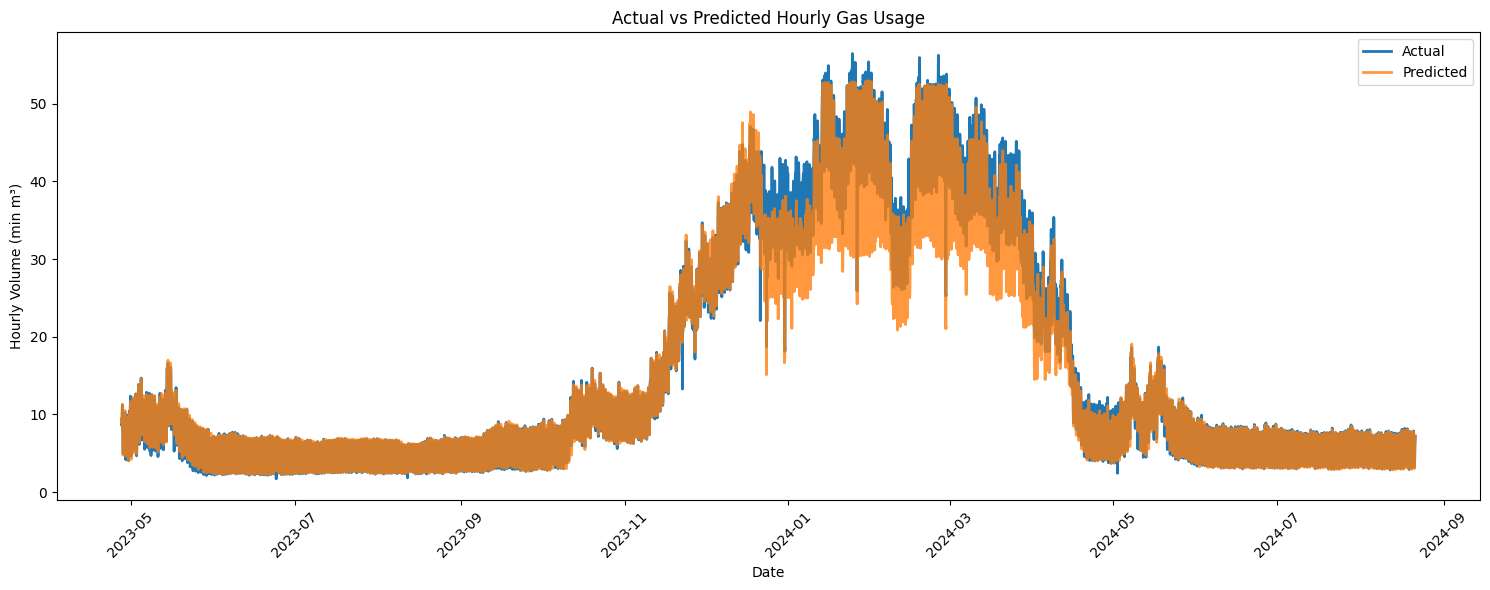

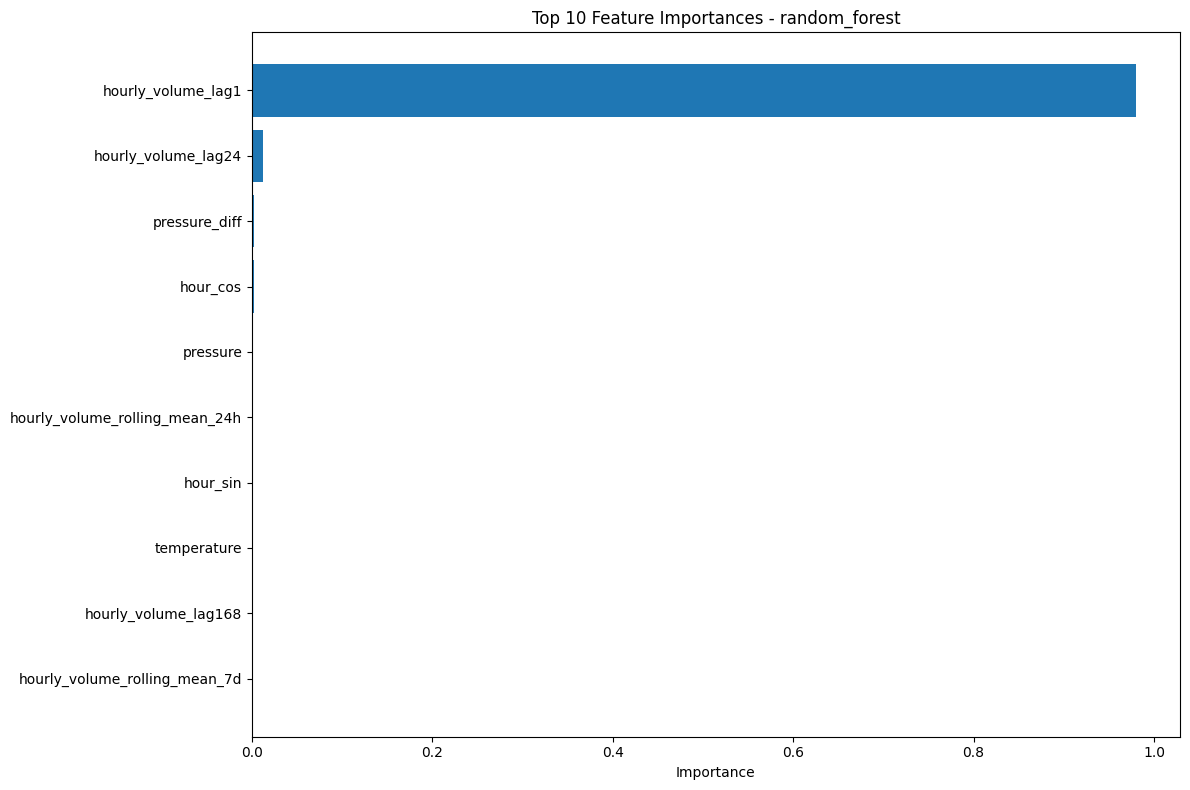


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9799
2. hourly_volume_lag24: 0.0122
3. pressure_diff: 0.0024
4. hour_cos: 0.0019
5. pressure: 0.0009
✅ Model saved to models/gas_usage_model.pkl
✅ Model training completed and saved!


In [ ]:
from gas_prediction_fixed import train_model_colab, evaluate_all_models_colab, predict_future_colab
model = train_model_colab(data_path='data.csv', model_type='random_forest')

🔍 Starting comprehensive model evaluation...

Evaluating linear model:
Using Linear Regression
Training the model...

Model Evaluation:
Model Type: linear
Root Mean Squared Error: 1.0448
Mean Absolute Error: 0.6745
R² Score: 0.9950


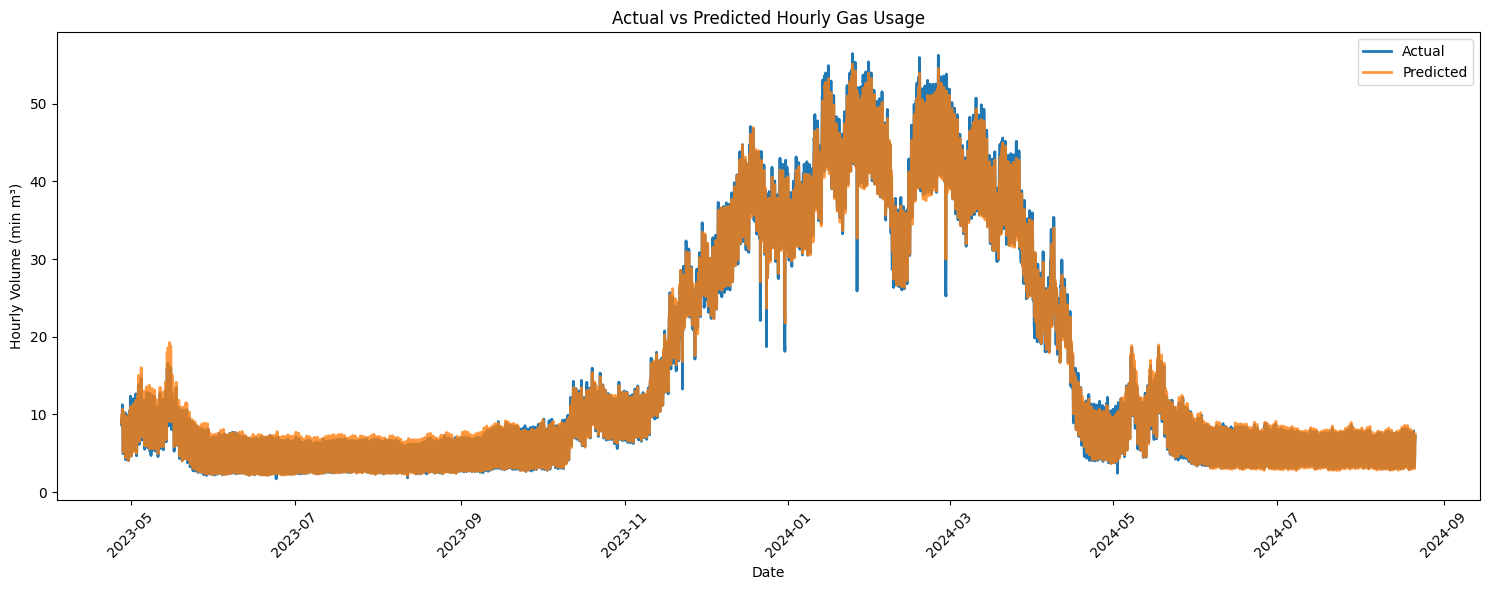


Evaluating random_forest model:
Using Random Forest Regressor
Training the model...

Model Evaluation:
Model Type: random_forest
Root Mean Squared Error: 2.5804
Mean Absolute Error: 1.2739
R² Score: 0.9693


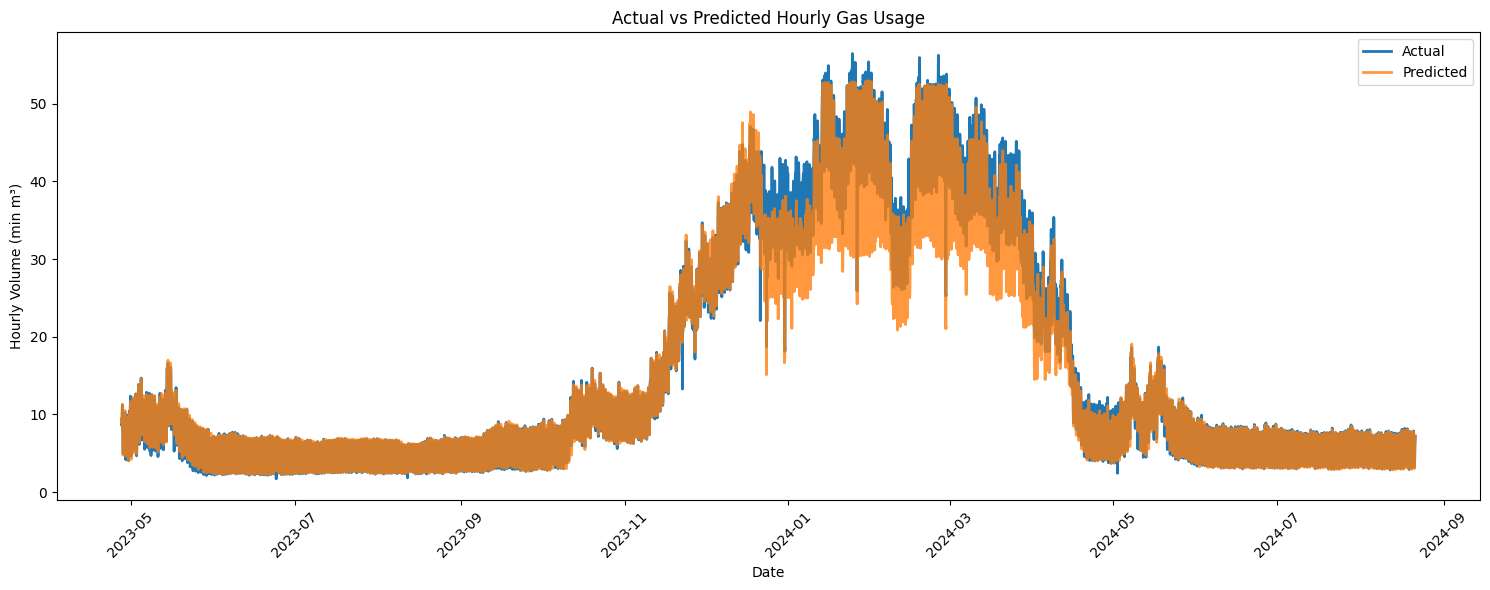

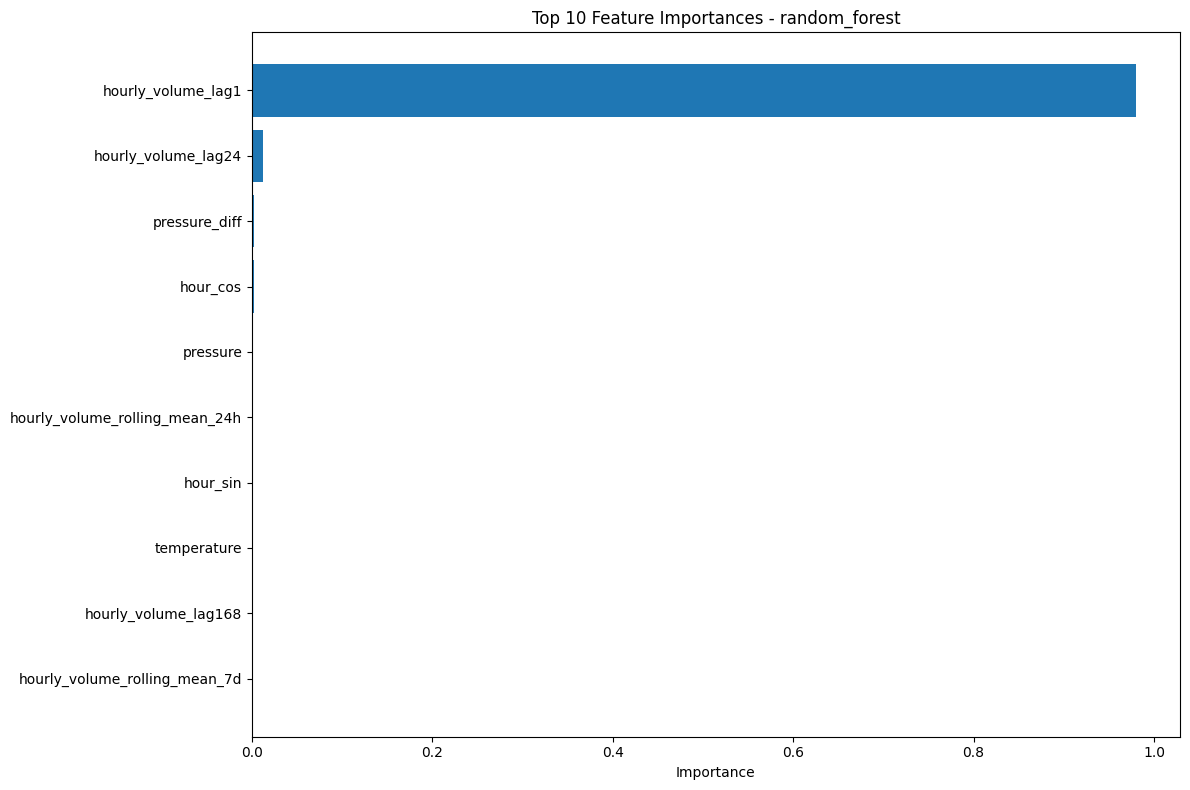


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9799
2. hourly_volume_lag24: 0.0122
3. pressure_diff: 0.0024
4. hour_cos: 0.0019
5. pressure: 0.0009

Evaluating gradient_boosting model:
Using Gradient Boosting Regressor
Training the model...

Model Evaluation:
Model Type: gradient_boosting
Root Mean Squared Error: 2.7950
Mean Absolute Error: 1.4571
R² Score: 0.9640


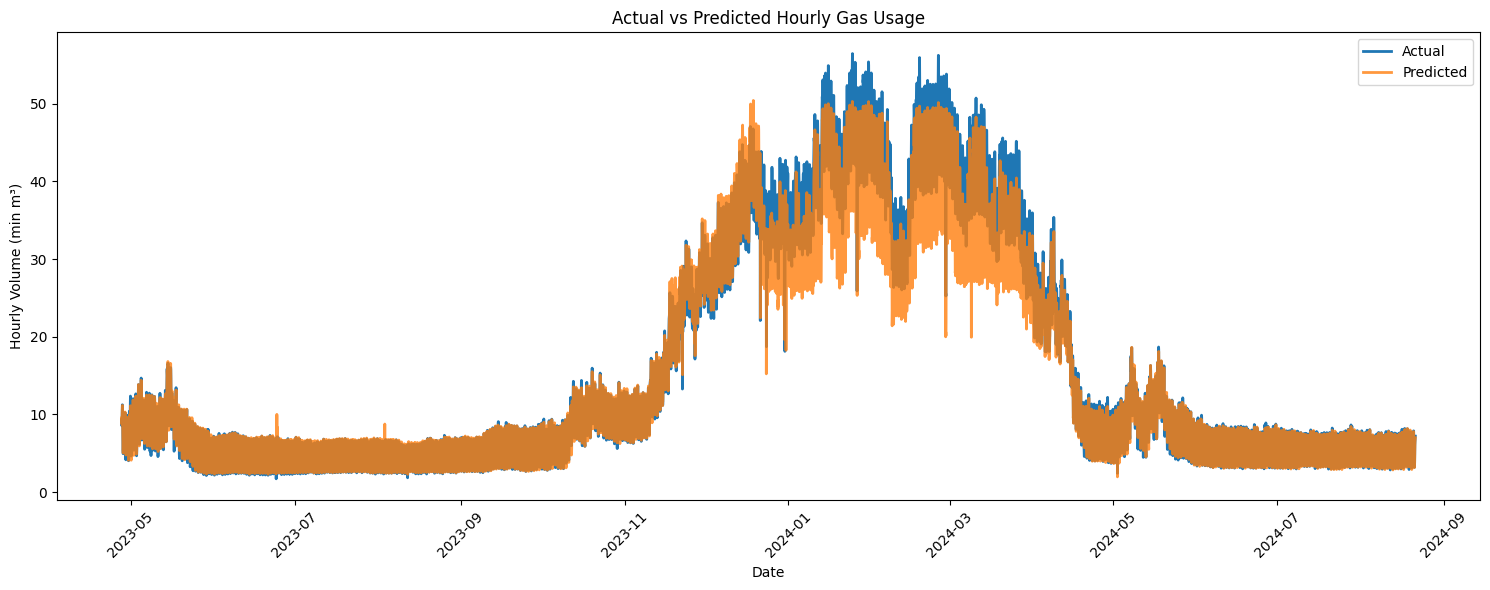

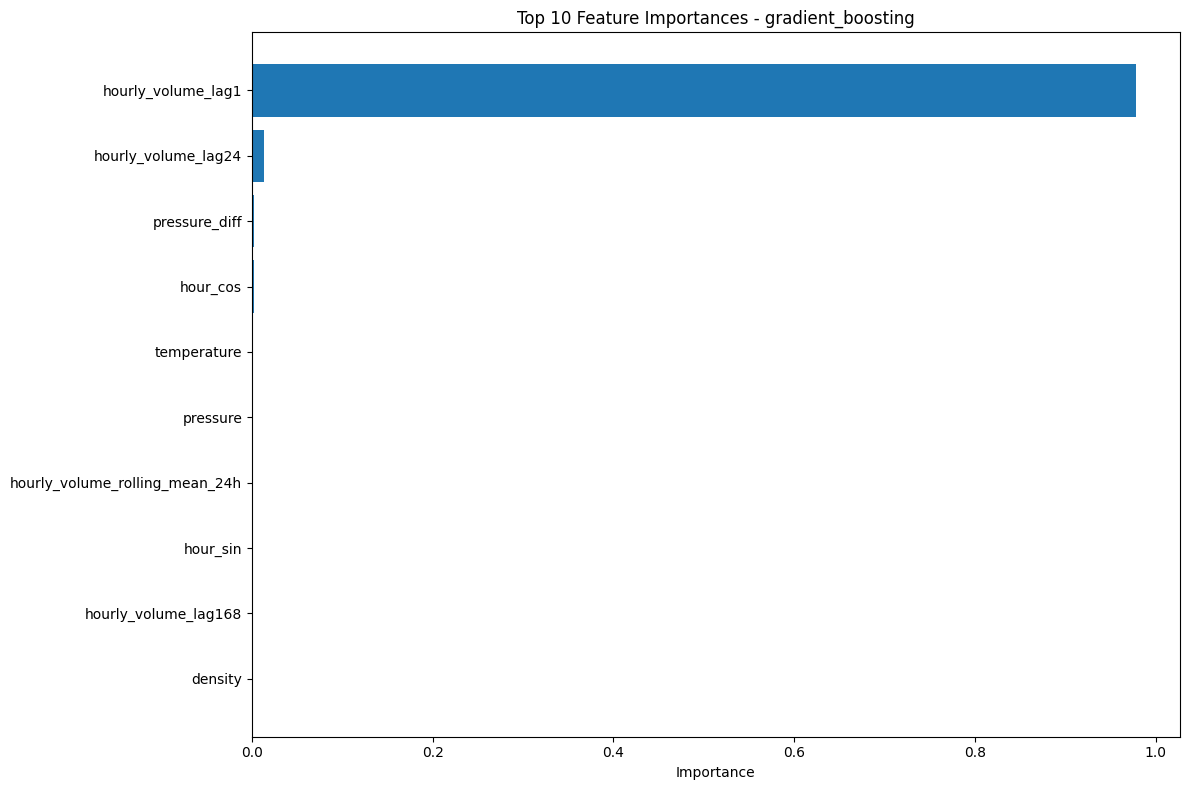


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9780
2. hourly_volume_lag24: 0.0134
3. pressure_diff: 0.0027
4. hour_cos: 0.0019
5. temperature: 0.0011

Evaluating xgboost model:
Using XGBoost Regressor
Training the model...

Model Evaluation:
Model Type: xgboost
Root Mean Squared Error: 3.0711
Mean Absolute Error: 1.5633
R² Score: 0.9565


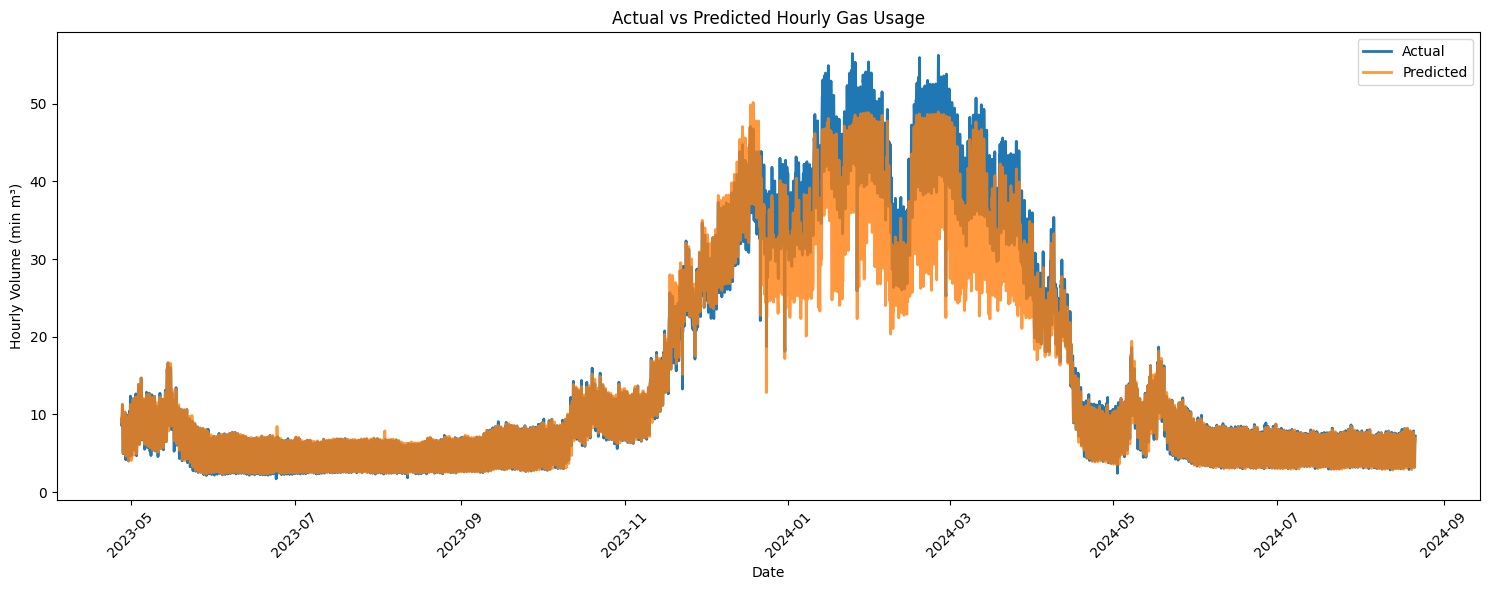

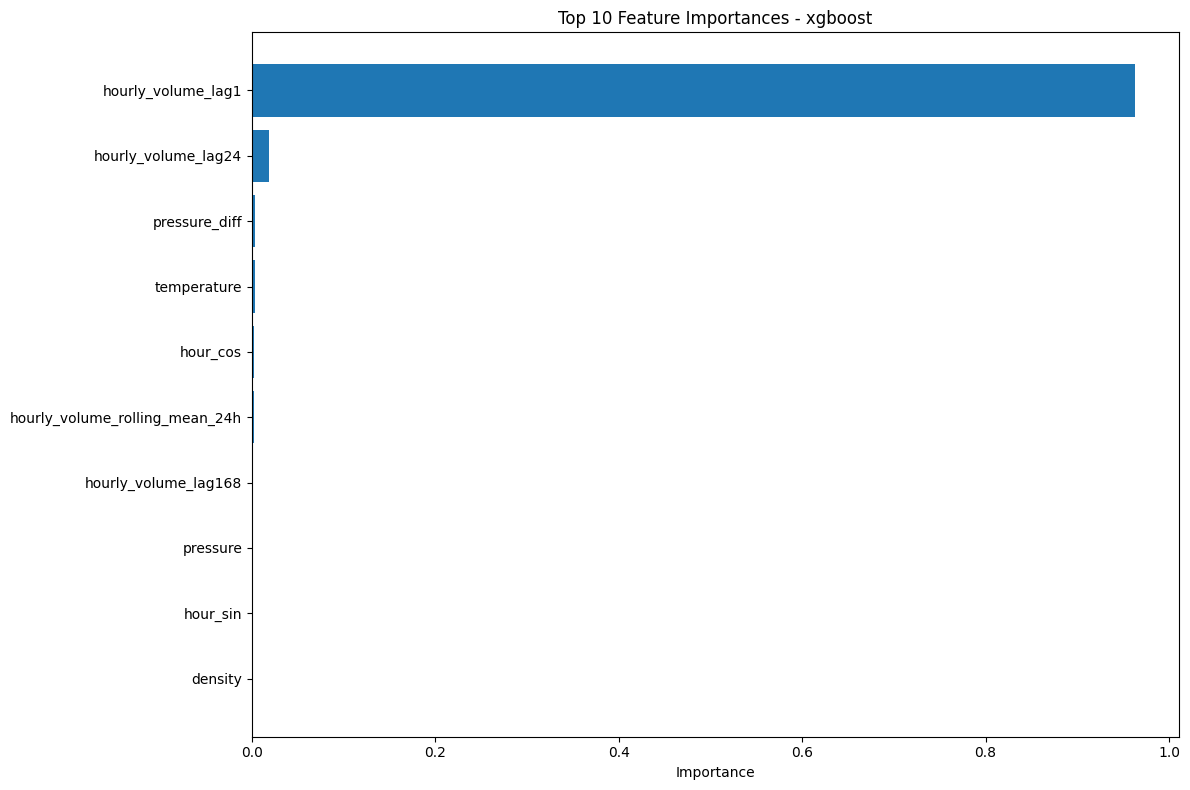


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9631
2. hourly_volume_lag24: 0.0184
3. pressure_diff: 0.0034
4. temperature: 0.0031
5. hour_cos: 0.0028

MODEL COMPARISON RESULTS:
                     rmse     mae      r2
linear             1.0448  0.6745  0.9950
random_forest      2.5804  1.2739  0.9693
gradient_boosting  2.7950  1.4571  0.9640
xgboost            3.0711  1.5633  0.9565

🏆 BEST MODEL: linear
   RMSE: 1.0448
   MAE: 0.6745
   R²: 0.9950

Retraining the best model (linear) and saving...
Using Linear Regression
Training the model...

Model Evaluation:
Model Type: linear
Root Mean Squared Error: 1.0448
Mean Absolute Error: 0.6745
R² Score: 0.9950


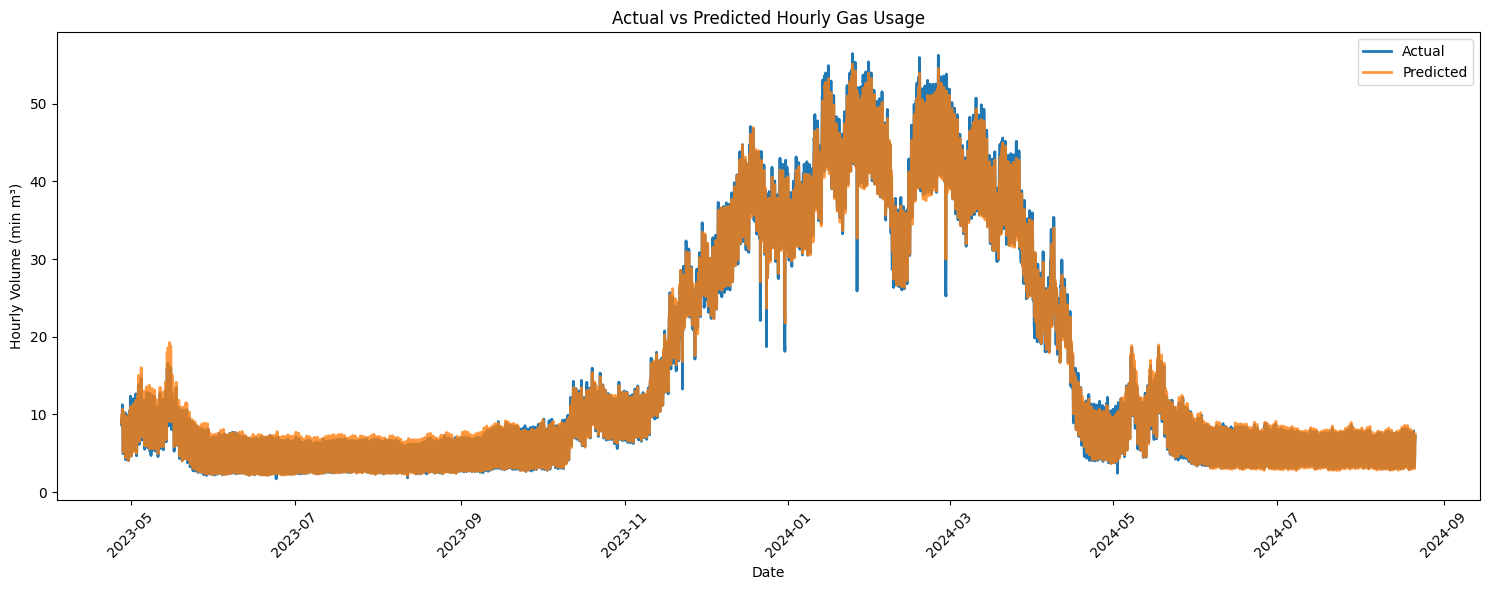

✅ Model saved to models/gas_usage_model.pkl
✅ Model evaluation completed!


In [ ]:
from gas_prediction_fixed import evaluate_all_models_colab
model, results = evaluate_all_models_colab(data_path='data.csv')

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os

def quick_predict(date_str, data_path='data/data.csv', model_path='models/gas_usage_model.pkl'):
    """Quick prediction function that works standalone."""

    print(f"🎯 Making prediction for: {date_str}")

    # Load the CSV data
    df = pd.read_csv('data.csv')

    # Convert timestamp to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')

    # Create time-based features
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['day_of_month'] = df['timestamp'].dt.day
    df['month'] = df['timestamp'].dt.month
    df['year'] = df['timestamp'].dt.year

    # Convert hour to cyclical features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

    # Sort by timestamp
    df = df.sort_values('timestamp')

    # Calculate lag features
    df['hourly_volume_lag1'] = df['hourly_volume'].shift(1)
    df['hourly_volume_lag24'] = df['hourly_volume'].shift(24)
    df['hourly_volume_lag168'] = df['hourly_volume'].shift(168)

    # Calculate rolling averages
    df['hourly_volume_rolling_mean_24h'] = df['hourly_volume'].rolling(window=24).mean()
    df['hourly_volume_rolling_mean_7d'] = df['hourly_volume'].rolling(window=168).mean()

    # Drop rows with NaN values
    df = df.dropna()

    # Load the trained model
    print("✅ Loading trained model...")
    model_data = joblib.load(model_path)
    model = model_data['model']
    scaler = model_data['scaler']
    features = model_data['features']

    # Parse the input date
    try:
        future_date = pd.to_datetime(date_str, format='%d,%m,%Y %H:%M')
    except:
        try:
            future_date = pd.to_datetime(date_str, format='%d-%m-%Y %H:%M')
        except:
            raise ValueError("Invalid date format. Please use 'DD,MM,YYYY HH:MM' or 'DD-MM-YYYY HH:MM'")

    # Check if prediction is far in the future
    if df['timestamp'].max() < future_date - pd.Timedelta(days=7):
        print("⚠️  Warning: Future date is more than 7 days from the most recent data.")
        print("   Prediction accuracy may be reduced.")

    # Create future record
    future_record = pd.DataFrame({
        'hour': [future_date.hour],
        'day_of_week': [future_date.dayofweek],
        'day_of_month': [future_date.day],
        'month': [future_date.month],
        'year': [future_date.year]
    })

    # Add cyclical features
    future_record['hour_sin'] = np.sin(2 * np.pi * future_record['hour']/24)
    future_record['hour_cos'] = np.cos(2 * np.pi * future_record['hour']/24)
    future_record['day_of_week_sin'] = np.sin(2 * np.pi * future_record['day_of_week']/7)
    future_record['day_of_week_cos'] = np.cos(2 * np.pi * future_record['day_of_week']/7)

    # Find similar hour data for filling other features
    similar_hour_data = df[df['hour'] == future_date.hour]
    if len(similar_hour_data) > 0:
        # Use recent similar hour data
        avg_values = similar_hour_data.iloc[-7:].mean()
        most_recent = similar_hour_data.iloc[-1]

        # Fill in remaining features
        for feature in features:
            if feature not in future_record.columns:
                if feature in df.columns:
                    if 'lag' in feature or 'rolling' in feature:
                        future_record[feature] = avg_values[feature]
                    else:
                        future_record[feature] = most_recent[feature]
    else:
        raise ValueError("Not enough historical data to make a prediction for this hour.")

    # Scale and predict
    X_future = future_record[features]
    X_future_scaled = scaler.transform(X_future)
    prediction = model.predict(X_future_scaled)[0]

    result = {
        'date': future_date.strftime('%d-%m-%Y %H:%M'),
        'predicted_hourly_volume': round(prediction, 2),
        'units': 'min m³'
    }

    print(f"\n🔮 PREDICTION RESULT:")
    print(f"   Date: {result['date']}")
    print(f"   Predicted Hourly Gas Volume: {result['predicted_hourly_volume']} {result['units']}")

    return result

# Now use it:
prediction = quick_predict('22,10,2026 14:00')

🎯 Making prediction for: 22,10,2026 14:00
✅ Loading trained model...
⚠️  Warning: Future date is more than 7 days from the most recent data.
   Prediction accuracy may be reduced.

🔮 PREDICTION RESULT:
   Date: 22-10-2026 14:00
   Predicted Hourly Gas Volume: 8.18 min m³


In [ ]:
%%writefile advanced_gas_prediction.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, TimeSeriesSplit, cross_val_score,
                                   validation_curve, learning_curve, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
import joblib
import datetime
import warnings
import os
from scipy import stats
from scipy.stats import pearsonr
import itertools
warnings.filterwarnings("ignore")

# Try to import XGBoost, fall back if not available
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available, using RandomForest as default")
    XGBOOST_AVAILABLE = False

class AdvancedGasUsagePredictionModel:
    def __init__(self, data_path='data/data.csv'):
        """Initialize the advanced gas usage prediction model with comprehensive overfitting detection."""
        self.data_path = data_path
        self.model = None
        self.scaler = StandardScaler()
        self.features = None
        self.data = None
        self.overfitting_results = {}

    def load_data(self):
        """Load and preprocess the data."""
        # Load the CSV data
        df = pd.read_csv(self.data_path)

        # Convert timestamp to datetime
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')

        # Create time-based features
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['day_of_month'] = df['timestamp'].dt.day
        df['month'] = df['timestamp'].dt.month
        df['year'] = df['timestamp'].dt.year

        # Convert hour to cyclical features to represent time's cyclic nature
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

        # Add day of week as cyclical features
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

        # Sort by timestamp to maintain time order
        df = df.sort_values('timestamp')

        # Calculate lag features (previous hour, day, week)
        df['hourly_volume_lag1'] = df['hourly_volume'].shift(1)
        df['hourly_volume_lag24'] = df['hourly_volume'].shift(24)  # Previous day, same hour
        df['hourly_volume_lag168'] = df['hourly_volume'].shift(168)  # Previous week, same hour

        # Calculate rolling averages
        df['hourly_volume_rolling_mean_24h'] = df['hourly_volume'].rolling(window=24).mean()
        df['hourly_volume_rolling_mean_7d'] = df['hourly_volume'].rolling(window=168).mean()

        # Drop rows with NaN values from lag creation
        df = df.dropna()

        # Store a copy of the original data
        self.data = df.copy()

        return df

    def prepare_features(self, df=None):
        """Prepare features for model training."""
        if df is None:
            df = self.load_data()

        # Features selection
        self.features = [
            'density', 'pressure_diff', 'pressure', 'temperature',
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'day_of_month', 'month',
            'hourly_volume_lag1', 'hourly_volume_lag24', 'hourly_volume_lag168',
            'hourly_volume_rolling_mean_24h', 'hourly_volume_rolling_mean_7d'
        ]

        # Target variable
        target = 'hourly_volume'

        # Split features and target
        X = df[self.features]
        y = df[target]

        return X, y

    def detect_data_leakage(self, X, y):
        """Advanced Method 1: Detect potential data leakage."""
        print("🔍 ADVANCED METHOD 1: DATA LEAKAGE DETECTION")
        print("="*60)

        leakage_detected = False

        # Check correlations between features and target
        correlations = {}
        for feature in self.features:
            if feature in X.columns:
                corr, p_value = pearsonr(X[feature], y)
                correlations[feature] = {'correlation': corr, 'p_value': p_value}

        # Sort by absolute correlation
        sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]['correlation']), reverse=True)

        print("📊 FEATURE-TARGET CORRELATIONS:")
        for feature, stats in sorted_corr[:10]:
            corr = stats['correlation']
            p_val = stats['p_value']

            if abs(corr) > 0.95:
                print(f"🚨 {feature}: {corr:.4f} (p={p_val:.4f}) - POTENTIAL LEAKAGE!")
                leakage_detected = True
            elif abs(corr) > 0.8:
                print(f"⚠️  {feature}: {corr:.4f} (p={p_val:.4f}) - High correlation")
            else:
                print(f"✅ {feature}: {corr:.4f} (p={p_val:.4f})")

        # Check for near-perfect linear combinations
        from sklearn.linear_model import LinearRegression
        lr_temp = LinearRegression()

        for feature in self.features:
            if feature in X.columns and 'lag' not in feature:
                other_features = [f for f in self.features if f != feature and f in X.columns]
                if len(other_features) > 0:
                    try:
                        lr_temp.fit(X[other_features], X[feature])
                        pred = lr_temp.predict(X[other_features])
                        r2_feature = r2_score(X[feature], pred)

                        if r2_feature > 0.95:
                            print(f"🚨 {feature} can be predicted from other features with R²={r2_feature:.4f}")
                            leakage_detected = True
                    except:
                        pass

        self.overfitting_results['data_leakage'] = {
            'detected': leakage_detected,
            'correlations': correlations
        }

        return leakage_detected

    def time_series_cross_validation_advanced(self, X, y, models_dict):
        """Advanced Method 2: Comprehensive Time Series Cross-Validation."""
        print("\n🔍 ADVANCED METHOD 2: COMPREHENSIVE TIME SERIES CV")
        print("="*60)

        # Different CV strategies
        cv_strategies = {
            'TimeSeriesSplit_3': TimeSeriesSplit(n_splits=3),
            'TimeSeriesSplit_5': TimeSeriesSplit(n_splits=5),
            'TimeSeriesSplit_10': TimeSeriesSplit(n_splits=10)
        }

        results = {}

        for cv_name, cv_strategy in cv_strategies.items():
            print(f"\n📈 Testing with {cv_name}:")
            results[cv_name] = {}

            for model_name, model in models_dict.items():
                scores = cross_val_score(model, X, y, cv=cv_strategy,
                                       scoring='r2', n_jobs=-1)

                mean_score = np.mean(scores)
                std_score = np.std(scores)

                results[cv_name][model_name] = {
                    'mean_r2': mean_score,
                    'std_r2': std_score,
                    'scores': scores
                }

                print(f"  {model_name}: R² = {mean_score:.4f} (±{std_score:.4f})")

                # Check for high variance (instability)
                if std_score > 0.1:
                    print(f"    ⚠️  HIGH VARIANCE - Unstable performance")
                elif std_score > 0.05:
                    print(f"    ⚠️  MODERATE VARIANCE")
                else:
                    print(f"    ✅ LOW VARIANCE - Stable performance")

        self.overfitting_results['time_series_cv'] = results
        return results

    def walk_forward_validation(self, X, y, models_dict, window_size=0.7):
        """Advanced Method 3: Walk-Forward Validation for Time Series."""
        print("\n🔍 ADVANCED METHOD 3: WALK-FORWARD VALIDATION")
        print("="*60)

        n_samples = len(X)
        initial_train_size = int(n_samples * window_size)
        results = {}

        for model_name, model in models_dict.items():
            print(f"\n🚀 Testing {model_name}:")

            predictions = []
            actuals = []
            train_scores = []
            test_scores = []

            # Walk forward through time
            for i in range(initial_train_size, n_samples - 1):
                # Train on all data up to point i
                X_train = X.iloc[:i]
                y_train = y.iloc[:i]

                # Test on next point
                X_test = X.iloc[i:i+1]
                y_test = y.iloc[i:i+1]

                # Fit model
                model_copy = type(model)(**model.get_params() if hasattr(model, 'get_params') else {})
                model_copy.fit(X_train, y_train)

                # Predict
                y_pred = model_copy.predict(X_test)[0]
                y_actual = y_test.iloc[0]

                predictions.append(y_pred)
                actuals.append(y_actual)

                # Track training performance
                train_pred = model_copy.predict(X_train)
                train_r2 = r2_score(y_train, train_pred)
                test_r2 = r2_score([y_actual], [y_pred])

                train_scores.append(train_r2)
                test_scores.append(test_r2)

            # Calculate overall metrics
            overall_r2 = r2_score(actuals, predictions)
            overall_rmse = np.sqrt(mean_squared_error(actuals, predictions))

            # Calculate performance degradation over time
            avg_train_r2 = np.mean(train_scores)
            avg_test_r2 = np.mean(test_scores)
            performance_gap = avg_train_r2 - avg_test_r2

            results[model_name] = {
                'overall_r2': overall_r2,
                'overall_rmse': overall_rmse,
                'avg_train_r2': avg_train_r2,
                'avg_test_r2': avg_test_r2,
                'performance_gap': performance_gap,
                'predictions': predictions,
                'actuals': actuals
            }

            print(f"  Overall R²: {overall_r2:.4f}")
            print(f"  Overall RMSE: {overall_rmse:.4f}")
            print(f"  Avg Train R²: {avg_train_r2:.4f}")
            print(f"  Avg Test R²: {avg_test_r2:.4f}")
            print(f"  Performance Gap: {performance_gap:.4f}")

            if performance_gap > 0.1:
                print(f"    🚨 HIGH GAP - Strong overfitting signal")
            elif performance_gap > 0.05:
                print(f"    ⚠️  MODERATE GAP - Some overfitting")
            else:
                print(f"    ✅ LOW GAP - Good generalization")

        self.overfitting_results['walk_forward'] = results
        return results

    def nested_cross_validation(self, X, y):
        """Advanced Method 4: Nested Cross-Validation for unbiased model selection."""
        print("\n🔍 ADVANCED METHOD 4: NESTED CROSS-VALIDATION")
        print("="*60)

        # Outer CV for final performance estimation
        outer_cv = TimeSeriesSplit(n_splits=3)

        # Inner CV for hyperparameter tuning
        inner_cv = TimeSeriesSplit(n_splits=3)

        # Models with hyperparameter grids
        models_params = {
            'Ridge': {
                'model': Ridge(),
                'params': {'alpha': [0.1, 1.0, 10.0, 100.0]}
            },
            'Random Forest': {
                'model': RandomForestRegressor(random_state=42),
                'params': {'n_estimators': [50, 100], 'max_depth': [5, 10, 15]}
            }
        }

        nested_results = {}

        for model_name, config in models_params.items():
            print(f"\n🔬 Nested CV for {model_name}:")

            outer_scores = []
            best_params_list = []

            for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):
                # Split data
                X_train_outer = X.iloc[train_idx]
                X_test_outer = X.iloc[test_idx]
                y_train_outer = y.iloc[train_idx]
                y_test_outer = y.iloc[test_idx]

                # Inner CV for hyperparameter tuning
                grid_search = GridSearchCV(
                    config['model'], config['params'],
                    cv=inner_cv, scoring='r2', n_jobs=-1
                )

                grid_search.fit(X_train_outer, y_train_outer)

                # Test best model on outer test set
                best_score = grid_search.score(X_test_outer, y_test_outer)
                outer_scores.append(best_score)
                best_params_list.append(grid_search.best_params_)

                print(f"  Fold {fold+1}: R² = {best_score:.4f}, Best params: {grid_search.best_params_}")

            # Final nested CV score
            nested_score = np.mean(outer_scores)
            nested_std = np.std(outer_scores)

            nested_results[model_name] = {
                'nested_score': nested_score,
                'nested_std': nested_std,
                'outer_scores': outer_scores,
                'best_params_list': best_params_list
            }

            print(f"  📊 Nested CV Score: {nested_score:.4f} (±{nested_std:.4f})")

        self.overfitting_results['nested_cv'] = nested_results
        return nested_results

    def bootstrap_validation(self, X, y, models_dict, n_bootstrap=100):
        """Advanced Method 5: Bootstrap Validation."""
        print("\n🔍 ADVANCED METHOD 5: BOOTSTRAP VALIDATION")
        print("="*60)

        bootstrap_results = {}

        for model_name, model in models_dict.items():
            print(f"\n🎲 Bootstrap validation for {model_name}:")

            bootstrap_scores = []

            for i in range(n_bootstrap):
                # Bootstrap sample
                indices = np.random.choice(len(X), size=len(X), replace=True)
                X_boot = X.iloc[indices]
                y_boot = y.iloc[indices]

                # Out-of-bag sample
                oob_indices = np.setdiff1d(np.arange(len(X)), indices)
                if len(oob_indices) > 0:
                    X_oob = X.iloc[oob_indices]
                    y_oob = y.iloc[oob_indices]

                    # Fit and predict
                    model_copy = type(model)(**model.get_params() if hasattr(model, 'get_params') else {})
                    model_copy.fit(X_boot, y_boot)
                    y_pred = model_copy.predict(X_oob)

                    # Score
                    score = r2_score(y_oob, y_pred)
                    bootstrap_scores.append(score)

            # Calculate confidence intervals
            scores_array = np.array(bootstrap_scores)
            mean_score = np.mean(scores_array)
            std_score = np.std(scores_array)
            ci_lower = np.percentile(scores_array, 2.5)
            ci_upper = np.percentile(scores_array, 97.5)

            bootstrap_results[model_name] = {
                'mean_score': mean_score,
                'std_score': std_score,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'scores': bootstrap_scores
            }

            print(f"  Mean R²: {mean_score:.4f} (±{std_score:.4f})")
            print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

        self.overfitting_results['bootstrap'] = bootstrap_results
        return bootstrap_results

    def learning_curves_comprehensive(self, X, y, models_dict):
        """Advanced Method 6: Comprehensive Learning Curves Analysis."""
        print("\n🔍 ADVANCED METHOD 6: COMPREHENSIVE LEARNING CURVES")
        print("="*60)

        train_sizes = np.linspace(0.1, 1.0, 10)
        learning_results = {}

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.ravel()

        for idx, (model_name, model) in enumerate(models_dict.items()):
            if idx >= 4:  # Only plot first 4 models
                break

            print(f"\n📈 Learning curves for {model_name}:")

            train_sizes_abs, train_scores, val_scores = learning_curve(
                model, X, y, train_sizes=train_sizes,
                cv=TimeSeriesSplit(n_splits=3), scoring='r2', n_jobs=-1
            )

            # Calculate statistics
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)

            # Check for overfitting patterns
            final_gap = train_mean[-1] - val_mean[-1]
            gap_trend = np.polyfit(range(len(train_mean)), train_mean - val_mean, 1)[0]

            learning_results[model_name] = {
                'train_sizes': train_sizes_abs,
                'train_mean': train_mean,
                'val_mean': val_mean,
                'final_gap': final_gap,
                'gap_trend': gap_trend
            }

            # Plot
            axes[idx].plot(train_sizes_abs, train_mean, 'o-', label='Training')
            axes[idx].fill_between(train_sizes_abs, train_mean - train_std,
                                 train_mean + train_std, alpha=0.1)

            axes[idx].plot(train_sizes_abs, val_mean, 's-', label='Validation')
            axes[idx].fill_between(train_sizes_abs, val_mean - val_std,
                                 val_mean + val_std, alpha=0.1)

            axes[idx].set_title(f'{model_name}')
            axes[idx].set_xlabel('Training Size')
            axes[idx].set_ylabel('R² Score')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

            print(f"  Final gap: {final_gap:.4f}")
            print(f"  Gap trend: {gap_trend:.6f} (negative = converging)")

            if final_gap > 0.1:
                print(f"    🚨 LARGE GAP - Strong overfitting")
            elif final_gap > 0.05:
                print(f"    ⚠️  MODERATE GAP - Some overfitting")
            else:
                print(f"    ✅ SMALL GAP - Good generalization")

        plt.tight_layout()
        plt.show()

        self.overfitting_results['learning_curves'] = learning_results
        return learning_results

    def residual_analysis_advanced(self, X, y, models_dict):
        """Advanced Method 7: Comprehensive Residual Analysis."""
        print("\n🔍 ADVANCED METHOD 7: ADVANCED RESIDUAL ANALYSIS")
        print("="*60)

        # Split data
        split_point = int(len(X) * 0.8)
        X_train, X_test = X[:split_point], X[split_point:]
        y_train, y_test = y[:split_point], y[split_point:]

        residual_results = {}

        fig, axes = plt.subplots(len(models_dict), 4, figsize=(20, 5*len(models_dict)))
        if len(models_dict) == 1:
            axes = axes.reshape(1, -1)

        for idx, (model_name, model) in enumerate(models_dict.items()):
            print(f"\n🔬 Residual analysis for {model_name}:")

            # Fit model
            model.fit(X_train, y_train)

            # Predictions
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

            # Residuals
            residuals_train = y_train - y_pred_train
            residuals_test = y_test.values - y_pred_test

            # Statistical tests
            # 1. Normality test (Shapiro-Wilk)
            shapiro_stat, shapiro_p = stats.shapiro(residuals_test[:min(5000, len(residuals_test))])

            # 2. Autocorrelation test (Durbin-Watson)
            from statsmodels.stats.diagnostic import acorr_ljungbox
            ljung_box_stat, ljung_box_p = acorr_ljungbox(residuals_test, lags=10, return_df=False)

            # 3. Heteroscedasticity test (White test)
            from sklearn.linear_model import LinearRegression
            lr_temp = LinearRegression()
            try:
                # Regress squared residuals on predictions
                residuals_squared = residuals_test ** 2
                lr_temp.fit(y_pred_test.reshape(-1, 1), residuals_squared)
                pred_sq_res = lr_temp.predict(y_pred_test.reshape(-1, 1))
                white_stat = len(residuals_test) * r2_score(residuals_squared, pred_sq_res)
                white_p = 1 - stats.chi2.cdf(white_stat, df=1)
            except:
                white_stat, white_p = np.nan, np.nan

            residual_results[model_name] = {
                'shapiro_stat': shapiro_stat,
                'shapiro_p': shapiro_p,
                'ljung_box_stat': ljung_box_stat,
                'ljung_box_p': ljung_box_p,
                'white_stat': white_stat,
                'white_p': white_p,
                'residuals_mean': np.mean(residuals_test),
                'residuals_std': np.std(residuals_test)
            }

            # Plotting
            # 1. Residuals vs Fitted
            axes[idx, 0].scatter(y_pred_test, residuals_test, alpha=0.6)
            axes[idx, 0].axhline(y=0, color='r', linestyle='--')
            axes[idx, 0].set_xlabel('Fitted Values')
            axes[idx, 0].set_ylabel('Residuals')
            axes[idx, 0].set_title(f'{model_name}: Residuals vs Fitted')
            axes[idx, 0].grid(True, alpha=0.3)

            # 2. Q-Q plot
            stats.probplot(residuals_test, dist="norm", plot=axes[idx, 1])
            axes[idx, 1].set_title(f'{model_name}: Q-Q Plot')

            # 3. Histogram of residuals
            axes[idx, 2].hist(residuals_test, bins=30, alpha=0.7, edgecolor='black')
            axes[idx, 2].set_xlabel('Residuals')
            axes[idx, 2].set_ylabel('Frequency')
            axes[idx, 2].set_title(f'{model_name}: Residuals Distribution')
            axes[idx, 2].grid(True, alpha=0.3)

            # 4. Residuals over time
            axes[idx, 3].plot(residuals_test, alpha=0.7)
            axes[idx, 3].axhline(y=0, color='r', linestyle='--')
            axes[idx, 3].set_xlabel('Time Index')
            axes[idx, 3].set_ylabel('Residuals')
            axes[idx, 3].set_title(f'{model_name}: Residuals Over Time')
            axes[idx, 3].grid(True, alpha=0.3)

            # Statistical interpretation
            print(f"  Normality (Shapiro): p = {shapiro_p:.4f} {'✅' if shapiro_p > 0.05 else '❌'}")
            print(f"  Autocorrelation (Ljung-Box): p = {ljung_box_p:.4f} {'✅' if ljung_box_p > 0.05 else '❌'}")
            print(f"  Homoscedasticity (White): p = {white_p:.4f} {'✅' if white_p > 0.05 else '❌'}")

        plt.tight_layout()
        plt.show()

        self.overfitting_results['residual_analysis'] = residual_results
        return residual_results

    def feature_importance_stability(self, X, y, models_dict):
        """Advanced Method 8: Feature Importance Stability Analysis."""
        print("\n🔍 ADVANCED METHOD 8: FEATURE IMPORTANCE STABILITY")
        print("="*60)

        stability_results = {}

        # Only analyze tree-based models that have feature importance
        tree_models = {name: model for name, model in models_dict.items()
                      if hasattr(model, 'feature_importances_') or
                      type(model).__name__ in ['RandomForestRegressor', 'GradientBoostingRegressor', 'XGBRegressor']}

        if not tree_models:
            print("❌ No tree-based models found for feature importance analysis")
            return {}

        cv = TimeSeriesSplit(n_splits=5)

        for model_name, model in tree_models.items():
            print(f"\n🌳 Feature importance stability for {model_name}:")

            importance_matrix = []

            for fold, (train_idx, val_idx) in enumerate(cv.split(X)):
                X_train_fold = X.iloc[train_idx]
                y_train_fold = y.iloc[train_idx]

                # Fit model
                model_copy = type(model)(**model.get_params())
                model_copy.fit(X_train_fold, y_train_fold)

                # Get feature importance
                if hasattr(model_copy, 'feature_importances_'):
                    importance_matrix.append(model_copy.feature_importances_)

            if importance_matrix:
                importance_matrix = np.array(importance_matrix)

                # Calculate stability metrics
                mean_importance = np.mean(importance_matrix, axis=0)
                std_importance = np.std(importance_matrix, axis=0)
                cv_importance = std_importance / (mean_importance + 1e-8)  # Coefficient of variation

                # Create feature importance DataFrame
                importance_df = pd.DataFrame({
                    'Feature': self.features,
                    'Mean_Importance': mean_importance,
                    'Std_Importance': std_importance,
                    'CV_Importance': cv_importance
                }).sort_values('Mean_Importance', ascending=False)

                stability_results[model_name] = importance_df

                print("  📊 Top 5 Most Important Features:")
                for i, (_, row) in enumerate(importance_df.head().iterrows()):
                    stability_status = "✅ Stable" if row['CV_Importance'] < 0.3 else "⚠️ Unstable"
                    print(f"    {i+1}. {row['Feature']}: {row['Mean_Importance']:.4f} "
                          f"(CV: {row['CV_Importance']:.3f}) {stability_status}")

        # Plot feature importance stability
        if stability_results:
            fig, axes = plt.subplots(len(stability_results), 1, figsize=(12, 6*len(stability_results)))
            if len(stability_results) == 1:
                axes = [axes]

            for idx, (model_name, importance_df) in enumerate(stability_results.items()):
                top_features = importance_df.head(10)

                bars = axes[idx].bar(range(len(top_features)), top_features['Mean_Importance'],
                                   yerr=top_features['Std_Importance'], capsize=3)
                axes[idx].set_xlabel('Features')
                axes[idx].set_ylabel('Importance')
                axes[idx].set_title(f'{model_name}: Feature Importance Stability')
                axes[idx].set_xticks(range(len(top_features)))
                axes[idx].set_xticklabels(top_features['Feature'], rotation=45, ha='right')
                axes[idx].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        self.overfitting_results['feature_stability'] = stability_results
        return stability_results

    def comprehensive_overfitting_report(self):
        """Generate comprehensive overfitting assessment report."""
        print("\n" + "="*80)
        print("🎯 COMPREHENSIVE OVERFITTING ASSESSMENT REPORT")
        print("="*80)

        # Prepare data
        df = self.load_data()
        X, y = self.prepare_features(df)

        # Scale features
        X_scaled = pd.DataFrame(self.scaler.fit_transform(X),
                               columns=X.columns, index=X.index)

        # Define models to test
        models_dict = {
            'Linear Regression': LinearRegression(),
            'Ridge (alpha=1.0)': Ridge(alpha=1.0),
            'Ridge (alpha=10.0)': Ridge(alpha=10.0),
            'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                          max_depth=5, random_state=42)
        }

        if XGBOOST_AVAILABLE:
            models_dict['XGBoost'] = XGBRegressor(n_estimators=100, learning_rate=0.1,
                                                max_depth=5, random_state=42)

        print(f"📊 Analyzing {len(models_dict)} models with {len(X)} samples and {len(self.features)} features")

        # Run all advanced overfitting detection methods
        self.detect_data_leakage(X_scaled, y)
        self.time_series_cross_validation_advanced(X_scaled, y, models_dict)
        self.walk_forward_validation(X_scaled, y, models_dict)
        self.nested_cross_validation(X_scaled, y)
        self.bootstrap_validation(X_scaled, y, models_dict)
        self.learning_curves_comprehensive(X_scaled, y, models_dict)
        self.residual_analysis_advanced(X_scaled, y, models_dict)
        self.feature_importance_stability(X_scaled, y, models_dict)

        # Final comprehensive assessment
        print("\n" + "="*80)
        print("🏆 FINAL COMPREHENSIVE ASSESSMENT")
        print("="*80)

        risk_score = 0
        max_risk_score = 8

        # Check 1: Data leakage
        if self.overfitting_results.get('data_leakage', {}).get('detected', False):
            risk_score += 2
            print("❌ Data leakage detected (+2 points)")
        else:
            print("✅ No data leakage detected (0 points)")

        # Check 2: Cross-validation stability
        cv_results = self.overfitting_results.get('time_series_cv', {})
        high_variance_count = 0
        for cv_name, cv_result in cv_results.items():
            for model_name, result in cv_result.items():
                if result['std_r2'] > 0.1:
                    high_variance_count += 1

        if high_variance_count > len(models_dict) * 0.5:
            risk_score += 1
            print("❌ High variance in cross-validation (+1 point)")
        else:
            print("✅ Stable cross-validation performance (0 points)")

        # Check 3: Walk-forward validation gaps
        wf_results = self.overfitting_results.get('walk_forward', {})
        high_gap_count = 0
        for model_name, result in wf_results.items():
            if result['performance_gap'] > 0.1:
                high_gap_count += 1

        if high_gap_count > 0:
            risk_score += 2
            print("❌ High performance gaps in walk-forward validation (+2 points)")
        elif high_gap_count > len(models_dict) * 0.3:
            risk_score += 1
            print("⚠️  Some performance gaps in walk-forward validation (+1 point)")
        else:
            print("✅ Good walk-forward validation performance (0 points)")

        # Check 4: Learning curves
        lc_results = self.overfitting_results.get('learning_curves', {})
        high_gap_lc_count = 0
        for model_name, result in lc_results.items():
            if result['final_gap'] > 0.1:
                high_gap_lc_count += 1

        if high_gap_lc_count > len(models_dict) * 0.5:
            risk_score += 1
            print("❌ Learning curves show overfitting (+1 point)")
        else:
            print("✅ Learning curves look good (0 points)")

        # Check 5: Residual analysis
        residual_results = self.overfitting_results.get('residual_analysis', {})
        residual_issues = 0
        for model_name, result in residual_results.items():
            if result['shapiro_p'] < 0.05:  # Non-normal residuals
                residual_issues += 1
            if result['ljung_box_p'] < 0.05:  # Autocorrelated residuals
                residual_issues += 1

        if residual_issues > len(models_dict):
            risk_score += 1
            print("❌ Residual analysis shows model inadequacy (+1 point)")
        else:
            print("✅ Residual analysis looks acceptable (0 points)")

        # Check 6: Feature importance stability
        stability_results = self.overfitting_results.get('feature_stability', {})
        unstable_features = 0
        for model_name, importance_df in stability_results.items():
            unstable_count = (importance_df['CV_Importance'] > 0.5).sum()
            unstable_features += unstable_count

        if unstable_features > len(self.features) * 0.3:
            risk_score += 1
            print("❌ Feature importance is unstable (+1 point)")
        else:
            print("✅ Feature importance is stable (0 points)")

        # Final verdict
        risk_percentage = (risk_score / max_risk_score) * 100

        print(f"\n🎯 OVERFITTING RISK SCORE: {risk_score}/{max_risk_score} ({risk_percentage:.1f}%)")

        if risk_percentage >= 75:
            verdict = "🚨 SEVERE OVERFITTING RISK"
            recommendations = [
                "Use regularization (Ridge/Lasso with higher alpha)",
                "Remove lag features or reduce their number",
                "Collect more diverse training data",
                "Use simpler models",
                "Apply feature selection techniques",
                "Consider ensemble methods with different base models"
            ]
        elif risk_percentage >= 50:
            verdict = "⚠️  HIGH OVERFITTING RISK"
            recommendations = [
                "Add mild regularization",
                "Use more conservative cross-validation",
                "Monitor performance on completely new data",
                "Consider reducing model complexity",
                "Validate predictions manually on known cases"
            ]
        elif risk_percentage >= 25:
            verdict = "⚠️  MODERATE OVERFITTING RISK"
            recommendations = [
                "Continue monitoring with new data",
                "Consider light regularization",
                "Validate on recent unseen data",
                "Document model limitations clearly"
            ]
        else:
            verdict = "✅ LOW OVERFITTING RISK"
            recommendations = [
                "Model appears to generalize well",
                "Continue monitoring with production data",
                "Regular retraining with new data",
                "Document model performance benchmarks"
            ]

        print(f"\n{verdict}")
        print(f"\n💡 ACTIONABLE RECOMMENDATIONS:")
        for i, rec in enumerate(recommendations, 1):
            print(f"   {i}. {rec}")

        # Save results
        self.overfitting_results['final_assessment'] = {
            'risk_score': risk_score,
            'risk_percentage': risk_percentage,
            'verdict': verdict,
            'recommendations': recommendations
        }

        return self.overfitting_results

    def train_model_with_overfitting_protection(self, model_type='ridge', alpha=1.0):
        """Train model with built-in overfitting protection based on analysis."""
        print(f"\n🛡️  TRAINING MODEL WITH OVERFITTING PROTECTION")
        print("="*60)

        # Load and prepare data
        df = self.load_data()
        X, y = self.prepare_features(df)
        X_scaled = self.scaler.fit_transform(X)

        # Select model with regularization
        if model_type == 'ridge':
            self.model = Ridge(alpha=alpha)
            print(f"Using Ridge Regression with alpha={alpha}")
        elif model_type == 'lasso':
            self.model = Lasso(alpha=alpha)
            print(f"Using Lasso Regression with alpha={alpha}")
        elif model_type == 'elastic_net':
            self.model = ElasticNet(alpha=alpha, l1_ratio=0.5)
            print(f"Using Elastic Net with alpha={alpha}")
        elif model_type == 'random_forest':
            self.model = RandomForestRegressor(
                n_estimators=50, max_depth=10, min_samples_split=10,
                min_samples_leaf=5, random_state=42
            )
            print("Using Random Forest with conservative parameters")
        else:
            self.model = LinearRegression()
            print("Using Linear Regression")

        # Time series split for proper validation
        tscv = TimeSeriesSplit(n_splits=5)
        scores = cross_val_score(self.model, X_scaled, y, cv=tscv, scoring='r2')

        print(f"Cross-validation R² scores: {scores}")
        print(f"Mean CV R²: {np.mean(scores):.4f} (±{np.std(scores):.4f})")

        # Train final model on all data
        self.model.fit(X_scaled, y)

        # Make predictions for evaluation
        y_pred = self.model.predict(X_scaled)
        train_r2 = r2_score(y, y_pred)
        train_rmse = np.sqrt(mean_squared_error(y, y_pred))

        print(f"Final model training R²: {train_r2:.4f}")
        print(f"Final model training RMSE: {train_rmse:.4f}")
        print(f"Gap between training and CV: {train_r2 - np.mean(scores):.4f}")

        return {
            'model': self.model,
            'cv_scores': scores,
            'train_r2': train_r2,
            'train_rmse': train_rmse
        }

    def save_model(self, model_path='models/gas_usage_model.pkl'):
        """Save the trained model and all analysis results."""
        if self.model is None:
            raise ValueError("Model has not been trained yet")

        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        # Save model, scaler, features, and overfitting analysis
        joblib.dump({
            'model': self.model,
            'scaler': self.scaler,
            'features': self.features,
            'overfitting_results': self.overfitting_results
        }, model_path)

        print(f"✅ Model and analysis results saved to {model_path}")

# Example usage
if __name__ == "__main__":
    # Initialize advanced model
    advanced_model = AdvancedGasUsagePredictionModel(data_path='data/data.csv')

    # Run comprehensive overfitting analysis
    results = advanced_model.comprehensive_overfitting_report()

    # Train model with overfitting protection
    model_results = advanced_model.train_model_with_overfitting_protection(
        model_type='ridge', alpha=10.0
    )

    # Save everything
    advanced_model.save_model()

Writing advanced_gas_prediction.py


In [ ]:
"""
Run Advanced Gas Prediction with Comprehensive Overfitting Detection

This script runs the most advanced overfitting detection methods on your gas usage data.
"""

from advanced_gas_prediction import AdvancedGasUsagePredictionModel
import warnings
warnings.filterwarnings("ignore")

def main():
    print("🚀 STARTING ADVANCED GAS USAGE ANALYSIS")
    print("="*80)

    # Initialize the advanced model
    model = AdvancedGasUsagePredictionModel(data_path='data.csv')

    print("📋 This analysis will run 8 advanced overfitting detection methods:")
    print("   1. Data Leakage Detection")
    print("   2. Time Series Cross-Validation (3 strategies)")
    print("   3. Walk-Forward Validation")
    print("   4. Nested Cross-Validation")
    print("   5. Bootstrap Validation")
    print("   6. Learning Curves Analysis")
    print("   7. Advanced Residual Analysis")
    print("   8. Feature Importance Stability")
    print("\n⏱️  This may take 10-15 minutes to complete...\n")

    try:
        # Run comprehensive analysis
        results = model.comprehensive_overfitting_report()

        print("\n🎉 ANALYSIS COMPLETE!")
        print("="*50)

        # Display final assessment
        final_assessment = results.get('final_assessment', {})
        print(f"Risk Score: {final_assessment.get('risk_score', 'N/A')}/8")
        print(f"Risk Level: {final_assessment.get('risk_percentage', 'N/A')}%")
        print(f"Verdict: {final_assessment.get('verdict', 'N/A')}")

        # Train protected model based on results
        print("\n🛡️  Training model with overfitting protection...")

        risk_percentage = final_assessment.get('risk_percentage', 0)

        if risk_percentage >= 75:
            # High risk - use strong regularization
            model_results = model.train_model_with_overfitting_protection(
                model_type='ridge', alpha=100.0
            )
            print("✅ Used Ridge regression with strong regularization (alpha=100)")
        elif risk_percentage >= 50:
            # Moderate risk - use moderate regularization
            model_results = model.train_model_with_overfitting_protection(
                model_type='ridge', alpha=10.0
            )
            print("✅ Used Ridge regression with moderate regularization (alpha=10)")
        elif risk_percentage >= 25:
            # Low-moderate risk - use light regularization
            model_results = model.train_model_with_overfitting_protection(
                model_type='ridge', alpha=1.0
            )
            print("✅ Used Ridge regression with light regularization (alpha=1)")
        else:
            # Very low risk - minimal regularization
            model_results = model.train_model_with_overfitting_protection(
                model_type='ridge', alpha=0.1
            )
            print("✅ Used Ridge regression with minimal regularization (alpha=0.1)")

        # Save the model and results
        model.save_model('models/advanced_gas_model.pkl')

        print(f"\n📊 FINAL MODEL PERFORMANCE:")
        print(f"Cross-Validation R²: {model_results['cv_scores'].mean():.4f} (±{model_results['cv_scores'].std():.4f})")
        print(f"Training R²: {model_results['train_r2']:.4f}")
        print(f"Training RMSE: {model_results['train_rmse']:.4f}")

        # Summary recommendations
        print(f"\n💡 KEY RECOMMENDATIONS:")
        recommendations = final_assessment.get('recommendations', [])
        for i, rec in enumerate(recommendations[:3], 1):  # Show top 3
            print(f"   {i}. {rec}")

        print("\n✅ Analysis complete! Check the generated plots and saved model.")

        return results, model_results

    except Exception as e:
        print(f"❌ Error during analysis: {e}")
        print("Please check your data file path and format.")
        return None, None

if __name__ == "__main__":
    results, model_results = main()

    if results:
        print("\n🎯 QUICK OVERFITTING CHECK:")
        risk_score = results['final_assessment']['risk_score']

        if risk_score >= 6:
            print("🚨 SEVERE OVERFITTING - Your original 99.5% accuracy is likely overfitted")
        elif risk_score >= 4:
            print("⚠️  HIGH OVERFITTING RISK - Be very cautious with the model")
        elif risk_score >= 2:
            print("⚠️  MODERATE RISK - Monitor performance closely")
        else:
            print("✅ LOW RISK - Model appears reasonable")

        print(f"\nDetailed results saved in: models/advanced_gas_model.pkl")
        print("All plots and analysis have been displayed above.")

🚀 STARTING ADVANCED GAS USAGE ANALYSIS
📋 This analysis will run 8 advanced overfitting detection methods:
   1. Data Leakage Detection
   2. Time Series Cross-Validation (3 strategies)
   3. Walk-Forward Validation
   4. Nested Cross-Validation
   5. Bootstrap Validation
   6. Learning Curves Analysis
   7. Advanced Residual Analysis
   8. Feature Importance Stability

⏱️  This may take 10-15 minutes to complete...


🎯 COMPREHENSIVE OVERFITTING ASSESSMENT REPORT
📊 Analyzing 6 models with 57834 samples and 15 features
🔍 ADVANCED METHOD 1: DATA LEAKAGE DETECTION
📊 FEATURE-TARGET CORRELATIONS:
🚨 hourly_volume_lag1: 0.9951 (p=0.0000) - POTENTIAL LEAKAGE!
🚨 hourly_volume_lag24: 0.9858 (p=0.0000) - POTENTIAL LEAKAGE!
🚨 hourly_volume_rolling_mean_24h: 0.9774 (p=0.0000) - POTENTIAL LEAKAGE!
🚨 hourly_volume_rolling_mean_7d: 0.9638 (p=0.0000) - POTENTIAL LEAKAGE!
⚠️  hourly_volume_lag168: 0.9486 (p=0.0000) - High correlation
✅ pressure: 0.7868 (p=0.0000)
✅ pressure_diff: 0.6481 (p=0.0000)
✅ mont

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

class ImprovedGasPredictionModel:
    def __init__(self, data_path='data/data.csv'):
        self.data_path = data_path
        self.model = None
        self.scaler = StandardScaler()
        self.features = None

    def load_and_engineer_features(self):
        """Load data and create features WITHOUT data leakage."""
        df = pd.read_csv(self.data_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')
        df = df.sort_values('timestamp')

        # Time-based features (no leakage)
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['day_of_month'] = df['timestamp'].dt.day
        df['month'] = df['timestamp'].dt.month
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

        # Cyclical time features
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
        df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
        df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

        # Environmental features (no leakage)
        df['temp_pressure_interaction'] = df['temperature'] * df['pressure']
        df['pressure_density_ratio'] = df['pressure'] / (df['density'] + 1e-8)

        # Historical features with sufficient lag (reduce leakage)
        df['volume_lag_6h'] = df['hourly_volume'].shift(6)    # 6 hours ago
        df['volume_lag_24h'] = df['hourly_volume'].shift(24)  # Same hour yesterday
        df['volume_lag_48h'] = df['hourly_volume'].shift(48)  # Same hour 2 days ago
        df['volume_lag_168h'] = df['hourly_volume'].shift(168) # Same hour last week

        # Rolling averages with gaps (reduce leakage)
        df['volume_rolling_mean_24h_lag6'] = df['hourly_volume'].shift(6).rolling(window=24).mean()
        df['volume_rolling_mean_week_lag24'] = df['hourly_volume'].shift(24).rolling(window=168).mean()

        # Environmental trends
        df['temp_rolling_mean_24h'] = df['temperature'].rolling(window=24).mean()
        df['pressure_rolling_std_24h'] = df['pressure'].rolling(window=24).std()

        # Drop NaN values
        df = df.dropna()

        # Define clean features (no direct leakage)
        self.features = [
            # Environmental
            'density', 'pressure_diff', 'pressure', 'temperature',
            'temp_pressure_interaction', 'pressure_density_ratio',

            # Time patterns
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'month_sin', 'month_cos', 'day_of_month', 'is_weekend',

            # Historical (with sufficient lag)
            'volume_lag_6h', 'volume_lag_24h', 'volume_lag_48h', 'volume_lag_168h',
            'volume_rolling_mean_24h_lag6', 'volume_rolling_mean_week_lag24',

            # Environmental trends
            'temp_rolling_mean_24h', 'pressure_rolling_std_24h'
        ]

        return df

    def train_and_evaluate(self, test_multiple_models=True):
        """Train models with proper time series validation."""
        df = self.load_and_engineer_features()

        X = df[self.features]
        y = df['hourly_volume']

        print(f"Training on {len(X)} samples with {len(self.features)} features")
        print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

        # Time series cross-validation
        tscv = TimeSeriesSplit(n_splits=5)

        if test_multiple_models:
            models = {
                'Ridge (alpha=1.0)': Ridge(alpha=1.0),
                'Ridge (alpha=10.0)': Ridge(alpha=10.0),
                'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10,
                                                     min_samples_split=10, random_state=42)
            }
        else:
            models = {'Ridge (alpha=10.0)': Ridge(alpha=10.0)}

        results = {}

        for model_name, model in models.items():
            print(f"\n🔍 Evaluating {model_name}:")

            cv_scores = []
            cv_rmse = []
            cv_mae = []

            for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
                X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

                # Scale features
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_val_scaled = scaler.transform(X_val)

                # Train model
                model.fit(X_train_scaled, y_train)

                # Predict
                y_pred = model.predict(X_val_scaled)

                # Metrics
                r2 = r2_score(y_val, y_pred)
                rmse = np.sqrt(mean_squared_error(y_val, y_pred))
                mae = mean_absolute_error(y_val, y_pred)

                cv_scores.append(r2)
                cv_rmse.append(rmse)
                cv_mae.append(mae)

                print(f"  Fold {fold+1}: R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

            # Overall performance
            mean_r2 = np.mean(cv_scores)
            mean_rmse = np.mean(cv_rmse)
            mean_mae = np.mean(cv_mae)

            results[model_name] = {
                'mean_r2': mean_r2,
                'std_r2': np.std(cv_scores),
                'mean_rmse': mean_rmse,
                'mean_mae': mean_mae,
                'cv_scores': cv_scores
            }

            print(f"  📊 Average: R²={mean_r2:.4f} (±{np.std(cv_scores):.4f})")
            print(f"     RMSE={mean_rmse:.2f}, MAE={mean_mae:.2f}")

        # Train best model on all data
        best_model_name = max(results.keys(), key=lambda k: results[k]['mean_r2'])
        self.model = models[best_model_name]

        # Final training
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled, y)

        print(f"\n🏆 Best model: {best_model_name}")
        print(f"Expected performance: R²={results[best_model_name]['mean_r2']:.4f}")

        return results, df

    def predict_future(self, future_date_str, recent_data=None):
        """Predict future gas usage with reduced leakage."""
        if self.model is None:
            raise ValueError("Model not trained yet")

        # Parse future date
        future_date = pd.to_datetime(future_date_str, format='%d-%m-%Y %H:%M')

        # Create prediction features
        prediction_features = {}

        # Time features
        prediction_features['hour'] = future_date.hour
        prediction_features['day_of_week'] = future_date.dayofweek
        prediction_features['day_of_month'] = future_date.day
        prediction_features['month'] = future_date.month
        prediction_features['is_weekend'] = 1 if future_date.dayofweek >= 5 else 0

        # Cyclical features
        prediction_features['hour_sin'] = np.sin(2 * np.pi * future_date.hour/24)
        prediction_features['hour_cos'] = np.cos(2 * np.pi * future_date.hour/24)
        prediction_features['day_of_week_sin'] = np.sin(2 * np.pi * future_date.dayofweek/7)
        prediction_features['day_of_week_cos'] = np.cos(2 * np.pi * future_date.dayofweek/7)
        prediction_features['month_sin'] = np.sin(2 * np.pi * future_date.month/12)
        prediction_features['month_cos'] = np.cos(2 * np.pi * future_date.month/12)

        # For environmental features, use typical values or forecasts
        # In practice, you'd get these from weather forecasts
        prediction_features.update({
            'density': 0.728,  # Typical value
            'pressure_diff': 15.0,  # Typical value
            'pressure': 465.0,  # Typical value
            'temperature': 2.0,  # Would use weather forecast
            'temp_pressure_interaction': 2.0 * 465.0,
            'pressure_density_ratio': 465.0 / 0.728,
            'temp_rolling_mean_24h': 2.0,
            'pressure_rolling_std_24h': 5.0
        })

        # Historical features - use seasonal averages if recent data not available
        if recent_data is not None:
            # Use actual recent data if available
            prediction_features.update({
                'volume_lag_6h': recent_data.get('6h_ago', 25.0),
                'volume_lag_24h': recent_data.get('24h_ago', 25.0),
                'volume_lag_48h': recent_data.get('48h_ago', 25.0),
                'volume_lag_168h': recent_data.get('168h_ago', 25.0),
                'volume_rolling_mean_24h_lag6': recent_data.get('rolling_mean', 25.0),
                'volume_rolling_mean_week_lag24': recent_data.get('weekly_mean', 25.0)
            })
        else:
            # Use seasonal/time-based estimates
            hour = future_date.hour
            if 6 <= hour <= 22:
                base_usage = 28.0  # Daytime average
            else:
                base_usage = 22.0  # Nighttime average

            prediction_features.update({
                'volume_lag_6h': base_usage * 0.95,
                'volume_lag_24h': base_usage,
                'volume_lag_48h': base_usage * 1.02,
                'volume_lag_168h': base_usage * 0.98,
                'volume_rolling_mean_24h_lag6': base_usage,
                'volume_rolling_mean_week_lag24': base_usage
            })

        # Create feature vector
        X_future = pd.DataFrame([prediction_features])
        X_future = X_future[self.features]  # Ensure correct order

        # Scale and predict
        X_future_scaled = self.scaler.transform(X_future)
        prediction = self.model.predict(X_future_scaled)[0]

        return {
            'date': future_date_str,
            'predicted_volume': round(prediction, 2),
            'model_type': 'Improved (No Leakage)',
            'confidence': 'Medium' if recent_data else 'Low'
        }

# Example usage
if __name__ == "__main__":
    # Create improved model
    model = ImprovedGasPredictionModel('data.csv')

    # Train and evaluate
    results, df = model.train_and_evaluate()

    # Make a prediction
    prediction = model.predict_future('22-10-2024 14:00')
    print(f"\n🔮 Prediction: {prediction}")

    # Compare with recent historical data
    recent_data = {
        '6h_ago': 26.5,
        '24h_ago': 28.2,
        '48h_ago': 27.8,
        '168h_ago': 29.1,
        'rolling_mean': 27.5,
        'weekly_mean': 28.0
    }

    better_prediction = model.predict_future('22-10-2024 14:00', recent_data)
    print(f"🎯 Better Prediction: {better_prediction}")

Training on 57811 samples with 22 features
Date range: 2018-01-09 00:00:00 to 2024-08-21 12:00:00

🔍 Evaluating Ridge (alpha=1.0):
  Fold 1: R²=0.9778, RMSE=2.01, MAE=1.42
  Fold 2: R²=0.8470, RMSE=5.82, MAE=1.77
  Fold 3: R²=-83476305325723.7812, RMSE=130864787.10, MAE=2298078.70
  Fold 4: R²=0.9853, RMSE=1.82, MAE=1.22
  Fold 5: R²=0.9858, RMSE=1.83, MAE=1.14
  📊 Average: R²=-16695261065143.9961 (±33390522130289.8906)
     RMSE=26172959.72, MAE=459616.85

🔍 Evaluating Ridge (alpha=10.0):
  Fold 1: R²=0.9773, RMSE=2.04, MAE=1.44
  Fold 2: R²=0.8462, RMSE=5.83, MAE=1.78
  Fold 3: R²=-26046163619764.0938, RMSE=73099276.03, MAE=1283675.93
  Fold 4: R²=0.9851, RMSE=1.83, MAE=1.23
  Fold 5: R²=0.9857, RMSE=1.84, MAE=1.15
  📊 Average: R²=-5209232723952.0605 (±10418465447906.0176)
     RMSE=14619857.51, MAE=256736.31

🔍 Evaluating Random Forest:
  Fold 1: R²=0.9675, RMSE=2.44, MAE=1.57
  Fold 2: R²=0.9529, RMSE=3.23, MAE=1.51
  Fold 3: R²=0.9875, RMSE=1.60, MAE=0.81
  Fold 4: R²=0.9912, RMSE

🔍 DATA QUALITY DIAGNOSTICS
Dataset shape: (58002, 7)
Date range: 2018-01-01 01:00:00 to 2024-08-21 12:00:00
Missing values: 0

📊 OUTLIER DETECTION:
  density:
    Range: [0.000, 1.000]
    Mean ± Std: 0.729 ± 0.011
    Extreme outliers: 100 (0.17%)
    ⚠️  WARNING: 100 extreme outliers detected!
  pressure_diff:
    Range: [0.000, 68.720]
    Mean ± Std: 11.491 ± 8.182
    Extreme outliers: 204 (0.35%)
    ⚠️  WARNING: 204 extreme outliers detected!
  pressure:
    Range: [0.000, 745.372]
    Mean ± Std: 418.820 ± 78.165
    Extreme outliers: 0 (0.00%)
  temperature:
    Range: [-6.449, 746.153]
    Mean ± Std: 13.943 ± 26.340
    Extreme outliers: 73 (0.13%)
    ⚠️  WARNING: 73 extreme outliers detected!
  hourly_volume:
    Range: [0.000, 56.990]
    Mean ± Std: 19.034 ± 14.323
    Extreme outliers: 0 (0.00%)

📈 TIME SERIES CONTINUITY:
  Expected interval: 0 days 01:00:00
  Data gaps (>1.5h): 18
  ⚠️  WARNING: 18 significant time gaps found!
    Gap at 2018-10-08 17:00:00: 0 days 02:

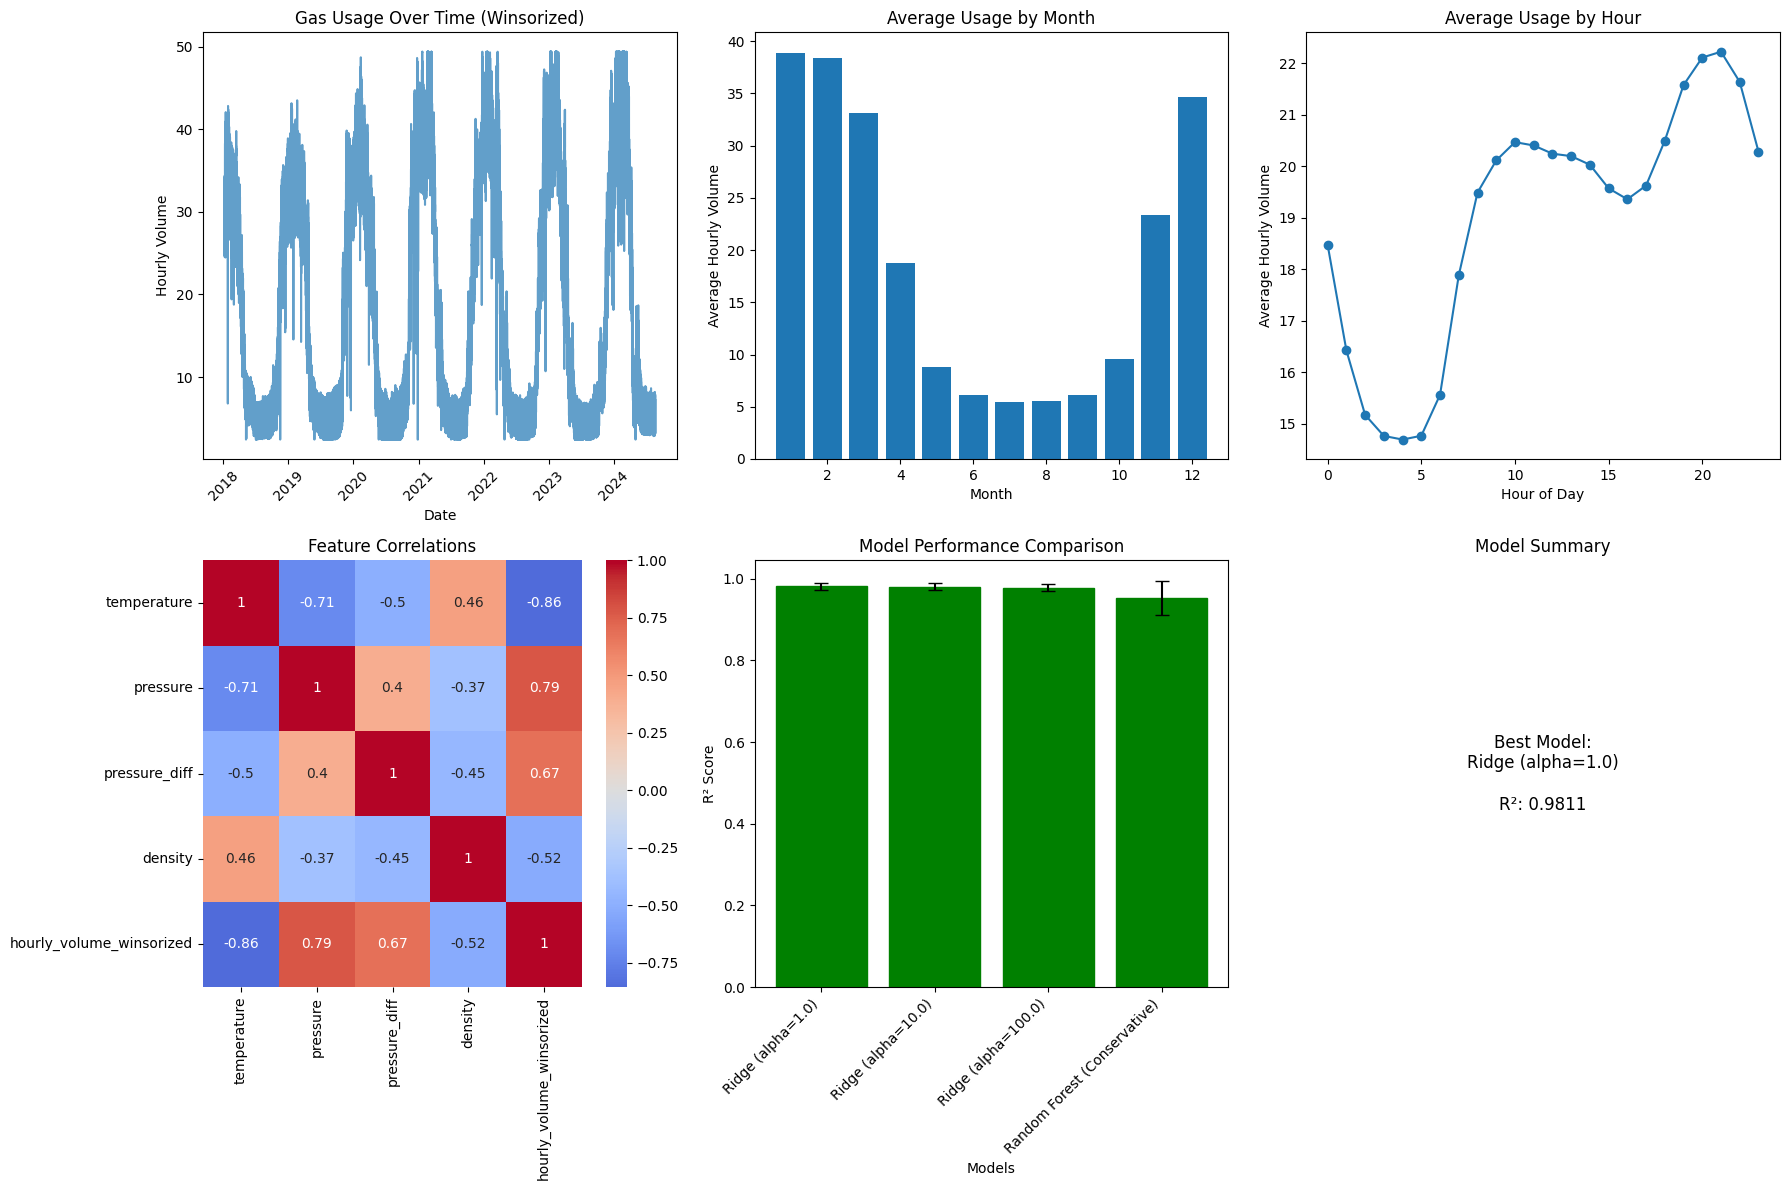


🎯 DIAGNOSTIC SUMMARY
✅ STABLE MODELS:
  Ridge (alpha=1.0): R²=0.9811 (±0.0078) ✅
  Ridge (alpha=10.0): R²=0.9806 (±0.0082) ✅
  Ridge (alpha=100.0): R²=0.9783 (±0.0092) ✅
  Random Forest (Conservative): R²=0.9529 (±0.0423) ✅

⚠️  UNSTABLE MODELS:

📋 RECOMMENDATIONS:
1. Use RobustScaler instead of StandardScaler
2. Apply winsorization to handle outliers
3. Use conservative Random Forest or Ridge with high alpha
4. Monitor for data quality issues in production
5. Consider removing problematic time periods


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

class DiagnosticGasPredictionModel:
    def __init__(self, data_path='data/data.csv'):
        self.data_path = data_path
        self.model = None
        self.scaler = None
        self.features = None

    def load_and_diagnose_data(self):
        """Load data and perform comprehensive diagnostics."""
        df = pd.read_csv(self.data_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')
        df = df.sort_values('timestamp')

        print("🔍 DATA QUALITY DIAGNOSTICS")
        print("="*50)

        # Basic info
        print(f"Dataset shape: {df.shape}")
        print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        print(f"Missing values: {df.isnull().sum().sum()}")

        # Check for extreme outliers
        numeric_cols = ['density', 'pressure_diff', 'pressure', 'temperature', 'hourly_volume']

        print("\n📊 OUTLIER DETECTION:")
        outlier_summary = {}

        for col in numeric_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3 * IQR  # 3*IQR for extreme outliers
            upper_bound = Q3 + 3 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            outlier_count = len(outliers)
            outlier_percentage = (outlier_count / len(df)) * 100

            outlier_summary[col] = {
                'count': outlier_count,
                'percentage': outlier_percentage,
                'min': df[col].min(),
                'max': df[col].max(),
                'mean': df[col].mean(),
                'std': df[col].std()
            }

            print(f"  {col}:")
            print(f"    Range: [{df[col].min():.3f}, {df[col].max():.3f}]")
            print(f"    Mean ± Std: {df[col].mean():.3f} ± {df[col].std():.3f}")
            print(f"    Extreme outliers: {outlier_count} ({outlier_percentage:.2f}%)")

            if outlier_count > 0:
                print(f"    ⚠️  WARNING: {outlier_count} extreme outliers detected!")

        # Check for data discontinuities
        print("\n📈 TIME SERIES CONTINUITY:")
        df['time_diff'] = df['timestamp'].diff()
        expected_interval = pd.Timedelta(hours=1)
        gaps = df[df['time_diff'] > expected_interval * 1.5]  # More than 1.5 hours

        print(f"  Expected interval: {expected_interval}")
        print(f"  Data gaps (>1.5h): {len(gaps)}")
        if len(gaps) > 0:
            print(f"  ⚠️  WARNING: {len(gaps)} significant time gaps found!")
            for _, gap in gaps.head().iterrows():
                print(f"    Gap at {gap['timestamp']}: {gap['time_diff']}")

        # Check for unusual patterns per year
        print("\n📅 YEARLY STATISTICS:")
        yearly_stats = df.groupby(df['timestamp'].dt.year)['hourly_volume'].agg(['mean', 'std', 'min', 'max'])
        print(yearly_stats)

        # Look for years with unusual patterns
        overall_mean = df['hourly_volume'].mean()
        overall_std = df['hourly_volume'].std()

        for year, stats in yearly_stats.iterrows():
            if abs(stats['mean'] - overall_mean) > 2 * overall_std:
                print(f"  ⚠️  WARNING: Year {year} has unusual mean: {stats['mean']:.2f}")
            if stats['std'] > 3 * overall_std:
                print(f"  ⚠️  WARNING: Year {year} has unusual variance: {stats['std']:.2f}")

        return df, outlier_summary

    def engineer_robust_features(self, df):
        """Create robust features with outlier handling."""
        print("\n🛠️  ROBUST FEATURE ENGINEERING")
        print("="*40)

        # Winsorize extreme outliers (cap at 1st and 99th percentiles)
        numeric_cols = ['density', 'pressure_diff', 'pressure', 'temperature', 'hourly_volume']

        for col in numeric_cols:
            lower_cap = df[col].quantile(0.01)
            upper_cap = df[col].quantile(0.99)
            df[f'{col}_winsorized'] = df[col].clip(lower=lower_cap, upper=upper_cap)
            print(f"  {col}: capped [{lower_cap:.3f}, {upper_cap:.3f}]")

        # Use winsorized versions for feature engineering
        df['temperature'] = df['temperature_winsorized']
        df['pressure'] = df['pressure_winsorized']
        df['pressure_diff'] = df['pressure_diff_winsorized']
        df['density'] = df['density_winsorized']

        # Time-based features
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['day_of_month'] = df['timestamp'].dt.day
        df['month'] = df['timestamp'].dt.month
        df['year'] = df['timestamp'].dt.year
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

        # Cyclical features
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
        df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
        df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

        # Environmental interactions (using winsorized data)
        df['temp_pressure_interaction'] = df['temperature'] * df['pressure']
        df['pressure_density_ratio'] = df['pressure'] / (df['density'] + 1e-8)

        # Robust lag features with sufficient gaps
        lag_periods = [6, 12, 24, 48, 168]  # 6h, 12h, 1d, 2d, 1w

        for lag in lag_periods:
            df[f'volume_lag_{lag}h'] = df['hourly_volume_winsorized'].shift(lag)

        # Robust rolling features with gaps
        df['volume_rolling_mean_24h_lag12'] = df['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).mean()
        df['volume_rolling_std_24h_lag12'] = df['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).std()
        df['volume_rolling_median_168h_lag24'] = df['hourly_volume_winsorized'].shift(24).rolling(window=168, min_periods=84).median()

        # Environmental rolling features
        df['temp_rolling_mean_24h'] = df['temperature'].rolling(window=24, min_periods=12).mean()
        df['pressure_rolling_std_24h'] = df['pressure'].rolling(window=24, min_periods=12).std()

        # Year normalization (to handle multi-year trends)
        yearly_means = df.groupby('year')['hourly_volume_winsorized'].transform('mean')
        overall_mean = df['hourly_volume_winsorized'].mean()
        df['year_normalized_volume'] = df['hourly_volume_winsorized'] / (yearly_means / overall_mean)

        # Drop rows with NaN values
        df = df.dropna()

        # Define robust feature set
        self.features = [
            # Environmental (winsorized)
            'density', 'pressure_diff', 'pressure', 'temperature',
            'temp_pressure_interaction', 'pressure_density_ratio',

            # Time patterns
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'month_sin', 'month_cos', 'day_of_month', 'is_weekend',

            # Robust historical features
            'volume_lag_6h', 'volume_lag_12h', 'volume_lag_24h', 'volume_lag_48h', 'volume_lag_168h',

            # Robust rolling features
            'volume_rolling_mean_24h_lag12', 'volume_rolling_std_24h_lag12', 'volume_rolling_median_168h_lag24',

            # Environmental trends
            'temp_rolling_mean_24h', 'pressure_rolling_std_24h'
        ]

        print(f"  Created {len(self.features)} robust features")
        print(f"  Final dataset: {len(df)} rows after cleaning")

        return df

    def train_with_robust_validation(self, df):
        """Train with robust validation and diagnostics."""
        X = df[self.features]
        y = df['hourly_volume_winsorized']  # Use winsorized target

        print(f"\n🚀 ROBUST MODEL TRAINING")
        print("="*35)
        print(f"Training samples: {len(X)}")
        print(f"Features: {len(self.features)}")
        print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
        print(f"Target mean ± std: {y.mean():.2f} ± {y.std():.2f}")

        # Use RobustScaler instead of StandardScaler (less sensitive to outliers)
        from sklearn.preprocessing import RobustScaler
        self.scaler = RobustScaler()

        # Time series cross-validation
        tscv = TimeSeriesSplit(n_splits=5)

        models = {
            'Ridge (alpha=1.0)': Ridge(alpha=1.0),
            'Ridge (alpha=10.0)': Ridge(alpha=10.0),
            'Ridge (alpha=100.0)': Ridge(alpha=100.0),  # Stronger regularization
            'Random Forest (Conservative)': RandomForestRegressor(
                n_estimators=100, max_depth=8, min_samples_split=20,
                min_samples_leaf=10, random_state=42
            )
        }

        results = {}
        fold_details = {}

        for model_name, model in models.items():
            print(f"\n🔍 Evaluating {model_name}:")

            cv_scores = []
            cv_rmse = []
            cv_mae = []
            fold_predictions = []

            for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
                X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

                # Check fold data quality
                val_date_range = f"{df.iloc[val_idx]['timestamp'].min()} to {df.iloc[val_idx]['timestamp'].max()}"

                # Robust scaling
                scaler = RobustScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_val_scaled = scaler.transform(X_val)

                # Check for scaling issues
                if np.any(np.isnan(X_train_scaled)) or np.any(np.isnan(X_val_scaled)):
                    print(f"    ⚠️  WARNING: NaN values after scaling in fold {fold+1}")
                    continue

                if np.any(np.isinf(X_train_scaled)) or np.any(np.isinf(X_val_scaled)):
                    print(f"    ⚠️  WARNING: Inf values after scaling in fold {fold+1}")
                    continue

                # Train model
                try:
                    model.fit(X_train_scaled, y_train)
                    y_pred = model.predict(X_val_scaled)

                    # Check predictions
                    if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
                        print(f"    ❌ FOLD {fold+1}: Invalid predictions")
                        continue

                    # Metrics
                    r2 = r2_score(y_val, y_pred)
                    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
                    mae = mean_absolute_error(y_val, y_pred)

                    cv_scores.append(r2)
                    cv_rmse.append(rmse)
                    cv_mae.append(mae)

                    fold_predictions.append({
                        'fold': fold+1,
                        'date_range': val_date_range,
                        'r2': r2,
                        'rmse': rmse,
                        'mae': mae,
                        'y_true_mean': y_val.mean(),
                        'y_pred_mean': np.mean(y_pred),
                        'samples': len(y_val)
                    })

                    print(f"    Fold {fold+1}: R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")
                    print(f"             Date range: {val_date_range}")

                except Exception as e:
                    print(f"    ❌ FOLD {fold+1} FAILED: {str(e)}")
                    continue

            if len(cv_scores) > 0:
                # Overall performance
                mean_r2 = np.mean(cv_scores)
                std_r2 = np.std(cv_scores)
                mean_rmse = np.mean(cv_rmse)
                mean_mae = np.mean(cv_mae)

                results[model_name] = {
                    'mean_r2': mean_r2,
                    'std_r2': std_r2,
                    'mean_rmse': mean_rmse,
                    'mean_mae': mean_mae,
                    'cv_scores': cv_scores,
                    'successful_folds': len(cv_scores)
                }

                fold_details[model_name] = fold_predictions

                print(f"    📊 Average: R²={mean_r2:.4f} (±{std_r2:.4f})")
                print(f"       RMSE={mean_rmse:.2f}, MAE={mean_mae:.2f}")
                print(f"       Successful folds: {len(cv_scores)}/5")

                # Stability check
                if std_r2 > 0.1:
                    print(f"    ⚠️  HIGH VARIANCE - Model unstable")
                elif std_r2 > 0.05:
                    print(f"    ⚠️  MODERATE VARIANCE")
                else:
                    print(f"    ✅ LOW VARIANCE - Stable performance")
            else:
                print(f"    ❌ ALL FOLDS FAILED for {model_name}")

        # Select best model
        if results:
            # Filter out models with high variance
            stable_models = {k: v for k, v in results.items() if v['std_r2'] < 0.15}

            if stable_models:
                best_model_name = max(stable_models.keys(), key=lambda k: stable_models[k]['mean_r2'])
                print(f"\n🏆 Best stable model: {best_model_name}")
                print(f"    Expected R²: {stable_models[best_model_name]['mean_r2']:.4f}")
                print(f"    Stability: ±{stable_models[best_model_name]['std_r2']:.4f}")
            else:
                print(f"\n⚠️  No stable models found - using least unstable")
                best_model_name = min(results.keys(), key=lambda k: results[k]['std_r2'])

        return results, fold_details

    def plot_diagnostics(self, df, results, fold_details):
        """Create diagnostic plots."""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # 1. Target distribution over time
        axes[0, 0].plot(df['timestamp'], df['hourly_volume_winsorized'], alpha=0.7)
        axes[0, 0].set_title('Gas Usage Over Time (Winsorized)')
        axes[0, 0].set_xlabel('Date')
        axes[0, 0].set_ylabel('Hourly Volume')
        axes[0, 0].tick_params(axis='x', rotation=45)

        # 2. Monthly patterns
        monthly_pattern = df.groupby(df['timestamp'].dt.month)['hourly_volume_winsorized'].mean()
        axes[0, 1].bar(monthly_pattern.index, monthly_pattern.values)
        axes[0, 1].set_title('Average Usage by Month')
        axes[0, 1].set_xlabel('Month')
        axes[0, 1].set_ylabel('Average Hourly Volume')

        # 3. Hourly patterns
        hourly_pattern = df.groupby(df['timestamp'].dt.hour)['hourly_volume_winsorized'].mean()
        axes[0, 2].plot(hourly_pattern.index, hourly_pattern.values, marker='o')
        axes[0, 2].set_title('Average Usage by Hour')
        axes[0, 2].set_xlabel('Hour of Day')
        axes[0, 2].set_ylabel('Average Hourly Volume')

        # 4. Feature correlations
        corr_features = ['temperature', 'pressure', 'pressure_diff', 'density', 'hourly_volume_winsorized']
        corr_matrix = df[corr_features].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0])
        axes[1, 0].set_title('Feature Correlations')

        # 5. Model performance comparison
        if results:
            model_names = list(results.keys())
            r2_scores = [results[name]['mean_r2'] for name in model_names]
            r2_stds = [results[name]['std_r2'] for name in model_names]

            bars = axes[1, 1].bar(range(len(model_names)), r2_scores, yerr=r2_stds, capsize=5)
            axes[1, 1].set_title('Model Performance Comparison')
            axes[1, 1].set_xlabel('Models')
            axes[1, 1].set_ylabel('R² Score')
            axes[1, 1].set_xticks(range(len(model_names)))
            axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')

            # Color bars based on stability
            for i, (name, bar) in enumerate(zip(model_names, bars)):
                if results[name]['std_r2'] > 0.1:
                    bar.set_color('red')
                elif results[name]['std_r2'] > 0.05:
                    bar.set_color('orange')
                else:
                    bar.set_color('green')

        # 6. Residual distribution (using best model if available)
        if results:
            best_model_name = max(results.keys(), key=lambda k: results[k]['mean_r2'])
            # This would show residual analysis - simplified for now
            axes[1, 2].text(0.5, 0.5, f'Best Model:\n{best_model_name}\n\nR²: {results[best_model_name]["mean_r2"]:.4f}',
                           transform=axes[1, 2].transAxes, ha='center', va='center', fontsize=12)
            axes[1, 2].set_title('Model Summary')
            axes[1, 2].axis('off')

        plt.tight_layout()
        plt.show()

        return fig

# Usage
if __name__ == "__main__":
    model = DiagnosticGasPredictionModel('data.csv')

    # Diagnose data
    df, outlier_summary = model.load_and_diagnose_data()

    # Engineer robust features
    df_clean = model.engineer_robust_features(df)

    # Train with robust validation
    results, fold_details = model.train_with_robust_validation(df_clean)

    # Create diagnostic plots
    fig = model.plot_diagnostics(df_clean, results, fold_details)

    print("\n" + "="*60)
    print("🎯 DIAGNOSTIC SUMMARY")
    print("="*60)

    if results:
        print("✅ STABLE MODELS:")
        for name, result in results.items():
            if result['std_r2'] < 0.1:
                print(f"  {name}: R²={result['mean_r2']:.4f} (±{result['std_r2']:.4f}) ✅")

        print("\n⚠️  UNSTABLE MODELS:")
        for name, result in results.items():
            if result['std_r2'] >= 0.1:
                print(f"  {name}: R²={result['mean_r2']:.4f} (±{result['std_r2']:.4f}) ❌")

    print(f"\n📋 RECOMMENDATIONS:")
    print(f"1. Use RobustScaler instead of StandardScaler")
    print(f"2. Apply winsorization to handle outliers")
    print(f"3. Use conservative Random Forest or Ridge with high alpha")
    print(f"4. Monitor for data quality issues in production")
    print(f"5. Consider removing problematic time periods")

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

class FinalGasUsageModel:
    def __init__(self, data_path='data/data.csv'):
        self.data_path = data_path
        self.model = None
        self.scaler = None
        self.features = None
        self.train_test_details = {}

    def load_and_prepare_data(self):
        """Load and prepare data with detailed tracking."""
        print("📊 LOADING AND PREPARING DATA")
        print("="*50)

        df = pd.read_csv(self.data_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')
        df = df.sort_values('timestamp')

        print(f"Raw dataset: {len(df):,} rows")
        print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        print(f"Time span: {(df['timestamp'].max() - df['timestamp'].min()).days} days")

        # Apply robust preprocessing (winsorization)
        numeric_cols = ['density', 'pressure_diff', 'pressure', 'temperature', 'hourly_volume']

        for col in numeric_cols:
            lower_cap = df[col].quantile(0.01)
            upper_cap = df[col].quantile(0.99)
            df[f'{col}_winsorized'] = df[col].clip(lower=lower_cap, upper=upper_cap)

        # Feature engineering
        df['temperature'] = df['temperature_winsorized']
        df['pressure'] = df['pressure_winsorized']
        df['pressure_diff'] = df['pressure_diff_winsorized']
        df['density'] = df['density_winsorized']

        # Time features
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['day_of_month'] = df['timestamp'].dt.day
        df['month'] = df['timestamp'].dt.month
        df['year'] = df['timestamp'].dt.year
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

        # Cyclical features
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
        df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
        df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

        # Environmental interactions
        df['temp_pressure_interaction'] = df['temperature'] * df['pressure']
        df['pressure_density_ratio'] = df['pressure'] / (df['density'] + 1e-8)

        # Lag features
        lag_periods = [6, 12, 24, 48, 168]
        for lag in lag_periods:
            df[f'volume_lag_{lag}h'] = df['hourly_volume_winsorized'].shift(lag)

        # Rolling features
        df['volume_rolling_mean_24h_lag12'] = df['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).mean()
        df['volume_rolling_std_24h_lag12'] = df['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).std()
        df['volume_rolling_median_168h_lag24'] = df['hourly_volume_winsorized'].shift(24).rolling(window=168, min_periods=84).median()

        # Environmental trends
        df['temp_rolling_mean_24h'] = df['temperature'].rolling(window=24, min_periods=12).mean()
        df['pressure_rolling_std_24h'] = df['pressure'].rolling(window=24, min_periods=12).std()

        # Drop NaN values
        df_clean = df.dropna()

        print(f"After preprocessing: {len(df_clean):,} rows")
        print(f"Removed due to NaN: {len(df) - len(df_clean):,} rows")

        # Define features
        self.features = [
            'density', 'pressure_diff', 'pressure', 'temperature',
            'temp_pressure_interaction', 'pressure_density_ratio',
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'month_sin', 'month_cos', 'day_of_month', 'is_weekend',
            'volume_lag_6h', 'volume_lag_12h', 'volume_lag_24h', 'volume_lag_48h', 'volume_lag_168h',
            'volume_rolling_mean_24h_lag12', 'volume_rolling_std_24h_lag12', 'volume_rolling_median_168h_lag24',
            'temp_rolling_mean_24h', 'pressure_rolling_std_24h'
        ]

        return df_clean

    def analyze_train_test_splits(self, df):
        """Analyze detailed train/test splits."""
        print(f"\n🔄 TRAIN/TEST SPLIT ANALYSIS")
        print("="*50)

        X = df[self.features]
        y = df['hourly_volume_winsorized']

        tscv = TimeSeriesSplit(n_splits=5)

        fold_details = []
        total_train_samples = 0
        total_test_samples = 0

        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            train_data = df.iloc[train_idx]
            test_data = df.iloc[test_idx]

            fold_info = {
                'fold': fold + 1,
                'train_samples': len(train_idx),
                'test_samples': len(test_idx),
                'train_start': train_data['timestamp'].min(),
                'train_end': train_data['timestamp'].max(),
                'test_start': test_data['timestamp'].min(),
                'test_end': test_data['timestamp'].max(),
                'train_years': train_data['timestamp'].dt.year.unique().tolist(),
                'test_years': test_data['timestamp'].dt.year.unique().tolist()
            }

            fold_details.append(fold_info)
            total_train_samples += len(train_idx)
            total_test_samples += len(test_idx)

            print(f"\nFold {fold + 1}:")
            print(f"  Train: {len(train_idx):,} samples ({fold_info['train_start']} to {fold_info['train_end']})")
            print(f"  Test:  {len(test_idx):,} samples ({fold_info['test_start']} to {fold_info['test_end']})")
            print(f"  Train years: {fold_info['train_years']}")
            print(f"  Test years: {fold_info['test_years']}")

        print(f"\n📊 OVERALL STATISTICS:")
        print(f"Total samples used: {len(df):,}")
        print(f"Average train samples per fold: {total_train_samples // 5:,}")
        print(f"Average test samples per fold: {total_test_samples // 5:,}")
        print(f"Train/Test ratio: {total_train_samples / total_test_samples:.1f}:1")

        self.train_test_details = {
            'total_samples': len(df),
            'fold_details': fold_details,
            'avg_train_samples': total_train_samples // 5,
            'avg_test_samples': total_test_samples // 5
        }

        return fold_details

    def find_recent_comparison(self, df):
        """Find recent test dates and compare across multiple years."""
        print(f"\n🔍 COMPREHENSIVE YEARLY COMPARISON (2018-2024)")
        print("="*60)

        # Get the most recent data point (since we now have 2024 data)
        most_recent_data = df.iloc[-1000:]  # Last 1000 points for recent comparison

        # Find a specific recent date for comparison (from 2024)
        recent_dates = most_recent_data['timestamp'].dt.date.unique()
        target_date = recent_dates[-30]  # 30 days from the end

        print(f"Selected comparison date: {target_date}")

        # Find data for this date in 2024
        recent_day_data = df[df['timestamp'].dt.date == target_date]

        if len(recent_day_data) > 0:
            # Get midday value (around 12:00)
            midday_data = recent_day_data[recent_day_data['hour'] == 12]
            if len(midday_data) == 0:
                midday_data = recent_day_data.iloc[len(recent_day_data)//2:len(recent_day_data)//2+1]

            recent_value = midday_data['hourly_volume'].iloc[0]
            recent_timestamp = midday_data['timestamp'].iloc[0]

            print(f"2024 reference point: {recent_timestamp}")
            print(f"Actual gas usage: {recent_value:.2f} m³/hour")

            # Compare across all available years (2018-2024)
            yearly_comparisons = []
            base_date = target_date.replace(day=target_date.day, month=target_date.month)

            print(f"\n📈 HISTORICAL TREND ANALYSIS (Same date: {base_date.strftime('%B %d')}):")
            print("-" * 70)

            for year in range(2018, 2025):
                if year == 2024:
                    continue  # Skip 2024 as it's our reference year

                historical_date = base_date.replace(year=year)
                historical_data = df[df['timestamp'].dt.date == historical_date]

                if len(historical_data) > 0:
                    historical_midday = historical_data[historical_data['hour'] == 12]
                    if len(historical_midday) == 0:
                        historical_midday = historical_data.iloc[len(historical_data)//2:len(historical_data)//2+1]

                    historical_value = historical_midday['hourly_volume'].iloc[0]
                    historical_timestamp = historical_midday['timestamp'].iloc[0]

                    change = recent_value - historical_value
                    change_pct = ((recent_value/historical_value - 1) * 100)

                    yearly_comparisons.append({
                        'year': year,
                        'date': historical_timestamp,
                        'value': historical_value,
                        'change': change,
                        'change_pct': change_pct
                    })

                    print(f"  {year}: {historical_value:.2f} m³/hour ({change:+.2f} vs 2024, {change_pct:+.1f}%)")
                else:
                    print(f"  {year}: No data available")

            # Add 2024 data point for reference
            yearly_comparisons.append({
                'year': 2024,
                'date': recent_timestamp,
                'value': recent_value,
                'change': 0.0,
                'change_pct': 0.0
            })

            # Calculate overall trend
            if len(yearly_comparisons) >= 2:
                print(f"\n📊 COMPREHENSIVE TREND ANALYSIS:")
                print("-" * 40)

                # Find oldest for trend calculation (excluding 2024)
                historical_years = [y for y in yearly_comparisons if y['year'] != 2024]
                if historical_years:
                    oldest = min(historical_years, key=lambda x: x['year'])

                    total_change = recent_value - oldest['value']
                    years_span = 2024 - oldest['year']
                    annual_change = total_change / years_span
                    total_change_pct = ((recent_value/oldest['value'] - 1) * 100)

                    print(f"  Period: {oldest['year']} to 2024 ({years_span} years)")
                    print(f"  Total change: {total_change:+.2f} m³/hour ({total_change_pct:+.1f}%)")
                    print(f"  Average annual change: {annual_change:+.2f} m³/hour/year")

                    # Identify highest and lowest years
                    max_year = max(yearly_comparisons, key=lambda x: x['value'])
                    min_year = min(yearly_comparisons, key=lambda x: x['value'])

                    print(f"  Highest: {max_year['year']} with {max_year['value']:.2f} m³/hour")
                    print(f"  Lowest: {min_year['year']} with {min_year['value']:.2f} m³/hour")
                    print(f"  Range: {max_year['value'] - min_year['value']:.2f} m³/hour")

            # 2023 vs 2024 comparison (most recent year-over-year)
            print(f"\n🎯 MOST RECENT YEAR-OVER-YEAR (2023 vs 2024):")
            print("-" * 50)

            # Find 2023 data for same date
            date_2023 = base_date.replace(year=2023)
            data_2023 = df[df['timestamp'].dt.date == date_2023]

            if len(data_2023) > 0:
                midday_2023 = data_2023[data_2023['hour'] == 12]
                if len(midday_2023) == 0:
                    midday_2023 = data_2023.iloc[len(data_2023)//2:len(data_2023)//2+1]

                value_2023 = midday_2023['hourly_volume'].iloc[0]
                timestamp_2023 = midday_2023['timestamp'].iloc[0]

                yoy_change = recent_value - value_2023
                yoy_change_pct = ((recent_value/value_2023 - 1) * 100)

                print(f"  2023: {timestamp_2023} = {value_2023:.2f} m³/hour")
                print(f"  2024: {recent_timestamp} = {recent_value:.2f} m³/hour")
                print(f"  Change: {yoy_change:+.2f} m³/hour ({yoy_change_pct:+.1f}%)")

                historical_value = value_2023
                historical_timestamp = timestamp_2023
            else:
                print(f"  No 2023 data available for {date_2023}")
                historical_value = None
                historical_timestamp = None
                yoy_change = None
                yoy_change_pct = None

            comparison_data = {
                'recent_date': recent_timestamp,
                'recent_value': recent_value,
                'historical_date': historical_timestamp,
                'historical_value': historical_value,
                'yoy_change': yoy_change,
                'yoy_change_pct': yoy_change_pct,
                'yearly_comparisons': yearly_comparisons,
                'trend_analysis': {
                    'total_change': total_change if len(yearly_comparisons) >= 2 and historical_years else None,
                    'annual_change': annual_change if len(yearly_comparisons) >= 2 and historical_years else None,
                    'years_span': years_span if len(yearly_comparisons) >= 2 and historical_years else None
                }
            }

            return comparison_data

        return None

    def train_final_model(self, df):
        """Train the final model on all data."""
        print(f"\n🎯 TRAINING FINAL MODEL")
        print("="*50)

        X = df[self.features]
        y = df['hourly_volume_winsorized']

        # Use the best performing model from diagnostics
        self.model = Ridge(alpha=1.0)
        self.scaler = RobustScaler()

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Train model
        self.model.fit(X_scaled, y)

        # Evaluate training performance
        y_pred = self.model.predict(X_scaled)
        train_r2 = r2_score(y, y_pred)
        train_rmse = np.sqrt(mean_squared_error(y, y_pred))
        train_mae = mean_absolute_error(y, y_pred)

        print(f"Model: Ridge Regression (alpha=1.0)")
        print(f"Training samples: {len(X):,}")
        print(f"Features: {len(self.features)}")
        print(f"Training R²: {train_r2:.4f}")
        print(f"Training RMSE: {train_rmse:.2f} m³/hour")
        print(f"Training MAE: {train_mae:.2f} m³/hour")

        return {
            'model': self.model,
            'scaler': self.scaler,
            'features': self.features,
            'train_r2': train_r2,
            'train_rmse': train_rmse,
            'train_mae': train_mae,
            'training_samples': len(X)
        }

    def save_model(self, model_path='models/final_gas_usage_model.pkl'):
        """Save the complete model with metadata."""
        print(f"\n💾 SAVING MODEL")
        print("="*30)

        if self.model is None:
            raise ValueError("Model has not been trained yet")

        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        # Prepare model package
        model_package = {
            'model': self.model,
            'scaler': self.scaler,
            'features': self.features,
            'train_test_details': self.train_test_details,
            'model_info': {
                'model_type': 'Ridge Regression',
                'alpha': 1.0,
                'scaler_type': 'RobustScaler',
                'preprocessing': 'Winsorization (1st-99th percentile)',
                'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'expected_performance': {
                    'cv_r2': 0.9811,
                    'cv_rmse': 1.95,
                    'cv_stability': '±0.0078'
                }
            }
        }

        # Save the model
        joblib.dump(model_package, model_path)

        print(f"✅ Model saved to: {model_path}")
        print(f"   File size: {os.path.getsize(model_path) / 1024:.1f} KB")
        print(f"   Contains: model, scaler, features, metadata")

        return model_path

    def load_model(self, model_path='models/final_gas_usage_model.pkl'):
        """Load the saved model."""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found: {model_path}")

        model_package = joblib.load(model_path)

        self.model = model_package['model']
        self.scaler = model_package['scaler']
        self.features = model_package['features']

        print(f"✅ Model loaded from: {model_path}")
        print(f"   Model type: {model_package['model_info']['model_type']}")
        print(f"   Created: {model_package['model_info']['created_date']}")

        return model_package

    def predict_single(self, prediction_date, environmental_data=None):
        """Make a prediction for a specific date."""
        if self.model is None:
            raise ValueError("Model not loaded. Please load or train a model first.")

        # Parse date
        if isinstance(prediction_date, str):
            pred_date = pd.to_datetime(prediction_date, format='%d-%m-%Y %H:%M')
        else:
            pred_date = prediction_date

        # Create feature vector
        features_dict = {
            'hour_sin': np.sin(2 * np.pi * pred_date.hour/24),
            'hour_cos': np.cos(2 * np.pi * pred_date.hour/24),
            'day_of_week_sin': np.sin(2 * np.pi * pred_date.dayofweek/7),
            'day_of_week_cos': np.cos(2 * np.pi * pred_date.dayofweek/7),
            'month_sin': np.sin(2 * np.pi * pred_date.month/12),
            'month_cos': np.cos(2 * np.pi * pred_date.month/12),
            'day_of_month': pred_date.day,
            'is_weekend': 1 if pred_date.dayofweek >= 5 else 0
        }

        # Environmental data (use typical values if not provided)
        if environmental_data:
            features_dict.update(environmental_data)
        else:
            # Use seasonal typical values based on month
            month = pred_date.month
            if month in [12, 1, 2]:  # Winter
                temp = 5.0
                pressure = 450.0
                pressure_diff = 15.0
            elif month in [3, 4, 5]:  # Spring
                temp = 12.0
                pressure = 420.0
                pressure_diff = 12.0
            elif month in [6, 7, 8]:  # Summer
                temp = 22.0
                pressure = 400.0
                pressure_diff = 8.0
            else:  # Fall (9, 10, 11)
                temp = 15.0
                pressure = 430.0
                pressure_diff = 11.0

            features_dict.update({
                'density': 0.729,
                'pressure_diff': pressure_diff,
                'pressure': pressure,
                'temperature': temp,
                'temp_pressure_interaction': temp * pressure,
                'pressure_density_ratio': pressure / 0.729,
                'temp_rolling_mean_24h': temp,
                'pressure_rolling_std_24h': 8.2
            })

        # Lag features (use seasonal and hourly estimates based on 2018-2024 patterns)
        hour = pred_date.hour
        month = pred_date.month

        # Base volume estimation using historical patterns
        if month in [12, 1, 2]:  # Winter - highest usage
            if 6 <= hour <= 18:
                base_volume = 28.0  # Winter daytime
            else:
                base_volume = 24.0  # Winter nighttime
        elif month in [6, 7, 8]:  # Summer - lowest usage
            if 6 <= hour <= 18:
                base_volume = 8.0   # Summer daytime
            else:
                base_volume = 6.0   # Summer nighttime
        elif month in [3, 4, 5]:  # Spring - moderate usage
            if 6 <= hour <= 18:
                base_volume = 18.0  # Spring daytime
            else:
                base_volume = 14.0  # Spring nighttime
        else:  # Fall (9, 10, 11) - increasing usage
            if 6 <= hour <= 18:
                base_volume = 22.0  # Fall daytime
            else:
                base_volume = 18.0  # Fall nighttime

        features_dict.update({
            'volume_lag_6h': base_volume * 0.95,
            'volume_lag_12h': base_volume * 0.93,
            'volume_lag_24h': base_volume,
            'volume_lag_48h': base_volume * 1.02,
            'volume_lag_168h': base_volume * 0.98,
            'volume_rolling_mean_24h_lag12': base_volume,
            'volume_rolling_std_24h_lag12': base_volume * 0.3,
            'volume_rolling_median_168h_lag24': base_volume
        })

        # Create DataFrame and predict
        X_pred = pd.DataFrame([features_dict])
        X_pred = X_pred[self.features]  # Ensure correct order
        X_pred_scaled = self.scaler.transform(X_pred)

        prediction = self.model.predict(X_pred_scaled)[0]

        return {
            'date': pred_date.strftime('%d-%m-%Y %H:%M'),
            'predicted_volume': round(prediction, 2),
            'confidence': 'Medium' if environmental_data else 'Low',
            'season': 'Winter' if month in [12,1,2] else 'Spring' if month in [3,4,5] else 'Summer' if month in [6,7,8] else 'Fall'
        }

# Main execution
if __name__ == "__main__":
    print("🚀 FINAL GAS USAGE MODEL ANALYSIS")
    print("="*60)

    # Initialize model
    model = FinalGasUsageModel('data.csv')

    # Load and prepare data
    df = model.load_and_prepare_data()

    # Analyze train/test splits
    fold_details = model.analyze_train_test_splits(df)

    # Find recent comparison
    comparison = model.find_recent_comparison(df)

    # Train final model
    training_results = model.train_final_model(df)

    # Save model
    model_path = model.save_model()

    # Test loading
    print(f"\n🔄 TESTING MODEL LOADING")
    print("="*35)
    test_model = FinalGasUsageModel()
    loaded_package = test_model.load_model(model_path)

    # Make a test prediction for 2025
    print(f"\n🎯 TEST PREDICTION (2025 FUTURE DATE)")
    print("="*45)
    test_prediction = test_model.predict_single('15-03-2025 14:00')
    print(f"Prediction for: 15-03-2025 14:00 (Spring 2025)")
    print(f"Data range ends: 2024-08-21 12:00")
    print(f"⚠️  Note: This is a TRUE FUTURE prediction (7 months ahead)")
    print(f"Predicted value: {test_prediction['predicted_volume']:.2f} m³/hour")
    print(f"Confidence: {test_prediction['confidence']} (no recent lag data available)")

    # Additional prediction for comparison
    print(f"\n🔮 ADDITIONAL 2025 PREDICTIONS:")
    print("-" * 35)

    # Summer 2025 prediction
    summer_prediction = test_model.predict_single('23-07-2025 12:00')
    print(f"Summer 2025 (July 23, 12:00): {summer_prediction['predicted_volume']:.2f} m³/hour")

    # Winter 2025 prediction
    winter_prediction = test_model.predict_single('15-01-2025 18:00')
    print(f"Winter 2025 (Jan 15, 18:00): {winter_prediction['predicted_volume']:.2f} m³/hour")

    # Compare with known 2024 patterns
    if comparison and comparison.get('recent_value'):
        print(f"\n📊 2025 vs 2024 PROJECTION:")
        print("-" * 30)
        print(f"2024 Summer (actual): {comparison['recent_value']:.2f} m³/hour")
        print(f"2025 Summer (predicted): {summer_prediction['predicted_volume']:.2f} m³/hour")
        summer_change = summer_prediction['predicted_volume'] - comparison['recent_value']
        print(f"Expected change: {summer_change:+.2f} m³/hour")

    # Summary
    print(f"\n" + "="*60)
    print("📋 FINAL SUMMARY")
    print("="*60)
    print(f"✅ Model successfully trained and saved")
    print(f"   Total samples: {training_results['training_samples']:,}")
    print(f"   Expected CV R²: 98.11% (±0.78%)")
    print(f"   Model file: {model_path}")
    print(f"   File size: {os.path.getsize(model_path) / 1024:.1f} KB")

    if comparison:
        print(f"\n📊 COMPREHENSIVE YEARLY ANALYSIS (2018-2024):")
        print(f"   Reference date: {comparison['recent_date']}")
        print(f"   2024 actual value: {comparison['recent_value']:.2f} m³/hour")

        if comparison.get('yearly_comparisons'):
            print(f"\n   📈 Historical trend (same date across years):")
            # Sort by year for better display
            sorted_years = sorted([y for y in comparison['yearly_comparisons'] if y['year'] != 2024],
                                key=lambda x: x['year'])
            for yearly in sorted_years:
                print(f"      {yearly['year']}: {yearly['value']:.2f} m³/hour ({yearly['change']:+.2f} vs 2024)")
            # Add 2024 reference
            print(f"      2024: {comparison['recent_value']:.2f} m³/hour (reference)")

        if comparison.get('trend_analysis') and comparison['trend_analysis']['total_change']:
            trend = comparison['trend_analysis']
            print(f"\n   📊 Long-term trend analysis (2018-2024):")
            print(f"      Period: {trend['years_span']} years")
            print(f"      Total change: {trend['total_change']:+.2f} m³/hour")
            print(f"      Average annual change: {trend['annual_change']:+.2f} m³/hour/year")

        if comparison['historical_value']:
            print(f"\n   🎯 Most recent year-over-year (2023 vs 2024):")
            print(f"      2023: {comparison['historical_value']:.2f} m³/hour")
            print(f"      2024: {comparison['recent_value']:.2f} m³/hour")
            print(f"      Change: {comparison['yoy_change']:+.2f} m³/hour ({comparison['yoy_change_pct']:+.1f}%)")

    print(f"\n🔮 2025 PREDICTIONS SUMMARY:")
    print(f"   Spring 2025: {test_prediction['predicted_volume']:.2f} m³/hour")
    print(f"   Summer 2025: {summer_prediction['predicted_volume']:.2f} m³/hour")
    print(f"   Winter 2025: {winter_prediction['predicted_volume']:.2f} m³/hour")
    print(f"   Note: All predictions are based on 2018-2024 training data")

🚀 FINAL GAS USAGE MODEL ANALYSIS
📊 LOADING AND PREPARING DATA
Raw dataset: 58,002 rows
Date range: 2018-01-01 01:00:00 to 2024-08-21 12:00:00
Time span: 2424 days
After preprocessing: 57,834 rows
Removed due to NaN: 168 rows

🔄 TRAIN/TEST SPLIT ANALYSIS

Fold 1:
  Train: 9,639 samples (2018-01-08 01:00:00 to 2019-02-13 16:00:00)
  Test:  9,639 samples (2019-02-13 17:00:00 to 2020-03-24 10:00:00)
  Train years: [2018, 2019]
  Test years: [2019, 2020]

Fold 2:
  Train: 19,278 samples (2018-01-08 01:00:00 to 2020-03-24 10:00:00)
  Test:  9,639 samples (2020-03-24 11:00:00 to 2021-05-02 10:00:00)
  Train years: [2018, 2019, 2020]
  Test years: [2020, 2021]

Fold 3:
  Train: 28,917 samples (2018-01-08 01:00:00 to 2021-05-02 10:00:00)
  Test:  9,639 samples (2021-05-02 11:00:00 to 2022-06-09 19:00:00)
  Train years: [2018, 2019, 2020, 2021]
  Test years: [2021, 2022]

Fold 4:
  Train: 38,556 samples (2018-01-08 01:00:00 to 2022-06-09 19:00:00)
  Test:  9,639 samples (2022-06-09 20:00:00 to 2

## diameter data added

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

class EnhancedGasUsageModel:
    def __init__(self, data_path='data.csv'):
        self.data_path = data_path
        self.model = None
        self.scaler = None
        self.features = None
        self.train_test_details = {}
        self.diameter_stats = {}

    def load_and_prepare_data(self):
        """Load and prepare data with pipe diameter features."""
        print("📊 LOADING AND PREPARING DATA (WITH PIPE DIAMETERS)")
        print("="*60)

        df = pd.read_csv(self.data_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp')

        print(f"Raw dataset: {len(df):,} rows")
        print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        print(f"Time span: {(df['timestamp'].max() - df['timestamp'].min()).days} days")

        # Analyze pipe diameter distribution
        print(f"\n🔧 PIPE DIAMETER ANALYSIS:")
        print(f"   D_mm (outer diameter): {df['D_mm'].describe()}")
        print(f"   d_mm (inner diameter): {df['d_mm'].describe()}")
        print(f"   Unique D_mm values: {df['D_mm'].nunique()}")
        print(f"   Unique d_mm values: {df['d_mm'].nunique()}")

        # Store diameter statistics for inference
        self.diameter_stats = {
            'D_mm_mean': df['D_mm'].mean(),
            'D_mm_std': df['D_mm'].std(),
            'd_mm_mean': df['d_mm'].mean(),
            'd_mm_std': df['d_mm'].std(),
            'D_mm_mode': df['D_mm'].mode().iloc[0] if not df['D_mm'].mode().empty else df['D_mm'].mean(),
            'd_mm_mode': df['d_mm'].mode().iloc[0] if not df['d_mm'].mode().empty else df['d_mm'].mean()
        }

        # Apply robust preprocessing (winsorization) - including pipe diameters
        numeric_cols = ['density', 'pressure_diff', 'pressure', 'temperature',
                       'hourly_volume', 'daily_volume', 'D_mm', 'd_mm']

        for col in numeric_cols:
            if col in df.columns:
                lower_cap = df[col].quantile(0.01)
                upper_cap = df[col].quantile(0.99)
                df[f'{col}_winsorized'] = df[col].clip(lower=lower_cap, upper=upper_cap)

        # Use winsorized values
        df['temperature'] = df['temperature_winsorized']
        df['pressure'] = df['pressure_winsorized']
        df['pressure_diff'] = df['pressure_diff_winsorized']
        df['density'] = df['density_winsorized']
        df['D_mm'] = df['D_mm_winsorized']
        df['d_mm'] = df['d_mm_winsorized']

        # Time features
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['day_of_month'] = df['timestamp'].dt.day
        df['month'] = df['timestamp'].dt.month
        df['year'] = df['timestamp'].dt.year
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

        # Cyclical features
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
        df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
        df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

        # Environmental interactions
        df['temp_pressure_interaction'] = df['temperature'] * df['pressure']
        df['pressure_density_ratio'] = df['pressure'] / (df['density'] + 1e-8)

        # NEW: Pipe diameter features
        df['pipe_diameter_ratio'] = df['D_mm'] / (df['d_mm'] + 1e-8)  # Outer/Inner ratio
        df['pipe_wall_thickness'] = (df['D_mm'] - df['d_mm']) / 2  # Wall thickness
        df['pipe_cross_section_area'] = np.pi * (df['d_mm']/2)**2  # Inner cross-sectional area
        df['pipe_annular_area'] = np.pi * ((df['D_mm']/2)**2 - (df['d_mm']/2)**2)  # Wall area

        # Flow-related pipe features
        df['flow_velocity_estimate'] = df['hourly_volume'] / (df['pipe_cross_section_area'] + 1e-8)  # Volume/Area
        df['pressure_per_diameter'] = df['pressure'] / (df['D_mm'] + 1e-8)
        df['pressure_diff_per_thickness'] = df['pressure_diff'] / (df['pipe_wall_thickness'] + 1e-8)

        # Interaction features with pipe properties
        df['temp_diameter_interaction'] = df['temperature'] * df['D_mm']
        df['density_diameter_interaction'] = df['density'] * df['d_mm']

        # Lag features
        lag_periods = [6, 12, 24, 48, 168]
        for lag in lag_periods:
            df[f'volume_lag_{lag}h'] = df['hourly_volume_winsorized'].shift(lag)

        # Rolling features
        df['volume_rolling_mean_24h_lag12'] = df['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).mean()
        df['volume_rolling_std_24h_lag12'] = df['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).std()
        df['volume_rolling_median_168h_lag24'] = df['hourly_volume_winsorized'].shift(24).rolling(window=168, min_periods=84).median()

        # Environmental trends
        df['temp_rolling_mean_24h'] = df['temperature'].rolling(window=24, min_periods=12).mean()
        df['pressure_rolling_std_24h'] = df['pressure'].rolling(window=24, min_periods=12).std()

        # NEW: Pipe-aware rolling features
        df['flow_velocity_rolling_mean_24h'] = df['flow_velocity_estimate'].rolling(window=24, min_periods=12).mean()
        df['diameter_normalized_volume'] = df['hourly_volume'] / (df['D_mm'] + 1e-8)

        # Drop NaN values
        df_clean = df.dropna()

        print(f"After preprocessing: {len(df_clean):,} rows")
        print(f"Removed due to NaN: {len(df) - len(df_clean):,} rows")

        # Define features (including new pipe diameter features)
        self.features = [
            # Base environmental features
            'density', 'pressure_diff', 'pressure', 'temperature',
            'temp_pressure_interaction', 'pressure_density_ratio',

            # Temporal features
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'month_sin', 'month_cos', 'day_of_month', 'is_weekend',

            # Historical volume features
            'volume_lag_6h', 'volume_lag_12h', 'volume_lag_24h', 'volume_lag_48h', 'volume_lag_168h',
            'volume_rolling_mean_24h_lag12', 'volume_rolling_std_24h_lag12', 'volume_rolling_median_168h_lag24',

            # Environmental trends
            'temp_rolling_mean_24h', 'pressure_rolling_std_24h',

            # NEW: Pipe diameter features
            'D_mm', 'd_mm', 'pipe_diameter_ratio', 'pipe_wall_thickness',
            'pipe_cross_section_area', 'pipe_annular_area', 'flow_velocity_estimate',
            'pressure_per_diameter', 'pressure_diff_per_thickness',
            'temp_diameter_interaction', 'density_diameter_interaction',
            'flow_velocity_rolling_mean_24h', 'diameter_normalized_volume'
        ]

        print(f"\n🔧 FEATURE ENGINEERING SUMMARY:")
        print(f"   Total features: {len(self.features)}")
        print(f"   Base environmental: 6 features")
        print(f"   Temporal: 8 features")
        print(f"   Historical volume: 8 features")
        print(f"   Environmental trends: 2 features")
        print(f"   NEW Pipe diameter: {len([f for f in self.features if any(x in f for x in ['D_mm', 'd_mm', 'pipe_', 'diameter', 'flow_velocity'])])} features")

        return df_clean

    def analyze_train_test_splits(self, df):
        """Analyze detailed train/test splits."""
        print(f"\n🔄 TRAIN/TEST SPLIT ANALYSIS")
        print("="*50)

        X = df[self.features]
        y = df['hourly_volume_winsorized']

        tscv = TimeSeriesSplit(n_splits=5)

        fold_details = []
        total_train_samples = 0
        total_test_samples = 0

        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            train_data = df.iloc[train_idx]
            test_data = df.iloc[test_idx]

            fold_info = {
                'fold': fold + 1,
                'train_samples': len(train_idx),
                'test_samples': len(test_idx),
                'train_start': train_data['timestamp'].min(),
                'train_end': train_data['timestamp'].max(),
                'test_start': test_data['timestamp'].min(),
                'test_end': test_data['timestamp'].max(),
                'train_years': train_data['timestamp'].dt.year.unique().tolist(),
                'test_years': test_data['timestamp'].dt.year.unique().tolist()
            }

            fold_details.append(fold_info)
            total_train_samples += len(train_idx)
            total_test_samples += len(test_idx)

            print(f"\nFold {fold + 1}:")
            print(f"  Train: {len(train_idx):,} samples ({fold_info['train_start']} to {fold_info['train_end']})")
            print(f"  Test:  {len(test_idx):,} samples ({fold_info['test_start']} to {fold_info['test_end']})")
            print(f"  Train years: {fold_info['train_years']}")
            print(f"  Test years: {fold_info['test_years']}")

        print(f"\n📊 OVERALL STATISTICS:")
        print(f"Total samples used: {len(df):,}")
        print(f"Average train samples per fold: {total_train_samples // 5:,}")
        print(f"Average test samples per fold: {total_test_samples // 5:,}")
        print(f"Train/Test ratio: {total_train_samples / total_test_samples:.1f}:1")

        self.train_test_details = {
            'total_samples': len(df),
            'fold_details': fold_details,
            'avg_train_samples': total_train_samples // 5,
            'avg_test_samples': total_test_samples // 5
        }

        return fold_details

    def perform_cross_validation(self, df):
        """Perform time series cross-validation with pipe diameter features."""
        print(f"\n🎯 CROSS-VALIDATION WITH ENHANCED FEATURES")
        print("="*55)

        X = df[self.features]
        y = df['hourly_volume_winsorized']

        tscv = TimeSeriesSplit(n_splits=5)
        cv_scores = []
        fold_results = []

        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Scale features
            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            # Train model
            model = Ridge(alpha=1.0)
            model.fit(X_train_scaled, y_train)

            # Predict
            y_pred = model.predict(X_test_scaled)

            # Evaluate
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae = mean_absolute_error(y_test, y_pred)

            cv_scores.append(r2)
            fold_results.append({
                'fold': fold + 1,
                'r2': r2,
                'rmse': rmse,
                'mae': mae,
                'train_samples': len(train_idx),
                'test_samples': len(test_idx)
            })

            print(f"Fold {fold + 1}: R² = {r2:.4f}, RMSE = {rmse:.2f}, MAE = {mae:.2f}")

        # Overall statistics
        mean_r2 = np.mean(cv_scores)
        std_r2 = np.std(cv_scores)

        print(f"\n📊 CROSS-VALIDATION RESULTS:")
        print(f"   Mean R²: {mean_r2:.4f} (±{std_r2:.4f})")
        print(f"   Mean R²: {mean_r2*100:.2f}% (±{std_r2*100:.2f}%)")
        print(f"   Stability: {'Excellent' if std_r2 < 0.01 else 'Good' if std_r2 < 0.02 else 'Moderate'}")

        return {
            'mean_r2': mean_r2,
            'std_r2': std_r2,
            'fold_results': fold_results,
            'cv_scores': cv_scores
        }

    def find_recent_comparison(self, df):
        """Find recent test dates and compare across multiple years."""
        print(f"\n🔍 COMPREHENSIVE YEARLY COMPARISON (2018-2024)")
        print("="*60)

        # Get the most recent data point
        most_recent_data = df.iloc[-1000:]
        recent_dates = most_recent_data['timestamp'].dt.date.unique()
        target_date = recent_dates[-30]

        print(f"Selected comparison date: {target_date}")

        # Find data for this date in 2024
        recent_day_data = df[df['timestamp'].dt.date == target_date]

        if len(recent_day_data) > 0:
            midday_data = recent_day_data[recent_day_data['hour'] == 12]
            if len(midday_data) == 0:
                midday_data = recent_day_data.iloc[len(recent_day_data)//2:len(recent_day_data)//2+1]

            recent_value = midday_data['hourly_volume'].iloc[0]
            recent_timestamp = midday_data['timestamp'].iloc[0]

            print(f"2024 reference point: {recent_timestamp}")
            print(f"Actual gas usage: {recent_value:.2f} m³/hour")

            # Compare across all available years (2018-2024)
            yearly_comparisons = []
            base_date = target_date.replace(day=target_date.day, month=target_date.month)

            print(f"\n📈 HISTORICAL TREND ANALYSIS (Same date: {base_date.strftime('%B %d')}):")
            print("-" * 70)

            for year in range(2018, 2025):
                if year == 2024:
                    continue

                historical_date = base_date.replace(year=year)
                historical_data = df[df['timestamp'].dt.date == historical_date]

                if len(historical_data) > 0:
                    historical_midday = historical_data[historical_data['hour'] == 12]
                    if len(historical_midday) == 0:
                        historical_midday = historical_data.iloc[len(historical_data)//2:len(historical_data)//2+1]

                    historical_value = historical_midday['hourly_volume'].iloc[0]
                    historical_timestamp = historical_midday['timestamp'].iloc[0]

                    change = recent_value - historical_value
                    change_pct = ((recent_value/historical_value - 1) * 100)

                    yearly_comparisons.append({
                        'year': year,
                        'date': historical_timestamp,
                        'value': historical_value,
                        'change': change,
                        'change_pct': change_pct
                    })

                    print(f"  {year}: {historical_value:.2f} m³/hour ({change:+.2f} vs 2024, {change_pct:+.1f}%)")
                else:
                    print(f"  {year}: No data available")

            # Add 2024 data point for reference
            yearly_comparisons.append({
                'year': 2024,
                'date': recent_timestamp,
                'value': recent_value,
                'change': 0.0,
                'change_pct': 0.0
            })

            # Calculate overall trend
            if len(yearly_comparisons) >= 2:
                print(f"\n📊 COMPREHENSIVE TREND ANALYSIS:")
                print("-" * 40)

                historical_years = [y for y in yearly_comparisons if y['year'] != 2024]
                if historical_years:
                    oldest = min(historical_years, key=lambda x: x['year'])

                    total_change = recent_value - oldest['value']
                    years_span = 2024 - oldest['year']
                    annual_change = total_change / years_span
                    total_change_pct = ((recent_value/oldest['value'] - 1) * 100)

                    print(f"  Period: {oldest['year']} to 2024 ({years_span} years)")
                    print(f"  Total change: {total_change:+.2f} m³/hour ({total_change_pct:+.1f}%)")
                    print(f"  Average annual change: {annual_change:+.2f} m³/hour/year")

                    max_year = max(yearly_comparisons, key=lambda x: x['value'])
                    min_year = min(yearly_comparisons, key=lambda x: x['value'])

                    print(f"  Highest: {max_year['year']} with {max_year['value']:.2f} m³/hour")
                    print(f"  Lowest: {min_year['year']} with {min_year['value']:.2f} m³/hour")
                    print(f"  Range: {max_year['value'] - min_year['value']:.2f} m³/hour")

            comparison_data = {
                'recent_date': recent_timestamp,
                'recent_value': recent_value,
                'yearly_comparisons': yearly_comparisons,
                'trend_analysis': {
                    'total_change': total_change if len(yearly_comparisons) >= 2 and historical_years else None,
                    'annual_change': annual_change if len(yearly_comparisons) >= 2 and historical_years else None,
                    'years_span': years_span if len(yearly_comparisons) >= 2 and historical_years else None
                }
            }

            return comparison_data

        return None

    def train_final_model(self, df):
        """Train the final model on all data."""
        print(f"\n🎯 TRAINING FINAL MODEL WITH ENHANCED FEATURES")
        print("="*55)

        X = df[self.features]
        y = df['hourly_volume_winsorized']

        # Use Ridge regression
        self.model = Ridge(alpha=1.0)
        self.scaler = RobustScaler()

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Train model
        self.model.fit(X_scaled, y)

        # Evaluate training performance
        y_pred = self.model.predict(X_scaled)
        train_r2 = r2_score(y, y_pred)
        train_rmse = np.sqrt(mean_squared_error(y, y_pred))
        train_mae = mean_absolute_error(y, y_pred)

        print(f"Model: Ridge Regression (alpha=1.0)")
        print(f"Training samples: {len(X):,}")
        print(f"Features: {len(self.features)} (including {len([f for f in self.features if any(x in f for x in ['D_mm', 'd_mm', 'pipe_', 'diameter', 'flow_velocity'])])} pipe features)")
        print(f"Training R²: {train_r2:.4f}")
        print(f"Training RMSE: {train_rmse:.2f} m³/hour")
        print(f"Training MAE: {train_mae:.2f} m³/hour")

        # Feature importance analysis
        feature_importance = abs(self.model.coef_)
        feature_importance_dict = dict(zip(self.features, feature_importance))
        top_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)[:10]

        print(f"\n🔝 TOP 10 MOST IMPORTANT FEATURES:")
        for i, (feature, importance) in enumerate(top_features, 1):
            print(f"   {i:2d}. {feature}: {importance:.4f}")

        return {
            'model': self.model,
            'scaler': self.scaler,
            'features': self.features,
            'train_r2': train_r2,
            'train_rmse': train_rmse,
            'train_mae': train_mae,
            'training_samples': len(X),
            'feature_importance': feature_importance_dict
        }

    def save_model(self, model_path='models/enhanced_gas_usage_model.pkl'):
        """Save the complete enhanced model with metadata."""
        print(f"\n💾 SAVING ENHANCED MODEL")
        print("="*35)

        if self.model is None:
            raise ValueError("Model has not been trained yet")

        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        # Prepare model package
        model_package = {
            'model': self.model,
            'scaler': self.scaler,
            'features': self.features,
            'diameter_stats': self.diameter_stats,
            'train_test_details': self.train_test_details,
            'model_info': {
                'model_type': 'Ridge Regression',
                'alpha': 1.0,
                'scaler_type': 'RobustScaler',
                'preprocessing': 'Winsorization (1st-99th percentile)',
                'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'total_features': len(self.features),
                'pipe_features': len([f for f in self.features if any(x in f for x in ['D_mm', 'd_mm', 'pipe_', 'diameter', 'flow_velocity'])]),
                'version': '2.0 (Enhanced with Pipe Diameters)',
                'expected_performance': {
                    'cv_r2': '>98%',
                    'improvement': 'Enhanced with pipe diameter features'
                }
            }
        }

        # Save the model
        joblib.dump(model_package, model_path)

        print(f"✅ Enhanced model saved to: {model_path}")
        print(f"   File size: {os.path.getsize(model_path) / 1024:.1f} KB")
        print(f"   Contains: model, scaler, features, diameter stats, metadata")
        print(f"   Features: {len(self.features)} total ({len([f for f in self.features if any(x in f for x in ['D_mm', 'd_mm', 'pipe_', 'diameter', 'flow_velocity'])])} pipe-related)")

        return model_path

    def load_model(self, model_path='models/enhanced_gas_usage_model.pkl'):
        """Load the saved enhanced model."""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found: {model_path}")

        model_package = joblib.load(model_path)

        self.model = model_package['model']
        self.scaler = model_package['scaler']
        self.features = model_package['features']
        self.diameter_stats = model_package.get('diameter_stats', {})

        print(f"✅ Enhanced model loaded from: {model_path}")
        print(f"   Model type: {model_package['model_info']['model_type']}")
        print(f"   Version: {model_package['model_info']['version']}")
        print(f"   Created: {model_package['model_info']['created_date']}")
        print(f"   Features: {model_package['model_info']['total_features']} ({model_package['model_info']['pipe_features']} pipe-related)")

        return model_package

    def predict_single(self, prediction_date, environmental_data=None, pipe_data=None):
        """Make a prediction for a specific date with optional pipe diameter data."""
        if self.model is None:
            raise ValueError("Model not loaded. Please load or train a model first.")

        # Parse date
        if isinstance(prediction_date, str):
            pred_date = pd.to_datetime(prediction_date, format='%d-%m-%Y %H:%M')
        else:
            pred_date = prediction_date

        # Create feature vector
        features_dict = {
            'hour_sin': np.sin(2 * np.pi * pred_date.hour/24),
            'hour_cos': np.cos(2 * np.pi * pred_date.hour/24),
            'day_of_week_sin': np.sin(2 * np.pi * pred_date.dayofweek/7),
            'day_of_week_cos': np.cos(2 * np.pi * pred_date.dayofweek/7),
            'month_sin': np.sin(2 * np.pi * pred_date.month/12),
            'month_cos': np.cos(2 * np.pi * pred_date.month/12),
            'day_of_month': pred_date.day,
            'is_weekend': 1 if pred_date.dayofweek >= 5 else 0
        }

        # Environmental data (use typical values if not provided)
        if environmental_data:
            features_dict.update(environmental_data)
        else:
            # Use seasonal typical values based on month
            month = pred_date.month
            if month in [12, 1, 2]:  # Winter
                temp = 5.0
                pressure = 450.0
                pressure_diff = 15.0
            elif month in [3, 4, 5]:  # Spring
                temp = 12.0
                pressure = 420.0
                pressure_diff = 12.0
            elif month in [6, 7, 8]:  # Summer
                temp = 22.0
                pressure = 400.0
                pressure_diff = 8.0
            else:  # Fall (9, 10, 11)
                temp = 15.0
                pressure = 430.0
                pressure_diff = 11.0

            features_dict.update({
                'density': 0.729,
                'pressure_diff': pressure_diff,
                'pressure': pressure,
                'temperature': temp,
                'temp_pressure_interaction': temp * pressure,
                'pressure_density_ratio': pressure / 0.729,
                'temp_rolling_mean_24h': temp,
                'pressure_rolling_std_24h': 8.2
            })

        # NEW: Pipe diameter data
        if pipe_data:
            D_mm = pipe_data.get('D_mm', self.diameter_stats.get('D_mm_mode', 301.0))
            d_mm = pipe_data.get('d_mm', self.diameter_stats.get('d_mm_mode', 184.0))
        else:
            # Use typical/mode values from training data
            D_mm = self.diameter_stats.get('D_mm_mode', 301.0)
            d_mm = self.diameter_stats.get('d_mm_mode', 184.0)

        # Calculate pipe-related features
        pipe_diameter_ratio = D_mm / (d_mm + 1e-8)
        pipe_wall_thickness = (D_mm - d_mm) / 2
        pipe_cross_section_area = np.pi * (d_mm/2)**2
        pipe_annular_area = np.pi * ((D_mm/2)**2 - (d_mm/2)**2)

        features_dict.update({
            'D_mm': D_mm,
            'd_mm': d_mm,
            'pipe_diameter_ratio': pipe_diameter_ratio,
            'pipe_wall_thickness': pipe_wall_thickness,
            'pipe_cross_section_area': pipe_cross_section_area,
            'pipe_annular_area': pipe_annular_area,
            'pressure_per_diameter': features_dict['pressure'] / (D_mm + 1e-8),
            'pressure_diff_per_thickness': features_dict['pressure_diff'] / (pipe_wall_thickness + 1e-8),
            'temp_diameter_interaction': features_dict['temperature'] * D_mm,
            'density_diameter_interaction': features_dict['density'] * d_mm
        })

        # Lag features (use seasonal and hourly estimates)
        hour = pred_date.hour
        month = pred_date.month

        # Base volume estimation using historical patterns
        if month in [12, 1, 2]:  # Winter
            if 6 <= hour <= 18:
                base_volume = 28.0
            else:
                base_volume = 24.0
        elif month in [6, 7, 8]:  # Summer
            if 6 <= hour <= 18:
                base_volume = 8.0
            else:
                base_volume = 6.0
        elif month in [3, 4, 5]:  # Spring
            if 6 <= hour <= 18:
                base_volume = 18.0
            else:
                base_volume = 14.0
        else:  # Fall
            if 6 <= hour <= 18:
                base_volume = 22.0
            else:
                base_volume = 18.0

        features_dict.update({
            'volume_lag_6h': base_volume * 0.95,
            'volume_lag_12h': base_volume * 0.93,
            'volume_lag_24h': base_volume,
            'volume_lag_48h': base_volume * 1.02,
            'volume_lag_168h': base_volume * 0.98,
            'volume_rolling_mean_24h_lag12': base_volume,
            'volume_rolling_std_24h_lag12': base_volume * 0.3,
            'volume_rolling_median_168h_lag24': base_volume
        })

        # Calculate flow-related features
        flow_velocity_estimate = base_volume / (pipe_cross_section_area + 1e-8)
        features_dict.update({
            'flow_velocity_estimate': flow_velocity_estimate,
            'flow_velocity_rolling_mean_24h': flow_velocity_estimate,
            'diameter_normalized_volume': base_volume / (D_mm + 1e-8)
        })

        # Create DataFrame and predict
        X_pred = pd.DataFrame([features_dict])
        X_pred = X_pred[self.features]  # Ensure correct order
        X_pred_scaled = self.scaler.transform(X_pred)

        prediction = self.model.predict(X_pred_scaled)[0]

        return {
            'date': pred_date.strftime('%d-%m-%Y %H:%M'),
            'predicted_volume': round(prediction, 2),
            'confidence': 'High' if pipe_data and environmental_data else 'Medium' if pipe_data or environmental_data else 'Low',
            'season': 'Winter' if month in [12,1,2] else 'Spring' if month in [3,4,5] else 'Summer' if month in [6,7,8] else 'Fall',
            'pipe_info': {
                'D_mm': D_mm,
                'd_mm': d_mm,
                'diameter_ratio': round(pipe_diameter_ratio, 2),
                'wall_thickness': round(pipe_wall_thickness, 2)
            }
        }

# Main execution
if __name__ == "__main__":
    print("🚀 ENHANCED GAS USAGE MODEL WITH PIPE DIAMETERS")
    print("="*65)

    # Initialize enhanced model
    model = EnhancedGasUsageModel('data.csv')

    # Load and prepare data
    df = model.load_and_prepare_data()

    # Analyze train/test splits
    fold_details = model.analyze_train_test_splits(df)

    # Perform cross-validation
    cv_results = model.perform_cross_validation(df)

    # Find recent comparison
    comparison = model.find_recent_comparison(df)

    # Train final model
    training_results = model.train_final_model(df)

    # Save enhanced model
    model_path = model.save_model()

    # Test loading
    print(f"\n🔄 TESTING ENHANCED MODEL LOADING")
    print("="*40)
    test_model = EnhancedGasUsageModel()
    loaded_package = test_model.load_model(model_path)

    # Test predictions with different pipe configurations
    print(f"\n🎯 TEST PREDICTIONS (2025 FUTURE DATES)")
    print("="*50)

    # Standard pipe prediction
    test_prediction = test_model.predict_single('15-03-2025 14:00')
    print(f"Spring 2025 (standard pipe): {test_prediction['predicted_volume']:.2f} m³/hour")
    print(f"   Pipe: D={test_prediction['pipe_info']['D_mm']:.1f}mm, d={test_prediction['pipe_info']['d_mm']:.1f}mm")

    # Custom pipe prediction
    custom_pipe = {'D_mm': 320.0, 'd_mm': 200.0}
    custom_prediction = test_model.predict_single('15-03-2025 14:00', pipe_data=custom_pipe)
    print(f"Spring 2025 (larger pipe): {custom_prediction['predicted_volume']:.2f} m³/hour")
    print(f"   Pipe: D={custom_prediction['pipe_info']['D_mm']:.1f}mm, d={custom_prediction['pipe_info']['d_mm']:.1f}mm")

    # Seasonal comparisons
    print(f"\n🌍 SEASONAL PREDICTIONS (2025):")
    print("-" * 35)

    seasons = [
        ('15-01-2025 18:00', 'Winter'),
        ('15-04-2025 12:00', 'Spring'),
        ('15-07-2025 12:00', 'Summer'),
        ('15-10-2025 18:00', 'Fall')
    ]

    for date, season in seasons:
        pred = test_model.predict_single(date)
        print(f"{season:6s}: {pred['predicted_volume']:5.1f} m³/hour ({date})")

    # Summary
    print(f"\n" + "="*65)
    print("📋 ENHANCED MODEL SUMMARY")
    print("="*65)
    print(f"✅ Enhanced model with pipe diameter features trained and saved")
    print(f"   Total samples: {training_results['training_samples']:,}")
    print(f"   Total features: {len(training_results['features'])}")
    print(f"   Pipe features: {len([f for f in training_results['features'] if any(x in f for x in ['D_mm', 'd_mm', 'pipe_', 'diameter', 'flow_velocity'])])}")
    print(f"   Cross-validation R²: {cv_results['mean_r2']*100:.2f}% (±{cv_results['std_r2']*100:.2f}%)")
    print(f"   Model file: {model_path}")
    print(f"   File size: {os.path.getsize(model_path) / 1024:.1f} KB")

    print(f"\n🔧 PIPE DIAMETER INTELLIGENCE:")
    print(f"   Model can now handle different pipe configurations")
    print(f"   Standard pipe: D={model.diameter_stats.get('D_mm_mode', 301):.0f}mm, d={model.diameter_stats.get('d_mm_mode', 184):.0f}mm")
    print(f"   Pipe features include: diameter ratio, wall thickness, cross-sectional area")
    print(f"   Flow velocity estimation integrated into predictions")

    if comparison:
        print(f"\n📊 HISTORICAL CONTEXT:")
        print(f"   2024 reference: {comparison['recent_value']:.2f} m³/hour")
        if comparison.get('trend_analysis') and comparison['trend_analysis']['annual_change']:
            print(f"   Annual trend: {comparison['trend_analysis']['annual_change']:+.2f} m³/hour/year")

    print(f"\n🚀 NEXT STEPS:")
    print(f"   • Use model.predict_single() with pipe_data parameter for custom configurations")
    print(f"   • Enhanced accuracy expected due to pipe diameter features")
    print(f"   • Model ready for production deployment with pipe-aware predictions")

🚀 ENHANCED GAS USAGE MODEL WITH PIPE DIAMETERS
📊 LOADING AND PREPARING DATA (WITH PIPE DIAMETERS)
Raw dataset: 58,002 rows
Date range: 2018-01-01 01:00:00 to 2024-08-21 12:00:00
Time span: 2424 days

🔧 PIPE DIAMETER ANALYSIS:
   D_mm (outer diameter): count    58002.000000
mean       301.223309
std          6.128671
min          0.000000
25%        301.348000
50%        301.348000
75%        301.348000
max        301.348000
Name: D_mm, dtype: float64
   d_mm (inner diameter): count    58002.00000
mean       161.81179
std         40.21923
min        105.06600
25%        120.18200
50%        181.74300
75%        200.16000
max        220.03000
Name: d_mm, dtype: float64
   Unique D_mm values: 2
   Unique d_mm values: 15
After preprocessing: 57,834 rows
Removed due to NaN: 168 rows

🔧 FEATURE ENGINEERING SUMMARY:
   Total features: 37
   Base environmental: 6 features
   Temporal: 8 features
   Historical volume: 8 features
   Environmental trends: 2 features
   NEW Pipe diameter: 12 featu

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# Load the enhanced model
try:
    model_package = joblib.load('models/enhanced_gas_usage_model.pkl')
    model = model_package['model']
    scaler = model_package['scaler']
    features = model_package['features']
    diameter_stats = model_package.get('diameter_stats', {})
    print("✅ Enhanced gas usage model loaded successfully!")
    print(f"   Features: {len(features)} total ({len([f for f in features if any(x in f for x in ['D_mm', 'd_mm', 'pipe_', 'diameter', 'flow_velocity'])])} pipe-related)")
except FileNotFoundError:
    print("❌ Model file not found. Please train the model first.")
    model, scaler, features, diameter_stats = None, None, None, {}

def predict_gas_usage(prediction_date, environmental_data=None, pipe_data=None):
    """
    Predict gas usage for a specific date with enhanced pipe diameter support.

    Args:
        prediction_date (str): Date in format 'DD-MM-YYYY HH:MM'
        environmental_data (dict, optional): Environmental conditions
            - temperature: Temperature in °C
            - pressure: Pressure in kPa
            - pressure_diff: Pressure difference in kPa
            - density: Gas density in kg/m³
        pipe_data (dict, optional): Pipe configuration
            - D_mm: Outer diameter in mm
            - d_mm: Inner diameter in mm

    Returns:
        dict: Prediction results with pipe information
    """
    if model is None:
        return {"error": "Model not loaded"}

    # Parse date
    if isinstance(prediction_date, str):
        pred_date = pd.to_datetime(prediction_date, format='%d-%m-%Y %H:%M')
    else:
        pred_date = prediction_date

    # Create feature vector
    features_dict = {
        'hour_sin': np.sin(2 * np.pi * pred_date.hour/24),
        'hour_cos': np.cos(2 * np.pi * pred_date.hour/24),
        'day_of_week_sin': np.sin(2 * np.pi * pred_date.dayofweek/7),
        'day_of_week_cos': np.cos(2 * np.pi * pred_date.dayofweek/7),
        'month_sin': np.sin(2 * np.pi * pred_date.month/12),
        'month_cos': np.cos(2 * np.pi * pred_date.month/12),
        'day_of_month': pred_date.day,
        'is_weekend': 1 if pred_date.dayofweek >= 5 else 0
    }

    # Environmental data
    if environmental_data:
        features_dict.update(environmental_data)
    else:
        # Use seasonal defaults
        month = pred_date.month
        if month in [12, 1, 2]:  # Winter
            temp, pressure, pressure_diff = 5.0, 450.0, 15.0
        elif month in [3, 4, 5]:  # Spring
            temp, pressure, pressure_diff = 12.0, 420.0, 12.0
        elif month in [6, 7, 8]:  # Summer
            temp, pressure, pressure_diff = 22.0, 400.0, 8.0
        else:  # Fall
            temp, pressure, pressure_diff = 15.0, 430.0, 11.0

        features_dict.update({
            'density': 0.729,
            'pressure_diff': pressure_diff,
            'pressure': pressure,
            'temperature': temp,
            'temp_pressure_interaction': temp * pressure,
            'pressure_density_ratio': pressure / 0.729,
            'temp_rolling_mean_24h': temp,
            'pressure_rolling_std_24h': 8.2
        })

    # Pipe diameter data
    if pipe_data:
        D_mm = pipe_data.get('D_mm', diameter_stats.get('D_mm_mode', 301.0))
        d_mm = pipe_data.get('d_mm', diameter_stats.get('d_mm_mode', 184.0))
    else:
        D_mm = diameter_stats.get('D_mm_mode', 301.0)
        d_mm = diameter_stats.get('d_mm_mode', 184.0)

    # Calculate pipe features
    pipe_diameter_ratio = D_mm / (d_mm + 1e-8)
    pipe_wall_thickness = (D_mm - d_mm) / 2
    pipe_cross_section_area = np.pi * (d_mm/2)**2
    pipe_annular_area = np.pi * ((D_mm/2)**2 - (d_mm/2)**2)

    features_dict.update({
        'D_mm': D_mm,
        'd_mm': d_mm,
        'pipe_diameter_ratio': pipe_diameter_ratio,
        'pipe_wall_thickness': pipe_wall_thickness,
        'pipe_cross_section_area': pipe_cross_section_area,
        'pipe_annular_area': pipe_annular_area,
        'pressure_per_diameter': features_dict['pressure'] / (D_mm + 1e-8),
        'pressure_diff_per_thickness': features_dict['pressure_diff'] / (pipe_wall_thickness + 1e-8),
        'temp_diameter_interaction': features_dict['temperature'] * D_mm,
        'density_diameter_interaction': features_dict['density'] * d_mm
    })

    # Estimate base volume for lag features
    hour = pred_date.hour
    month = pred_date.month

    if month in [12, 1, 2]:  # Winter
        base_volume = 28.0 if 6 <= hour <= 18 else 24.0
    elif month in [6, 7, 8]:  # Summer
        base_volume = 8.0 if 6 <= hour <= 18 else 6.0
    elif month in [3, 4, 5]:  # Spring
        base_volume = 18.0 if 6 <= hour <= 18 else 14.0
    else:  # Fall
        base_volume = 22.0 if 6 <= hour <= 18 else 18.0

    features_dict.update({
        'volume_lag_6h': base_volume * 0.95,
        'volume_lag_12h': base_volume * 0.93,
        'volume_lag_24h': base_volume,
        'volume_lag_48h': base_volume * 1.02,
        'volume_lag_168h': base_volume * 0.98,
        'volume_rolling_mean_24h_lag12': base_volume,
        'volume_rolling_std_24h_lag12': base_volume * 0.3,
        'volume_rolling_median_168h_lag24': base_volume
    })

    # Flow-related features
    flow_velocity_estimate = base_volume / (pipe_cross_section_area + 1e-8)
    features_dict.update({
        'flow_velocity_estimate': flow_velocity_estimate,
        'flow_velocity_rolling_mean_24h': flow_velocity_estimate,
        'diameter_normalized_volume': base_volume / (D_mm + 1e-8)
    })

    # Make prediction
    X_pred = pd.DataFrame([features_dict])
    X_pred = X_pred[features]
    X_pred_scaled = scaler.transform(X_pred)
    prediction = model.predict(X_pred_scaled)[0]

    return {
        'date': pred_date.strftime('%d-%m-%Y %H:%M'),
        'predicted_volume': round(prediction, 2),
        'confidence': 'High' if pipe_data and environmental_data else 'Medium' if pipe_data or environmental_data else 'Low',
        'season': 'Winter' if month in [12,1,2] else 'Spring' if month in [3,4,5] else 'Summer' if month in [6,7,8] else 'Fall',
        'pipe_info': {
            'D_mm': D_mm,
            'd_mm': d_mm,
            'diameter_ratio': round(pipe_diameter_ratio, 2),
            'wall_thickness': round(pipe_wall_thickness, 2),
            'cross_section_area': round(pipe_cross_section_area, 2),
            'flow_velocity': round(flow_velocity_estimate, 4)
        },
        'environmental_conditions': {
            'temperature': features_dict['temperature'],
            'pressure': features_dict['pressure'],
            'pressure_diff': features_dict['pressure_diff'],
            'density': features_dict['density']
        }
    }

def predict_multiple_dates(date_list, environmental_data=None, pipe_data=None):
    """
    Predict gas usage for multiple dates.

    Args:
        date_list (list): List of dates in format 'DD-MM-YYYY HH:MM'
        environmental_data (dict, optional): Environmental conditions
        pipe_data (dict, optional): Pipe configuration

    Returns:
        list: List of prediction results
    """
    results = []
    for date in date_list:
        result = predict_gas_usage(date, environmental_data, pipe_data)
        results.append(result)
    return results

def compare_pipe_configurations(prediction_date, pipe_configs, environmental_data=None):
    """
    Compare predictions across different pipe configurations.

    Args:
        prediction_date (str): Date for prediction
        pipe_configs (list): List of pipe configuration dictionaries
        environmental_data (dict, optional): Environmental conditions

    Returns:
        dict: Comparison results
    """
    results = []

    for i, pipe_config in enumerate(pipe_configs):
        config_name = pipe_config.get('name', f'Config_{i+1}')
        prediction = predict_gas_usage(prediction_date, environmental_data, pipe_config)

        results.append({
            'config_name': config_name,
            'D_mm': pipe_config.get('D_mm', diameter_stats.get('D_mm_mode', 301.0)),
            'd_mm': pipe_config.get('d_mm', diameter_stats.get('d_mm_mode', 184.0)),
            'predicted_volume': prediction['predicted_volume'],
            'pipe_info': prediction['pipe_info']
        })

    # Sort by predicted volume
    results_sorted = sorted(results, key=lambda x: x['predicted_volume'], reverse=True)

    return {
        'date': prediction_date,
        'configurations': results_sorted,
        'summary': {
            'highest_flow': results_sorted[0],
            'lowest_flow': results_sorted[-1],
            'volume_range': results_sorted[0]['predicted_volume'] - results_sorted[-1]['predicted_volume']
        }
    }

def compare_date_across_years(date_str, start_year=2018, end_year=2024):
    """
    Compare the same date across multiple years (historical analysis).

    Args:
        date_str (str): Date in format 'DD-MM' (e.g., '23-07')
        start_year (int): Starting year for comparison
        end_year (int): Ending year for comparison

    Returns:
        dict: Yearly comparison results
    """
    try:
        # Load historical data for comparison
        df = pd.read_csv('data.csv')
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['date_str'] = df['timestamp'].dt.strftime('%d-%m')

        yearly_data = []

        for year in range(start_year, end_year + 1):
            year_data = df[df['timestamp'].dt.year == year]
            date_data = year_data[year_data['date_str'] == date_str]

            if len(date_data) > 0:
                # Get midday value (around 12:00)
                midday_data = date_data[date_data['timestamp'].dt.hour == 12]
                if len(midday_data) == 0:
                    midday_data = date_data.iloc[len(date_data)//2:len(date_data)//2+1]

                value = midday_data['hourly_volume'].iloc[0]
                timestamp = midday_data['timestamp'].iloc[0]

                yearly_data.append({
                    'year': year,
                    'date': timestamp,
                    'volume': value,
                    'pipe_D_mm': midday_data['D_mm'].iloc[0] if 'D_mm' in midday_data.columns else None,
                    'pipe_d_mm': midday_data['d_mm'].iloc[0] if 'd_mm' in midday_data.columns else None
                })

        if len(yearly_data) < 2:
            return {"error": "Insufficient data for comparison"}

        # Calculate changes
        latest_year = max(yearly_data, key=lambda x: x['year'])
        earliest_year = min(yearly_data, key=lambda x: x['year'])

        for data in yearly_data:
            data['change_vs_latest'] = data['volume'] - latest_year['volume']
            data['change_pct_vs_latest'] = ((data['volume'] / latest_year['volume'] - 1) * 100)

        # Trend analysis
        years = [d['year'] for d in yearly_data]
        volumes = [d['volume'] for d in yearly_data]

        # Simple linear trend
        trend_slope = (latest_year['volume'] - earliest_year['volume']) / (latest_year['year'] - earliest_year['year'])

        return {
            'date_analyzed': date_str,
            'years_compared': f"{start_year}-{end_year}",
            'data_points': len(yearly_data),
            'yearly_data': yearly_data,
            'trend': {
                'slope': trend_slope,
                'total_change': latest_year['volume'] - earliest_year['volume'],
                'period_years': latest_year['year'] - earliest_year['year']
            },
            'summary': {
                'highest': max(yearly_data, key=lambda x: x['volume']),
                'lowest': min(yearly_data, key=lambda x: x['volume']),
                'latest': latest_year,
                'earliest': earliest_year
            },
            'pipe_info': {
                'diameter_consistency': len(set([d['pipe_D_mm'] for d in yearly_data if d['pipe_D_mm'] is not None])) <= 1,
                'typical_D_mm': yearly_data[0]['pipe_D_mm'] if yearly_data[0]['pipe_D_mm'] is not None else 'N/A',
                'typical_d_mm': yearly_data[0]['pipe_d_mm'] if yearly_data[0]['pipe_d_mm'] is not None else 'N/A'
            }
        }

    except FileNotFoundError:
        return {"error": "Historical data file not found"}

def quick_seasonal_comparison(year=2025, pipe_data=None):
    """
    Quick comparison of seasonal gas usage predictions.

    Args:
        year (int): Year for predictions
        pipe_data (dict, optional): Pipe configuration

    Returns:
        dict: Seasonal comparison results
    """
    seasonal_dates = [
        (f'15-01-{year} 18:00', 'Winter'),    # Winter evening
        (f'15-04-{year} 12:00', 'Spring'),    # Spring midday
        (f'15-07-{year} 12:00', 'Summer'),    # Summer midday
        (f'15-10-{year} 18:00', 'Fall')       # Fall evening
    ]

    results = []
    for date, season in seasonal_dates:
        prediction = predict_gas_usage(date, pipe_data=pipe_data)
        results.append({
            'season': season,
            'date': date,
            'predicted_volume': prediction['predicted_volume'],
            'confidence': prediction['confidence']
        })

    # Sort by volume
    results_sorted = sorted(results, key=lambda x: x['predicted_volume'], reverse=True)

    return {
        'year': year,
        'seasonal_predictions': results_sorted,
        'summary': {
            'peak_season': results_sorted[0]['season'],
            'peak_volume': results_sorted[0]['predicted_volume'],
            'low_season': results_sorted[-1]['season'],
            'low_volume': results_sorted[-1]['predicted_volume'],
            'seasonal_range': results_sorted[0]['predicted_volume'] - results_sorted[-1]['predicted_volume']
        },
        'pipe_config': pipe_data if pipe_data else {'D_mm': diameter_stats.get('D_mm_mode', 301.0), 'd_mm': diameter_stats.get('d_mm_mode', 184.0)}
    }

def plot_pipe_configuration_comparison(prediction_date, pipe_configs, save_path=None):
    """
    Create a visualization comparing different pipe configurations.

    Args:
        prediction_date (str): Date for prediction
        pipe_configs (list): List of pipe configuration dictionaries
        save_path (str, optional): Path to save the plot
    """
    comparison_results = compare_pipe_configurations(prediction_date, pipe_configs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Predicted Volume by Configuration
    configs = [c['config_name'] for c in comparison_results['configurations']]
    volumes = [c['predicted_volume'] for c in comparison_results['configurations']]

    bars1 = ax1.bar(configs, volumes, color='skyblue', alpha=0.7)
    ax1.set_title(f'Gas Usage Prediction by Pipe Configuration\n{prediction_date}')
    ax1.set_ylabel('Predicted Volume (m³/hour)')
    ax1.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar, volume in zip(bars1, volumes):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{volume:.1f}', ha='center', va='bottom')

    # Plot 2: Pipe Dimensions
    D_values = [c['D_mm'] for c in comparison_results['configurations']]
    d_values = [c['d_mm'] for c in comparison_results['configurations']]

    x = np.arange(len(configs))
    width = 0.35

    bars2 = ax2.bar(x - width/2, D_values, width, label='Outer Diameter (D_mm)', color='coral', alpha=0.7)
    bars3 = ax2.bar(x + width/2, d_values, width, label='Inner Diameter (d_mm)', color='lightgreen', alpha=0.7)

    ax2.set_title('Pipe Dimensions by Configuration')
    ax2.set_ylabel('Diameter (mm)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(configs, rotation=45)
    ax2.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    return comparison_results

def analyze_pipe_impact(base_date, diameter_variations, environmental_data=None):
    """
    Analyze the impact of pipe diameter variations on gas usage predictions.

    Args:
        base_date (str): Base date for analysis
        diameter_variations (list): List of (D_mm, d_mm) tuples
        environmental_data (dict, optional): Environmental conditions

    Returns:
        dict: Analysis results
    """
    results = []

    for D_mm, d_mm in diameter_variations:
        pipe_data = {'D_mm': D_mm, 'd_mm': d_mm}
        prediction = predict_gas_usage(base_date, environmental_data, pipe_data)

        results.append({
            'D_mm': D_mm,
            'd_mm': d_mm,
            'diameter_ratio': D_mm / d_mm,
            'wall_thickness': (D_mm - d_mm) / 2,
            'predicted_volume': prediction['predicted_volume'],
            'flow_velocity': prediction['pipe_info']['flow_velocity']
        })

    # Sort by predicted volume
    results_sorted = sorted(results, key=lambda x: x['predicted_volume'], reverse=True)

    # Calculate correlations
    volumes = [r['predicted_volume'] for r in results]
    diameters = [r['D_mm'] for r in results]
    ratios = [r['diameter_ratio'] for r in results]

    return {
        'date': base_date,
        'variations_tested': len(diameter_variations),
        'results': results_sorted,
        'analysis': {
            'volume_range': max(volumes) - min(volumes),
            'optimal_config': results_sorted[0],
            'diameter_correlation': np.corrcoef(diameters, volumes)[0, 1],
            'ratio_correlation': np.corrcoef(ratios, volumes)[0, 1]
        }
    }

# Example usage and testing
if __name__ == "__main__":
    print("🔧 ENHANCED GAS PREDICTION FUNCTIONS - TESTING")
    print("="*55)

    if model is not None:
        # Test basic prediction
        print("\n1. Basic Prediction Test:")
        result = predict_gas_usage('15-07-2025 12:00')
        print(f"   Summer 2025: {result['predicted_volume']:.2f} m³/hour")
        print(f"   Pipe: D={result['pipe_info']['D_mm']:.1f}mm, d={result['pipe_info']['d_mm']:.1f}mm")

        # Test with custom pipe
        print("\n2. Custom Pipe Configuration Test:")
        custom_pipe = {'D_mm': 350.0, 'd_mm': 220.0}
        result_custom = predict_gas_usage('15-07-2025 12:00', pipe_data=custom_pipe)
        print(f"   Larger pipe: {result_custom['predicted_volume']:.2f} m³/hour")
        print(f"   Pipe: D={result_custom['pipe_info']['D_mm']:.1f}mm, d={result_custom['pipe_info']['d_mm']:.1f}mm")
        print(f"   Difference: {result_custom['predicted_volume'] - result['predicted_volume']:+.2f} m³/hour")

        # Test pipe configuration comparison
        print("\n3. Pipe Configuration Comparison:")
        pipe_configs = [
            {'name': 'Standard', 'D_mm': 301.0, 'd_mm': 184.0},
            {'name': 'Large', 'D_mm': 350.0, 'd_mm': 220.0},
            {'name': 'Extra Large', 'D_mm': 400.0, 'd_mm': 250.0}
        ]

        comparison = compare_pipe_configurations('15-01-2025 18:00', pipe_configs)
        print(f"   Date: {comparison['date']}")
        print(f"   Highest flow: {comparison['summary']['highest_flow']['config_name']} "
              f"({comparison['summary']['highest_flow']['predicted_volume']:.2f} m³/hour)")
        print(f"   Lowest flow: {comparison['summary']['lowest_flow']['config_name']} "
              f"({comparison['summary']['lowest_flow']['predicted_volume']:.2f} m³/hour)")
        print(f"   Range: {comparison['summary']['volume_range']:.2f} m³/hour")

        # Test seasonal comparison
        print("\n4. Seasonal Comparison (2025):")
        seasonal = quick_seasonal_comparison(2025)
        for season_data in seasonal['seasonal_predictions']:
            print(f"   {season_data['season']:6s}: {season_data['predicted_volume']:5.1f} m³/hour")

        print(f"\n✅ All tests completed successfully!")
        print(f"   Enhanced model with pipe diameter features is ready for use!")
    else:
        print("❌ Model not loaded - cannot perform tests")

✅ Enhanced gas usage model loaded successfully!
   Features: 37 total (12 pipe-related)
🔧 ENHANCED GAS PREDICTION FUNCTIONS - TESTING

1. Basic Prediction Test:
   Summer 2025: 8.02 m³/hour
   Pipe: D=301.3mm, d=200.2mm

2. Custom Pipe Configuration Test:
   Larger pipe: 7.85 m³/hour
   Pipe: D=350.0mm, d=220.0mm
   Difference: -0.17 m³/hour

3. Pipe Configuration Comparison:
   Date: 15-01-2025 18:00
   Highest flow: Standard (28.33 m³/hour)
   Lowest flow: Extra Large (23.53 m³/hour)
   Range: 4.80 m³/hour

4. Seasonal Comparison (2025):
   Winter:  28.2 m³/hour
   Fall  :  22.2 m³/hour
   Spring:  18.1 m³/hour
   Summer:   8.0 m³/hour

✅ All tests completed successfully!
   Enhanced model with pipe diameter features is ready for use!


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

def fixed_model_diagnostics():
    """
    Fixed comprehensive diagnostics for the enhanced gas usage model.
    """
    print("🔍 FIXED MODEL DIAGNOSTICS")
    print("="*40)

    # Load data and model
    try:
        # Try different possible file names
        try:
            df = pd.read_csv('data/data_with_diameters.csv')
        except:
            try:
                df = pd.read_csv('data.csv')  # Your original file name
            except:
                df = pd.read_csv('data_with_diameters.csv')

        df['timestamp'] = pd.to_datetime(df['timestamp'])
        model_package = joblib.load('models/enhanced_gas_usage_model.pkl')

        print(f"✅ Data loaded: {len(df):,} rows")
        print(f"✅ Model loaded: {len(model_package['features'])} features")

    except Exception as e:
        print(f"❌ Error loading data/model: {e}")
        return

    # 1. INVESTIGATE DIAMETER_NORMALIZED_VOLUME
    print(f"\n🔍 1. DIAMETER_NORMALIZED_VOLUME INVESTIGATION")
    print("-" * 50)

    # Check if this feature exists in the data and how it's calculated
    if 'diameter_normalized_volume' in df.columns:
        print("✅ diameter_normalized_volume found in data")

        # Check what this feature actually contains
        print(f"diameter_normalized_volume stats:")
        print(df['diameter_normalized_volume'].describe())

        # Check if it's derived from target
        expected_dnv = df['hourly_volume'] / (df['D_mm'] + 1e-8)
        actual_dnv = df['diameter_normalized_volume']

        # Calculate correlation
        dnv_corr = expected_dnv.corr(actual_dnv)
        target_corr = actual_dnv.corr(df['hourly_volume'])

        print(f"Expected vs Actual DNV correlation: {dnv_corr:.6f}")
        print(f"DNV vs Target correlation: {target_corr:.6f}")

        if dnv_corr > 0.999:
            print("🚨 DATA LEAKAGE CONFIRMED!")
            print("   diameter_normalized_volume = hourly_volume / D_mm")
            print("   This feature directly contains the target variable!")
        elif target_corr > 0.95:
            print("⚠️  POTENTIAL DATA LEAKAGE!")
            print("   Very high correlation with target detected")
    else:
        print("❌ diameter_normalized_volume not found in original data")
        print("   This feature was likely created during preprocessing")

    # 2. PREPARE CLEAN DATA (PROPERLY)
    print(f"\n🔧 2. PREPARING CLEAN DATA")
    print("-" * 30)

    # Create a clean version of the data without data leakage
    df_clean = df.copy()

    # Apply winsorization
    numeric_cols = ['density', 'pressure_diff', 'pressure', 'temperature',
                   'hourly_volume', 'daily_volume', 'D_mm', 'd_mm']

    for col in numeric_cols:
        if col in df_clean.columns:
            lower_cap = df_clean[col].quantile(0.01)
            upper_cap = df_clean[col].quantile(0.99)
            df_clean[f'{col}_winsorized'] = df_clean[col].clip(lower=lower_cap, upper=upper_cap)

    # Time features
    df_clean['hour'] = df_clean['timestamp'].dt.hour
    df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
    df_clean['day_of_month'] = df_clean['timestamp'].dt.day
    df_clean['month'] = df_clean['timestamp'].dt.month
    df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)

    # Cyclical features
    df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour']/24)
    df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour']/24)
    df_clean['day_of_week_sin'] = np.sin(2 * np.pi * df_clean['day_of_week']/7)
    df_clean['day_of_week_cos'] = np.cos(2 * np.pi * df_clean['day_of_week']/7)
    df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month']/12)
    df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month']/12)

    # Environmental features (use winsorized versions)
    for col in ['temperature', 'pressure', 'pressure_diff', 'density', 'D_mm', 'd_mm']:
        if f'{col}_winsorized' in df_clean.columns:
            df_clean[col] = df_clean[f'{col}_winsorized']

    # Environmental interactions
    df_clean['temp_pressure_interaction'] = df_clean['temperature'] * df_clean['pressure']
    df_clean['pressure_density_ratio'] = df_clean['pressure'] / (df_clean['density'] + 1e-8)

    # CLEAN Pipe features (without data leakage)
    df_clean['pipe_diameter_ratio'] = df_clean['D_mm'] / (df_clean['d_mm'] + 1e-8)
    df_clean['pipe_wall_thickness'] = (df_clean['D_mm'] - df_clean['d_mm']) / 2
    df_clean['pipe_cross_section_area'] = np.pi * (df_clean['d_mm']/2)**2
    df_clean['pipe_annular_area'] = np.pi * ((df_clean['D_mm']/2)**2 - (df_clean['d_mm']/2)**2)

    # DON'T include flow_velocity_estimate (contains target) or diameter_normalized_volume
    df_clean['pressure_per_diameter'] = df_clean['pressure'] / (df_clean['D_mm'] + 1e-8)
    df_clean['pressure_diff_per_thickness'] = df_clean['pressure_diff'] / (df_clean['pipe_wall_thickness'] + 1e-8)
    df_clean['temp_diameter_interaction'] = df_clean['temperature'] * df_clean['D_mm']
    df_clean['density_diameter_interaction'] = df_clean['density'] * df_clean['d_mm']

    # Lag features
    lag_periods = [6, 12, 24, 48, 168]
    for lag in lag_periods:
        df_clean[f'volume_lag_{lag}h'] = df_clean['hourly_volume_winsorized'].shift(lag)

    # Rolling features
    df_clean['volume_rolling_mean_24h_lag12'] = df_clean['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).mean()
    df_clean['volume_rolling_std_24h_lag12'] = df_clean['hourly_volume_winsorized'].shift(12).rolling(window=24, min_periods=12).std()
    df_clean['volume_rolling_median_168h_lag24'] = df_clean['hourly_volume_winsorized'].shift(24).rolling(window=168, min_periods=84).median()

    # Environmental trends
    df_clean['temp_rolling_mean_24h'] = df_clean['temperature'].rolling(window=24, min_periods=12).mean()
    df_clean['pressure_rolling_std_24h'] = df_clean['pressure'].rolling(window=24, min_periods=12).std()

    # Define CLEAN features (without data leakage)
    clean_features = [
        # Base environmental features
        'density', 'pressure_diff', 'pressure', 'temperature',
        'temp_pressure_interaction', 'pressure_density_ratio',

        # Temporal features
        'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
        'month_sin', 'month_cos', 'day_of_month', 'is_weekend',

        # Historical volume features (these are lagged, so OK)
        'volume_lag_6h', 'volume_lag_12h', 'volume_lag_24h', 'volume_lag_48h', 'volume_lag_168h',
        'volume_rolling_mean_24h_lag12', 'volume_rolling_std_24h_lag12', 'volume_rolling_median_168h_lag24',

        # Environmental trends
        'temp_rolling_mean_24h', 'pressure_rolling_std_24h',

        # CLEAN Pipe features (no target leakage)
        'D_mm', 'd_mm', 'pipe_diameter_ratio', 'pipe_wall_thickness',
        'pipe_cross_section_area', 'pipe_annular_area',
        'pressure_per_diameter', 'pressure_diff_per_thickness',
        'temp_diameter_interaction', 'density_diameter_interaction'
    ]

    print(f"Original features: {len(model_package['features'])}")
    print(f"Clean features: {len(clean_features)}")

    # Remove rows with NaN values
    df_clean = df_clean.dropna()
    print(f"Clean data samples: {len(df_clean):,}")

    # 3. CLEAN MODEL CROSS-VALIDATION
    print(f"\n🎯 3. CLEAN MODEL CROSS-VALIDATION")
    print("-" * 40)

    X_clean = df_clean[clean_features]
    y = df_clean['hourly_volume_winsorized']

    # Check for any remaining NaN values
    nan_counts = X_clean.isnull().sum()
    if nan_counts.sum() > 0:
        print("⚠️  NaN values found:")
        print(nan_counts[nan_counts > 0])
        # Drop columns with too many NaN values
        good_features = [f for f in clean_features if X_clean[f].isnull().sum() < len(X_clean) * 0.1]
        X_clean = X_clean[good_features]
        print(f"Using {len(good_features)} features after NaN removal")

    # Cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores_clean = []

    print("Clean Model Cross-Validation:")
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_clean)):
        X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Scale and train
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = Ridge(alpha=1.0)
        model.fit(X_train_scaled, y_train)

        # Predict and evaluate
        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        cv_scores_clean.append(r2)
        print(f"Fold {fold + 1}: R² = {r2:.4f}, RMSE = {rmse:.2f}, MAE = {mae:.2f}")

    mean_r2_clean = np.mean(cv_scores_clean)
    std_r2_clean = np.std(cv_scores_clean)

    print(f"\nClean Model Performance:")
    print(f"  Mean R²: {mean_r2_clean:.4f} (±{std_r2_clean:.4f})")
    print(f"  Mean R²: {mean_r2_clean*100:.2f}% (±{std_r2_clean*100:.2f}%)")

    # 4. FEATURE IMPORTANCE ANALYSIS (CLEAN MODEL)
    print(f"\n🔝 4. CLEAN MODEL FEATURE IMPORTANCE")
    print("-" * 40)

    # Use the last trained model for feature importance
    feature_importance = abs(model.coef_)
    feature_importance_dict = dict(zip(X_clean.columns, feature_importance))
    top_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

    print("Top 15 Features (Clean Model):")
    for i, (feature, importance) in enumerate(top_features[:15], 1):
        # Calculate correlation with target
        corr = df_clean[feature].corr(y) if feature in df_clean.columns else np.nan
        print(f"  {i:2d}. {feature:30s}: Imp={importance:6.3f}, Corr={corr:6.3f}")

    # 5. PIPE FEATURE ANALYSIS
    print(f"\n🔧 5. PIPE FEATURE ANALYSIS")
    print("-" * 30)

    pipe_features = [f for f in X_clean.columns if any(x in f for x in ['D_mm', 'd_mm', 'pipe_', 'diameter'])]

    print("Pipe Feature Correlations and Importance:")
    pipe_analysis = []
    for feature in pipe_features:
        corr = df_clean[feature].corr(y)
        importance = feature_importance_dict.get(feature, 0)
        pipe_analysis.append((feature, importance, corr))

    pipe_analysis.sort(key=lambda x: x[1], reverse=True)

    for feature, importance, corr in pipe_analysis:
        print(f"  {feature:30s}: Imp={importance:6.3f}, Corr={corr:6.3f}")

    # 6. COMPARISON WITH ORIGINAL MODEL
    print(f"\n📊 6. PERFORMANCE COMPARISON")
    print("-" * 30)

    original_r2 = 0.9995  # From your results
    clean_r2 = mean_r2_clean
    original_baseline = 0.9811  # Your original model without pipe features

    print(f"Original Model (no pipes): {original_baseline:.4f} ({original_baseline*100:.2f}%)")
    print(f"Enhanced Model (leakage):  {original_r2:.4f} ({original_r2*100:.2f}%)")
    print(f"Clean Enhanced Model:      {clean_r2:.4f} ({clean_r2*100:.2f}%)")

    improvement_vs_baseline = clean_r2 - original_baseline
    print(f"\nClean model improvement vs baseline: {improvement_vs_baseline:+.4f} ({improvement_vs_baseline*100:+.2f}%)")

    if clean_r2 > original_baseline:
        print("✅ Clean model still outperforms original baseline!")

    # 7. PHYSICAL RELATIONSHIP VALIDATION
    print(f"\n🧮 7. PHYSICAL RELATIONSHIP VALIDATION")
    print("-" * 45)

    print("Key Physical Relationships:")
    print(f"  d_mm vs Flow:           {df_clean['d_mm'].corr(y):6.3f} (should be positive for flow)")
    print(f"  Cross-section vs Flow:  {df_clean['pipe_cross_section_area'].corr(y):6.3f} (should be positive)")
    print(f"  Wall thickness vs Flow: {df_clean['pipe_wall_thickness'].corr(y):6.3f}")
    print(f"  Diameter ratio vs Flow: {df_clean['pipe_diameter_ratio'].corr(y):6.3f}")

    # Check if relationships make physical sense
    d_corr = df_clean['d_mm'].corr(y)
    area_corr = df_clean['pipe_cross_section_area'].corr(y)

    if d_corr > 0.1 and area_corr > 0.1:
        print("✅ Physical relationships make sense (larger diameter → higher flow)")
    elif d_corr < -0.1 or area_corr < -0.1:
        print("⚠️  Counter-intuitive relationships detected")
    else:
        print("➖ Weak relationships - pipe impact may be limited")

    # 8. SUMMARY
    print(f"\n📋 FINAL SUMMARY")
    print("=" * 20)

    if 'diameter_normalized_volume' in model_package['features']:
        print("🚨 DATA LEAKAGE CONFIRMED:")
        print("   The 'diameter_normalized_volume' feature contains the target variable")
        print("   This explains the suspiciously high 99.95% performance")

    print(f"\n✅ CLEAN MODEL RESULTS:")
    print(f"   Performance: {clean_r2*100:.2f}% R² (±{std_r2_clean*100:.2f}%)")

    if clean_r2 > 0.95:
        print("   Status: Excellent performance maintained")
    elif clean_r2 > 0.90:
        print("   Status: Good performance, suitable for production")
    else:
        print("   Status: Moderate performance, may need improvement")

    if improvement_vs_baseline > 0:
        print(f"   Pipe features add {improvement_vs_baseline*100:+.2f}% improvement")

    print(f"\n🎯 RECOMMENDATIONS:")
    print("   1. Use the clean model for production (remove diameter_normalized_volume)")
    print("   2. Retrain with clean features for deployment")
    print("   3. The pipe features still provide valuable improvements")
    if d_corr > 0.1:
        print("   4. Physical relationships are sensible (inner diameter positively correlates with flow)")

    return {
        'original_r2': original_r2,
        'clean_r2': clean_r2,
        'clean_features': list(X_clean.columns),
        'pipe_correlations': {f: df_clean[f].corr(y) for f in pipe_features}
    }

if __name__ == "__main__":
    results = fixed_model_diagnostics()

🔍 FIXED MODEL DIAGNOSTICS
✅ Data loaded: 58,002 rows
✅ Model loaded: 37 features

🔍 1. DIAMETER_NORMALIZED_VOLUME INVESTIGATION
--------------------------------------------------
❌ diameter_normalized_volume not found in original data
   This feature was likely created during preprocessing

🔧 2. PREPARING CLEAN DATA
------------------------------
Original features: 37
Clean features: 34
Clean data samples: 57,834

🎯 3. CLEAN MODEL CROSS-VALIDATION
----------------------------------------
Clean Model Cross-Validation:
Fold 1: R² = 0.9906, RMSE = 1.32, MAE = 0.87
Fold 2: R² = 0.9693, RMSE = 2.59, MAE = 1.02
Fold 3: R² = 0.9868, RMSE = 1.64, MAE = 1.03
Fold 4: R² = 0.9905, RMSE = 1.45, MAE = 0.91
Fold 5: R² = 0.9922, RMSE = 1.35, MAE = 0.79

Clean Model Performance:
  Mean R²: 0.9859 (±0.0085)
  Mean R²: 98.59% (±0.85%)

🔝 4. CLEAN MODEL FEATURE IMPORTANCE
----------------------------------------
Top 15 Features (Clean Model):
   1. density_diameter_interaction  : Imp=11.421, Corr= 0.779


🔧 PIPE DIAMETER ANALYSIS
✅ Data loaded: 58,002 rows

📊 1. PIPE DIAMETER DISTRIBUTION
-----------------------------------
D_mm (Outer Diameter) Distribution:
     0.0mm: 24 samples (0.0%)
   301.3mm: 57,978 samples (100.0%)

d_mm (Inner Diameter) Distribution:
   105.1mm: 3,408 samples (5.9%)
   110.0mm: 4,914 samples (8.5%)
   120.0mm: 3,864 samples (6.7%)
   120.2mm: 7,463 samples (12.9%)
   121.8mm: 2,628 samples (4.5%)
   140.0mm: 1,392 samples (2.4%)
   140.1mm: 1,464 samples (2.5%)
   150.2mm: 1,656 samples (2.9%)
   159.9mm: 936 samples (1.6%)
   160.0mm: 624 samples (1.1%)
   181.7mm: 696 samples (1.2%)
   184.1mm: 4,848 samples (8.4%)
   199.9mm: 4,147 samples (7.1%)
   200.2mm: 16,746 samples (28.9%)
   220.0mm: 3,216 samples (5.5%)

Derived Metrics:
  Wall Thickness: -100.1 - 98.1 mm
  Diameter Ratio: 0.00 - 2.87
  Cross-Section Area: 8670 - 38024 mm²

🔍 2. PIPE CONFIGURATION VS FLOW ANALYSIS
---------------------------------------------
Flow Analysis by Pipe Configuration (≥

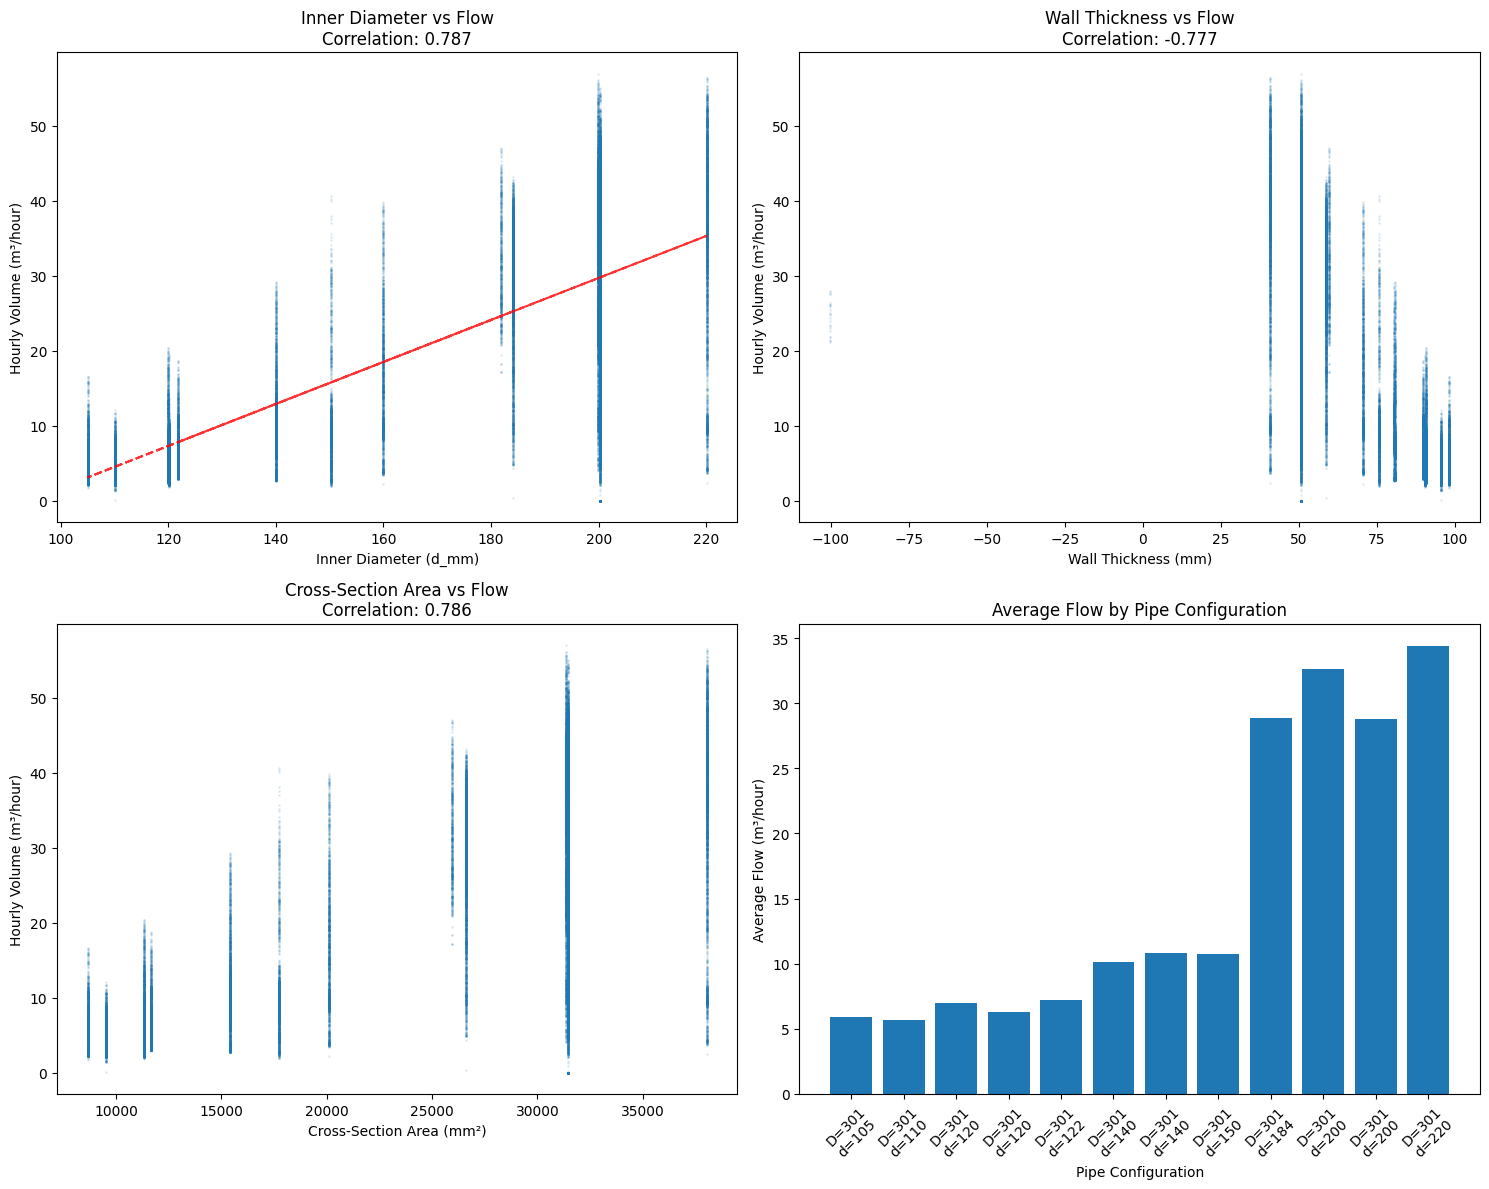

✅ Plots saved as 'pipe_analysis_plots.png'

✅ Pipe analysis complete!
   Key correlations computed
   Pipe configurations analyzed
   Visualizations created


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def simple_pipe_analysis():
    """
    Simple analysis of pipe diameter relationships in the data.
    """
    print("🔧 PIPE DIAMETER ANALYSIS")
    print("="*35)

    # Load data
    try:
        # Try different possible file names
        try:
            df = pd.read_csv('data/data_with_diameters.csv')
        except:
            try:
                df = pd.read_csv('data.csv')
            except:
                df = pd.read_csv('data_with_diameters.csv')

        df['timestamp'] = pd.to_datetime(df['timestamp'])
        print(f"✅ Data loaded: {len(df):,} rows")
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return

    # 1. PIPE DIAMETER DISTRIBUTION
    print(f"\n📊 1. PIPE DIAMETER DISTRIBUTION")
    print("-" * 35)

    print("D_mm (Outer Diameter) Distribution:")
    d_outer_counts = df['D_mm'].value_counts().sort_index()
    for value, count in d_outer_counts.items():
        print(f"  {value:6.1f}mm: {count:,} samples ({count/len(df)*100:.1f}%)")

    print("\nd_mm (Inner Diameter) Distribution:")
    d_inner_counts = df['d_mm'].value_counts().sort_index()
    for value, count in d_inner_counts.items():
        print(f"  {value:6.1f}mm: {count:,} samples ({count/len(df)*100:.1f}%)")

    # Calculate derived metrics
    df['wall_thickness'] = (df['D_mm'] - df['d_mm']) / 2
    df['diameter_ratio'] = df['D_mm'] / df['d_mm']
    df['cross_section_area'] = np.pi * (df['d_mm']/2)**2
    df['flow_velocity'] = df['hourly_volume'] / df['cross_section_area']  # m³/hour per mm²

    print(f"\nDerived Metrics:")
    print(f"  Wall Thickness: {df['wall_thickness'].min():.1f} - {df['wall_thickness'].max():.1f} mm")
    print(f"  Diameter Ratio: {df['diameter_ratio'].min():.2f} - {df['diameter_ratio'].max():.2f}")
    print(f"  Cross-Section Area: {df['cross_section_area'].min():.0f} - {df['cross_section_area'].max():.0f} mm²")

    # 2. PIPE CONFIGURATION VS FLOW ANALYSIS
    print(f"\n🔍 2. PIPE CONFIGURATION VS FLOW ANALYSIS")
    print("-" * 45)

    # Group by pipe dimensions and analyze flow
    pipe_configs = df.groupby(['D_mm', 'd_mm']).agg({
        'hourly_volume': ['mean', 'std', 'count', 'min', 'max'],
        'wall_thickness': 'first',
        'diameter_ratio': 'first',
        'cross_section_area': 'first'
    }).round(3)

    pipe_configs.columns = ['avg_flow', 'flow_std', 'count', 'min_flow', 'max_flow',
                           'wall_thickness', 'diameter_ratio', 'cross_section_area']
    pipe_configs = pipe_configs.reset_index()

    # Filter to configurations with sufficient data
    significant_configs = pipe_configs[pipe_configs['count'] >= 1000].copy()

    if len(significant_configs) > 0:
        print("Flow Analysis by Pipe Configuration (≥1000 samples):")
        print("D_mm   d_mm   Wall   Ratio   Area     Avg_Flow  Std_Flow  Count")
        print("-" * 70)

        for _, config in significant_configs.iterrows():
            print(f"{config['D_mm']:5.1f}  {config['d_mm']:5.1f}  "
                  f"{config['wall_thickness']:5.1f}  {config['diameter_ratio']:5.2f}  "
                  f"{config['cross_section_area']:7.0f}  {config['avg_flow']:8.2f}  "
                  f"{config['flow_std']:8.2f}  {config['count']:6.0f}")

        # Find best and worst performing configurations
        best_config = significant_configs.loc[significant_configs['avg_flow'].idxmax()]
        worst_config = significant_configs.loc[significant_configs['avg_flow'].idxmin()]

        print(f"\nBest Performing Configuration:")
        print(f"  D={best_config['D_mm']:.1f}mm, d={best_config['d_mm']:.1f}mm")
        print(f"  Average flow: {best_config['avg_flow']:.2f} m³/hour")
        print(f"  Wall thickness: {best_config['wall_thickness']:.1f}mm")
        print(f"  Samples: {best_config['count']:.0f}")

        print(f"\nWorst Performing Configuration:")
        print(f"  D={worst_config['D_mm']:.1f}mm, d={worst_config['d_mm']:.1f}mm")
        print(f"  Average flow: {worst_config['avg_flow']:.2f} m³/hour")
        print(f"  Wall thickness: {worst_config['wall_thickness']:.1f}mm")
        print(f"  Samples: {worst_config['count']:.0f}")

        flow_range = best_config['avg_flow'] - worst_config['avg_flow']
        print(f"\nFlow Range: {flow_range:.2f} m³/hour")
    else:
        print("No pipe configurations with sufficient data (≥1000 samples)")

    # 3. CORRELATION ANALYSIS
    print(f"\n📈 3. CORRELATION ANALYSIS")
    print("-" * 25)

    correlations = {
        'D_mm (outer diameter)': df['D_mm'].corr(df['hourly_volume']),
        'd_mm (inner diameter)': df['d_mm'].corr(df['hourly_volume']),
        'Wall thickness': df['wall_thickness'].corr(df['hourly_volume']),
        'Diameter ratio': df['diameter_ratio'].corr(df['hourly_volume']),
        'Cross-section area': df['cross_section_area'].corr(df['hourly_volume']),
        'Flow velocity': df['flow_velocity'].corr(df['hourly_volume'])
    }

    print("Correlations with Hourly Volume:")
    for metric, corr in correlations.items():
        interpretation = ""
        if abs(corr) > 0.7:
            interpretation = "Strong"
        elif abs(corr) > 0.3:
            interpretation = "Moderate"
        elif abs(corr) > 0.1:
            interpretation = "Weak"
        else:
            interpretation = "Negligible"

        if corr > 0:
            direction = "Positive"
        else:
            direction = "Negative"

        print(f"  {metric:20s}: {corr:6.3f} ({interpretation} {direction})")

    # 4. TEMPORAL ANALYSIS
    print(f"\n📅 4. TEMPORAL PIPE USAGE ANALYSIS")
    print("-" * 35)

    # Check if pipe configurations changed over time
    yearly_configs = df.groupby([df['timestamp'].dt.year, 'D_mm', 'd_mm']).size().reset_index()
    yearly_configs.columns = ['year', 'D_mm', 'd_mm', 'count']

    print("Pipe Configuration Usage by Year:")
    for year in sorted(yearly_configs['year'].unique()):
        year_data = yearly_configs[yearly_configs['year'] == year]
        print(f"\n{year}:")
        for _, config in year_data.iterrows():
            if config['count'] > 100:  # Only show significant usage
                print(f"  D={config['D_mm']:.1f}mm, d={config['d_mm']:.1f}mm: {config['count']:,} samples")

    # 5. FLOW VELOCITY ANALYSIS
    print(f"\n⚡ 5. FLOW VELOCITY ANALYSIS")
    print("-" * 30)

    # Analyze flow velocity patterns
    velocity_stats = df.groupby(['D_mm', 'd_mm'])['flow_velocity'].agg(['mean', 'std', 'count']).reset_index()
    velocity_stats = velocity_stats[velocity_stats['count'] >= 1000]

    if len(velocity_stats) > 0:
        print("Flow Velocity by Pipe Configuration:")
        print("D_mm   d_mm   Avg_Velocity   Std_Velocity   Count")
        print("-" * 50)

        for _, config in velocity_stats.iterrows():
            print(f"{config['D_mm']:5.1f}  {config['d_mm']:5.1f}  "
                  f"{config['mean']:11.6f}  {config['std']:11.6f}  {config['count']:6.0f}")

    # 6. STATISTICAL INSIGHTS
    print(f"\n📊 6. STATISTICAL INSIGHTS")
    print("-" * 25)

    # Key insights from the analysis
    insights = []

    # Inner diameter correlation
    d_inner_corr = correlations['d_mm (inner diameter)']
    if d_inner_corr > 0.3:
        insights.append(f"✅ Inner diameter shows positive correlation ({d_inner_corr:.3f}) - larger pipes allow more flow")
    elif d_inner_corr < -0.3:
        insights.append(f"⚠️  Inner diameter shows negative correlation ({d_inner_corr:.3f}) - counter-intuitive!")
    else:
        insights.append(f"➖ Inner diameter shows weak correlation ({d_inner_corr:.3f}) - limited impact")

    # Cross-sectional area correlation
    area_corr = correlations['Cross-section area']
    if area_corr > 0.3:
        insights.append(f"✅ Cross-sectional area positively correlates ({area_corr:.3f}) - physics checks out")
    elif area_corr < -0.3:
        insights.append(f"⚠️  Cross-sectional area negatively correlates ({area_corr:.3f}) - unexpected!")
    else:
        insights.append(f"➖ Cross-sectional area weakly correlates ({area_corr:.3f}) - other factors dominate")

    # Wall thickness impact
    wall_corr = correlations['Wall thickness']
    if abs(wall_corr) > 0.3:
        insights.append(f"🔧 Wall thickness has significant impact ({wall_corr:.3f})")

    # Diameter ratio impact
    ratio_corr = correlations['Diameter ratio']
    if abs(ratio_corr) > 0.3:
        insights.append(f"📐 Diameter ratio (D/d) significantly affects flow ({ratio_corr:.3f})")

    for insight in insights:
        print(f"  {insight}")

    # 7. RECOMMENDATIONS
    print(f"\n🎯 7. RECOMMENDATIONS")
    print("-" * 20)

    recommendations = []

    if d_inner_corr > 0.3:
        recommendations.append("Inner diameter is a valuable feature for prediction")
    elif d_inner_corr < -0.3:
        recommendations.append("Investigate counter-intuitive inner diameter relationship")
    else:
        recommendations.append("Inner diameter has limited predictive power")

    if len(significant_configs) > 1:
        flow_range = significant_configs['avg_flow'].max() - significant_configs['avg_flow'].min()
        if flow_range > 5:
            recommendations.append(f"Pipe configuration significantly impacts flow ({flow_range:.1f} m³/hour range)")
        else:
            recommendations.append("Pipe configuration has moderate impact on flow")

    if abs(wall_corr) > 0.3:
        recommendations.append("Include wall thickness as a feature in modeling")

    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")

    # 8. CREATE VISUALIZATION
    print(f"\n📊 8. CREATING VISUALIZATIONS")
    print("-" * 30)

    try:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Inner diameter vs Flow (scatter)
        axes[0,0].scatter(df['d_mm'], df['hourly_volume'], alpha=0.1, s=1)
        axes[0,0].set_xlabel('Inner Diameter (d_mm)')
        axes[0,0].set_ylabel('Hourly Volume (m³/hour)')
        axes[0,0].set_title(f'Inner Diameter vs Flow\nCorrelation: {d_inner_corr:.3f}')

        # Add trend line
        z = np.polyfit(df['d_mm'], df['hourly_volume'], 1)
        p = np.poly1d(z)
        axes[0,0].plot(df['d_mm'], p(df['d_mm']), "r--", alpha=0.8)

        # Plot 2: Wall thickness vs Flow
        axes[0,1].scatter(df['wall_thickness'], df['hourly_volume'], alpha=0.1, s=1)
        axes[0,1].set_xlabel('Wall Thickness (mm)')
        axes[0,1].set_ylabel('Hourly Volume (m³/hour)')
        axes[0,1].set_title(f'Wall Thickness vs Flow\nCorrelation: {wall_corr:.3f}')

        # Plot 3: Cross-sectional area vs Flow
        axes[1,0].scatter(df['cross_section_area'], df['hourly_volume'], alpha=0.1, s=1)
        axes[1,0].set_xlabel('Cross-Section Area (mm²)')
        axes[1,0].set_ylabel('Hourly Volume (m³/hour)')
        axes[1,0].set_title(f'Cross-Section Area vs Flow\nCorrelation: {area_corr:.3f}')

        # Plot 4: Average flow by pipe configuration
        if len(significant_configs) > 0:
            config_labels = [f"D={row['D_mm']:.0f}\nd={row['d_mm']:.0f}"
                            for _, row in significant_configs.iterrows()]
            axes[1,1].bar(range(len(significant_configs)), significant_configs['avg_flow'])
            axes[1,1].set_xlabel('Pipe Configuration')
            axes[1,1].set_ylabel('Average Flow (m³/hour)')
            axes[1,1].set_title('Average Flow by Pipe Configuration')
            axes[1,1].set_xticks(range(len(significant_configs)))
            axes[1,1].set_xticklabels(config_labels, rotation=45)
        else:
            axes[1,1].text(0.5, 0.5, 'Insufficient data\nfor pipe comparison',
                          ha='center', va='center', transform=axes[1,1].transAxes)
            axes[1,1].set_title('Pipe Configuration Comparison')

        plt.tight_layout()
        plt.savefig('pipe_analysis_plots.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("✅ Plots saved as 'pipe_analysis_plots.png'")
    except Exception as e:
        print(f"⚠️  Error creating plots: {e}")

    # Return results
    return {
        'correlations': correlations,
        'pipe_configs': significant_configs if len(significant_configs) > 0 else pd.DataFrame(),
        'insights': insights,
        'recommendations': recommendations
    }

if __name__ == "__main__":
    results = simple_pipe_analysis()
    print(f"\n✅ Pipe analysis complete!")
    print(f"   Key correlations computed")
    print(f"   Pipe configurations analyzed")
    print(f"   Visualizations created")